### Master of Applied Artificial Intelligence

**Course: TC5035 - Proyecto Integrador**

<img src="https://github.com/Medicenchapin/Proyecto-Integrador/blob/main/assets/logo.png?raw=1" alt="Image Alt Text" width="500"/>


**Ingenieria de Caracteristicas**

Tutor: Dr. Horario Martinez Alfaro


Team members:
* Ignacio Jose Aguilar Garcia - A00819762
* Alejandro Calderon Aguilar - A01795353
* Ricardo Mar Cupido - A01795394


## Theoretical Foundation and Additive Property
Shapley values distribute the contribution of each variable to the model’s outcome in a “fair” manner. In Machine Learning, SHAP defines a baseline (the model’s expected value) and decomposes each individual prediction as the sum of feature contributions. This additivity ensures that the total of all contributions equals the difference between the prediction and the baseline, enabling visualizations such as waterfall plots and reproducible diagnostics.

<img src="https://github.com/Medicenchapin/Proyecto-Integrador/blob/main/assets/Shap_Values.png?raw=1" alt="Image Alt Text" width="500"/>

## Computation and Practical Interpretation
Operationally, SHAP computes, for each observation, a vector of contributions whose sum reproduces the model’s prediction. In linear models, the intuition relies on deviations from the expected value and can be seen as a “centered” version of Partial Dependence Plots (PDPs); in tree-based models, TreeSHAP allows scaling to production while maintaining exactness.

<img src="https://github.com/Medicenchapin/Proyecto-Integrador/blob/main/assets/Ecuacion_Shap.png?raw=1" alt="Image Alt Text" width="300"/>

# 0. Imports

In [1]:
!pip install category_encoders
!pip install shap
!pip install xgboost
!pip install imblearn
!pip install matplotlib
!pip install seaborn
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install plotly
!pip install gdown
!pip install catboost


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new rel

In [2]:
# CORE & UTILITIES
import math
import gdown
import shap
from copy import deepcopy
from datetime import datetime
from tabulate import tabulate

# DATA MANIPULATION
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import probplot

# VISUALIZATION
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic

# MACHINE LEARNING - CORE SKLEARN
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.metrics import precision_recall_curve
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree
from sklearn.model_selection import (

    StratifiedKFold,
    GridSearchCV,
    cross_val_predict,
    cross_val_score,
    cross_validate,
)


# ENCODERS
from category_encoders import OneHotEncoder, TargetEncoder
from category_encoders import OrdinalEncoder

# PREPROCESSING TRANSFORMERS
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

# MODELS - LINEAR / TREE / BAYES / KNN / SVM / BOOSTERS
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import time
from sklearn.calibration import CalibratedClassifierCV

# METRICS & EVALUATION
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    roc_auc_score,
    roc_curve,
)

# SAMPLING
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings("ignore")


/Users/ignacioaguilar/Documents/GitHub/Proyecto-Integrador/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Function


In [3]:
#------------------------------
# Principal Transformer Class
#------------------------------
class ExperimentalTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, feature_name, transformation = None, parameters = None):
        #print(f'Transformation: {transformation}, over feature: {feature_name}')
        self.feature_name = feature_name
        self.transformation = transformation
        self.parameters = parameters

    def fit(self, X, y=None):
        print("Doing fit on feature ",self.feature_name)
        X_ = X.copy()
        # ------------------
        # TARGET ENCODER
        # ------------------
        if (self.transformation == 'apply_target_encoder'):
            if (np.size(y) <= 0):
                raise Exception('Target Encoder requires "y" value')
            t_enc = self.apply_target_encoder(X_, y, self.feature_name)
            self.target_encoder = t_enc
        elif (self.transformation == 'use_target_encoder'):
            self.target_encoder = self.parameters['encoder']
        # ------------------
        # ONE HOT ENCODER
        # ------------------
        elif (self.transformation == 'apply_one_hot_encoder'):
            oh_enc = self.apply_one_hot_encoder(X_, self.feature_name)
            self.one_hot_encoder = oh_enc
        # ------------------
        # TRANSFORMER
        # ------------------
        elif (self.transformation == 'apply_transformer'):
            self.transformer = self.parameters['transformer']
        # ------------------
        # IMPUTE NAN VALUES
        # ------------------
        elif (self.transformation == 'impute_nan'): # it's stateless
            specific_value = None
            if (self.parameters != None and self.parameters['specific_value'] != None):
                specific_value = self.parameters['specific_value']
            self.impute_nan(X_, self.feature_name, self.parameters['metric'], specific_value, 'train')
        # ------------------
        # DELETE INVALID VALUES
        # ------------------
        elif (self.transformation == 'set_nan_value'): # it's stateless
            # self.set_nan_value(X_, self.feature_name, self.parameters['min'], self.parameters['min'])
            pass
        # ------------------
        # TRUNCATE COLUMN
        # ------------------
        elif (self.transformation == 'column_truncate'): # it's stateless
            # column_truncate(df_train, df_test, col_name, 1, 1)
            pass
        elif (self.transformation == 'clean_features'): # it's stateless
            pass
        return self

    def transform(self, X, y=None):
        print("Doing transform on feature ",self.feature_name)
        X_ = X.copy()
        if (self.transformation == 'apply_target_encoder'):
            X_[self.feature_name] = self.target_encoder.transform(X_[self.feature_name])
        elif (self.transformation == 'use_target_encoder'):
            X_[self.feature_name] = self.target_encoder.transform(X_[self.feature_name])
        elif (self.transformation == 'apply_one_hot_encoder'):
            X_ = self.one_hot_encoder.transform(X_)
        elif (self.transformation == 'apply_transformer'):
            X_[self.feature_name] = self.transformer.transform(X_[self.feature_name])
        elif (self.transformation == 'set_nan_value'):
            X_[self.feature_name] = self.set_nan_value(X_, self.feature_name, self.parameters['min'], self.parameters['max'])
        elif (self.transformation == 'impute_nan'):
            specific_value = None
            if (self.parameters != None and self.parameters['specific_value'] != None):
                specific_value = self.parameters['specific_value']
            X_[self.feature_name] = self.impute_nan(X_, self.feature_name, self.parameters['metric'], specific_value)
        elif (self.transformation == 'column_truncate'):
            X_[self.feature_name] = self.column_truncate(X_, self.feature_name, self.parameters['upper_bound'], self.parameters['value'])
        elif (self.transformation == 'clean_features'):
            X_ = X_[self.parameters['features']]
        return X_

    def set_nan_value(self, df_train, col_name, lower_bound, upper_bound):
        '''
        Setea null a los valores de la columna fuera de los limites de lower_bound y upper_bound
        '''
        print("Doing transform on feature ",col_name, " | lower bound:", lower_bound, " | upper bound:", upper_bound)
        train_col = df_train[col_name].mask(((df_train[col_name] < lower_bound) | (df_train[col_name] >= upper_bound)), np.nan)
        return train_col

    def apply_target_encoder(self, df_train, y, col_name):
        '''
        Aplica un encoder de target contra churn y devuelve las columans para train
        y test
        '''
        t_enc = TargetEncoder()
        t_enc.fit(df_train[col_name],y)
        return t_enc

    def apply_one_hot_encoder(self, df_train, col_name):
        '''
        Aplica un one hot encoder y devuelve las columans para train
        y test
        '''
        clsfctn_enc = OneHotEncoder(use_cat_names=True,cols=[col_name])
        # se excluyen los nan para evitar que cree una columna para ellos
        clsfctn_enc.fit(df_train.dropna(subset=[col_name], inplace=False))
        return clsfctn_enc

    def impute_nan(self, df_train, col_name, metric='median',specific_value=None, state='test'):
        '''
        Imputa los valores nulos de la columna utilizando diferentes estrategias:
        * metric = 'median'
        * metric = 'mean'
        * metric = 'specific' con valor definido en specific_value
        '''
        if (state != 'test'):
            if metric=='median':
                self.impute_nan_value = df_train[col_name].median()
            elif metric == 'mean':
                self.impute_nan_value = df_train[col_name].mean()
            elif metric == 'specific':
                self.impute_nan_value = specific_value
            else:
                self.impute_nan_value = specific_value

        print("","The value on impute_nan is:", self.impute_nan_value)
        train_col = df_train[col_name].fillna(self.impute_nan_value, inplace=False)
        return train_col

    def column_truncate(self, df_train, col_name, upper_bound, value=None):
        '''
        Trunca el valor de una columna en cierto valor (upper_bound) y le coloca el valor (si es nulo utiliza el upper_bound)
        '''
        train_col = df_train[col_name].mask((df_train[col_name] >= upper_bound), value if value!=None else upper_bound)
        return train_col
 #------------------------------
 # Debug Transformer Class
 # ------------------------------   
class Debug(BaseEstimator, TransformerMixin):
    def transform(self, X):
        print(X.shape)
        X.to_csv("x.csv", index=False)
        # what other output you want
        return X

    def fit(self, X, y=None, **fit_params):
        return self   
# ------------------------------
# Preprocessing and Sampling Imports
# ------------------------------  
def df_split(df):
    df_X = df.drop('sale',axis=1)
    df_y = df['sale']
    return df_X, df_y

def under_sampling(X, y, ratio, random_state=123):
    under = RandomUnderSampler(random_state=random_state, sampling_strategy=ratio)
    return under.fit_resample(X, y)

# ------------------------------
# Thresholding Metriscs and evaluation curves
# ------------------------------
def threshold_truncate(y, scores, threshold):
  prediction = (scores >= threshold).astype(int)
  precision, recall, f1, o = precision_recall_fscore_support(y, prediction, average='binary', labels=[1,0])
  tn, fp, fn, tp = confusion_matrix(y, prediction).ravel()
  result = {
      'threshold': threshold
      #, 'prediction': prediction
      , 'positive_prediction': prediction.mean()
      , 'precision': precision
      , 'recall': recall
      , 'f1': f1
      , 'support': o
      , 'tn': tn
      , 'fp': fp
      , 'fn': fn
      , 'tp': tp
  }
  return result

def threshold_iter(y, scores, min=0, max=1, step=0.1):
  if (min < 0):
    min = 0.0
  if (max > 1):
    max = 1.0
  if (not (min < step and step < max)):
    step = 0.1

  results = []
  for threshold in np.arange(min, max, step):
    result = threshold_truncate(y, scores, threshold)
    results.append(result)
  return results

def plot_threshold_metrics(df):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18,4))
    fig.suptitle('Model metrics per threshold: ', fontsize=18)

    # Precision
    df.plot(x='threshold', y=['precision'], ax=axes[0])
    axes[0].set_title('Precision')

    # Precision
    df.plot(x='threshold', y=['recall'], ax=axes[1])
    axes[1].set_title('Recall')

    # Precision
    df.plot(x='threshold', y=['f1'], ax=axes[2])
    axes[2].set_title('F1')

    plt.tight_layout()

# ------------------------------
# SHAP values
# ------------------------------
def evaluate_shap_values(model, X_test, plot=False):
    # Fits the explainer
    explainer = shap.Explainer(model)
    # Calculates the SHAP values - It takes some time
    shap_values = explainer(X_test)
    if plot:
        shap.plots.bar(shap_values)
        shap.summary_plot(shap_values)
    return shap_values

# ------------------------------
# Univariate Analysis
# ------------------------------

def plot_hist_prob(df, col_name, plot_transforms=True):
    if plot_transforms==False:
        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18,3))

        # Histogram & Density
        sns.histplot(data=df, x=col_name, ax=axes[0], kde=True)
        axes[0].set_title('Histogram')

        # Probability Plot
        probplot(df[col_name], plot=axes[1])
        #axes[1].set_title(axes[1].get_title()+' Quantile Transformed data')

        # boxplot
        sns.boxplot(data=df, x=col_name, ax=axes[2], showfliers = True)
        axes[2].set_title('Boxplot')

        plt.tight_layout()
    else:
        fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,9))
        fig.suptitle(col_name, fontsize=18)

        # Histogram & Density
        sns.histplot(data=df, x=col_name, ax=axes[0,0], kde=True)
        axes[0,0].set_title('Histogram')

        # Probability Plot
        probplot(df[col_name], plot=axes[0,1])

        # boxplot
        sns.boxplot(data=df, x=col_name, ax=axes[0,2], showfliers = True)
        axes[0,2].set_title('Boxplot')

        df_tmp = df.copy()
        # -------------------------------
        # QUANTILE
        # -------------------------------
        q_transformer = QuantileTransformer(output_distribution='normal')
        q_transformer.fit(df_tmp[[col_name]])

        df_tmp['q_'+col_name] = q_transformer.transform(df_tmp[[col_name]])

        # Histogram & Density
        sns.histplot(data=df_tmp, x='q_'+col_name, ax=axes[1,0], kde=True)
        axes[1,0].set_title('Histogram')

        # Probability Plot
        probplot(df_tmp['q_'+col_name], plot=axes[1,1])

        # boxplot
        sns.boxplot(data=df_tmp, x='q_'+col_name, ax=axes[1,2], showfliers = True)
        axes[1,2].set_title('Boxplot')

        # -------------------------------
        # YEO JONSHON
        # -------------------------------
        yj_transformer = PowerTransformer(method='yeo-johnson')
        yj_transformer.fit(df_tmp[[col_name]])

        df_tmp['yj_'+col_name] = yj_transformer.transform(df_tmp[[col_name]])

        # Histogram & Density
        sns.histplot(data=df_tmp, x='yj_'+col_name, ax=axes[2,0], kde=True)
        axes[2,0].set_title('Histogram')

        # Probability Plot
        probplot(df_tmp['yj_'+col_name], plot=axes[2,1])

        # boxplot
        sns.boxplot(data=df_tmp, x='yj_'+col_name, ax=axes[2,2], showfliers = True)
        axes[2,2].set_title('Boxplot')


        plt.tight_layout()

# ------------------------------
# Utilities pipeline, parquet & booster
# ------------------------------
def assert_parquet_ready() -> str:
    """Verifica que pyarrow esté disponible y retorna su versión. Lanza error si no está."""
    try:
        import pyarrow as pa  # noqa
        import pyarrow.parquet as pq  # noqa
        return pa.__version__
    except Exception as e:
        raise RuntimeError(
            "Parquet estricto: pyarrow no está disponible o falló al importarse. "

        ) from e

def build_prep_from_pipeline(pipe: Pipeline) -> Pipeline:
    """Devuelve un Pipeline con todas las transformaciones salvo 'debug' y 'classifier'."""
    prep_steps = [(n, t) for (n, t) in pipe.steps if n not in ('debug', 'classifier')]
    return Pipeline(prep_steps)

def align_to_booster_features(X_tr, booster) -> pd.DataFrame:
    """Alinea X_tr (np.array o DataFrame) a booster.feature_names en orden y nombre."""
    feat_names = booster.feature_names
    if feat_names is None:
        raise ValueError("El booster no expone feature_names. Asegúrate de entrenar con nombres de columna.")
    if hasattr(X_tr, "columns"):
        # crear columnas faltantes (si las hubiera) y eliminar extras
        missing = [c for c in feat_names if c not in X_tr.columns]
        extras  = [c for c in X_tr.columns if c not in feat_names]
        X_df = X_tr.copy()
        for c in missing:
            X_df[c] = 0.0
        if extras:
            X_df = X_df.drop(columns=extras)
        X_df = X_df.reindex(columns=feat_names)
    else:
        X_df = pd.DataFrame(X_tr, columns=feat_names)
    return X_df

def shap_full_dataset(pipe: Pipeline, df_selected: pd.DataFrame, target_col: str = 'sale',
                      batch_size: int = 50_000) -> tuple[pd.DataFrame, list[str], float]:
    """
    Aplica prep del pipeline, alinea features con el booster y calcula SHAP (TreeSHAP) en lotes.
    Devuelve (shap_full_df, feature_names, delta_max_proba).
    """
    # 1) Preparación cruda
    X_raw = df_selected.drop(columns=[target_col], errors='ignore').copy()

    # 2) Prep tal cual entrenaste
    prep = build_prep_from_pipeline(pipe)
    X_tr = prep.transform(X_raw)

    # 3) Booster y nombres “oficiales”
    clf = pipe.named_steps['classifier'] if 'classifier' in pipe.named_steps else model
    booster = clf.get_booster()
    X_df = align_to_booster_features(X_tr, booster)
    feat_names = booster.feature_names

    # 4) SHAP por lotes
    def _batches(A, n):
        for i in range(0, A.shape[0], n):
            yield A[i:i+n]

    parts = []
    for Xi in _batches(X_df.values, batch_size):
        dm = xgb.DMatrix(Xi, feature_names=feat_names)
        sv = booster.predict(dm, pred_contribs=True)

        expected = sv[:, -1]
        shap_vals = sv[:, :-1]

        df_sv = pd.DataFrame(shap_vals, columns=feat_names)
        df_sv['expected_value'] = expected
        df_sv['shap_sum'] = df_sv[feat_names].sum(axis=1)
        df_sv['logit'] = df_sv['expected_value'] + df_sv['shap_sum']
        df_sv['p_sale'] = 1.0 / (1.0 + np.exp(-df_sv['logit']))
        parts.append(df_sv)

    shap_full = pd.concat(parts, axis=0, ignore_index=True)
    try:
        proba_model = clf.predict_proba(X_df.values)[:, 1]
        delta = float(np.max(np.abs(proba_model - shap_full['p_sale'].values)))
    except Exception:
        delta = np.nan

    return shap_full, feat_names, delta

def save_parquet_strict(df: pd.DataFrame, path: str) -> None:
    """Guarda Parquet usando pyarrow. Falla si no está correcto (sin fallback)."""
    import pyarrow as pa
    import pyarrow.parquet as pq
    table = pa.Table.from_pandas(df, preserve_index=False)
    pq.write_table(table, path)



# 2. Data Preparation

* **Ubicación y demografía**

  * **state_name** *(str)*: Customer’s department/state (e.g., GUATEMALA, JALAPA).
  * **state_city_equals** *(binary 0/1)*: Department and city match (address quality).
  * **client_gender** *(str: M/F/na)*: Declared gender.
  * **client_age** *(num)*: Age in years.


* **Historial de telemarketing / clasificación previa**

  * **previous_classification** *(str)*: Outcome of the prior outreach (NEW CLIENT, NOT INTERESTED, NOT EFFECTIVE, etc.).
  * **previous_calls** *(int)*: Number of previous calls.
  * **previous_not_effective_count** *(int)*: Prior “not effective” calls.
  * **previous_not_interested_count** *(int)*: Times the customer stated not interested.

* **Identificación y antigüedad en red**

  * **client_has_nit** *(binary)*: Has tax ID (1) or not (0).
  * **network_age_years** *(num)*: Tenure on the network (years).
  * **start_using_months** *(int)*: Months since first line usage.
  * **imei_first_use_months** *(int)*: Months since the IMEI first appeared on the network.
  * **imei_distinct_users** *(int)*: Number of distinct users for that IMEI.

* **Cartera de productos (RGUs) y plan**

  * **rgus_prepaid / rgus_postpaid / rgus_home** *(int)*: Active products by type.
  * **plan_postpaid** *(binary)*: Has an active postpaid plan (1/0).
  * **class** *(int)*: Internal device/customer segment/score (e.g., 3/4/5).
  * **socioeconomic_level** *(str: A–E, C-, C+, etc.)*: Estimated socioeconomic level.

* **Banca y afinidad financiera**

  * **banking** *(binary)*: Banked per internal/external sources.
  * **sn_banking** *(binary)*: Social/alternative banking signal.
  * **digital_tokenized_card** *(binary)*: Has a tokenized card in Tigo’s digital ecosystem.

* **Facturación, gasto y uso de red**

  * **arpu_90_days** *(num, currency)*: Average ARPU over the last 90 days.
  * **navegation_gb** *(num, GB)*: Total mobile data consumed.
  * **minutes_out / minutes_in** *(num, min)*: Outgoing/incoming minutes.
  * **percent_of_weeks_with_data_purchase** *(0–1)*: Share of weeks with a data purchase.
  * **purchase_average** *(num)*: Average top-up/purchase ticket.
  * **validity_average** *(num, days)*: Average validity of packages.
  * **average_performance** *(~0–1.5)*: Internal line activity index.
  * **with_international_calls** *(binary)*: Makes international calls.
  * **arpu_gte_100** *(binary)*: ARPU ≥ 100.
  * **navigation_gte_5gb** *(binary)*: Data usage ≥ 5 GB.

* **Tecnología y dispositivo**

  * **network_technology_code** *(str)*: Access technology (3G/4G/5G).
  * **operating_system** *(str)*: Device OS (ANDROID/iOS…).
  * **type_name** *(str)*: Device type (SMARTPHONE, FEATURE PHONE, etc.).
  * **brand_name / model_name** *(str)*: Device brand and model.

* **Gráfica social / agenda del cliente**

  * **contacts** *(int)*: Detected contacts.
  * **tigo_contacts** *(int)*: Contacts within Tigo’s network.
  * **high_frequency_contacts** *(decimal 0–1)*: Share/score of high-frequency contacts.

* **Comportamiento digital Tigo**

  * **digital_months** *(int)*: Months using Tigo digital channels.
  * **digital_index_mean** *(0–1)*: Average digital adoption score.
  * **connected_days / charged_days / apps_days / zero_rate_days** *(int)*: Days with connection, with charging, with app usage, and with zero-rating.

* **Uso por aplicación (engagement)**

  * **facebook_days / facebook_gb** *(int / GB)*: Days and GB on Facebook.
  * **tiktok_days / tiktok_gb** *(int / GB)*: Days and GB on TikTok.
  * **instagram_days / instagram_gb** *(int / GB)*: Days and GB on Instagram.
  * **whatsapp_days / whatsapp_gb** *(int / GB)*: Days and GB on WhatsApp.
  * **youtube_days / youtube_gb** *(int / GB)*: Days and GB on YouTube.
  * **music_days / music_gb** *(int / GB)*: Days and GB on music apps.

* **Señales derivadas y consistencia**

  * **state_city_equals** *(binary)*: (as above) validates address consistency.
  * **C+, C-, D, E** *(in `socioeconomic_level`)*: Ordinal coding for targeting.

* **Variable objetivo**

  * **sale** *(str: YES/NO)*: Sales/contact outcome (model target).


## 2.1 Download dataset

**Important: the following csv file is completly confidencial, it's not allowed to scam it**

In [4]:
!mkdir data
url = 'https://drive.google.com/uc?export=download&id=1rmHf8nMsml059APC6ftFytKjVlUnbOUp'
output = 'data/sale.csv'

mkdir: data: File exists


In [5]:
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?export=download&id=1rmHf8nMsml059APC6ftFytKjVlUnbOUp
From (redirected): https://drive.google.com/uc?export=download&id=1rmHf8nMsml059APC6ftFytKjVlUnbOUp&confirm=t&uuid=4db7f62d-6cb4-4ae4-b08e-62a45343d4bc
To: /Users/ignacioaguilar/Documents/GitHub/Proyecto-Integrador/5-final_model/data/sale.csv
100%|██████████| 299M/299M [00:34<00:00, 8.58MB/s] 


'data/sale.csv'

## 2.2 Read csv file into a pandas dataframe

In [6]:
df = pd.read_csv(output)

## 2.3 Dataframe shape

This line helps us to know how many rows our dataframe has

In [7]:
df.shape

(610083, 60)

## 2.4 Show the 5 first rows of dataset

We show the first 5 rows of dataset

In [8]:
df.head()

,state_name,previous_classification,previous_calls,previous_not_effective_count,previous_not_interested_count,client_gender,client_age,client_has_nit,network_age_years,rgus_prepaid,...,tiktok_gb,instagram_days,instagram_gb,whatsapp_days,whatsapp_gb,youtube_days,youtube_gb,music_days,music_gb,sale
0,JALAPA,NEW CLIENT,0,0,0,M,69.0,1,3.16,3,...,30.321,0,0.000,84,0.693,85,2.745,0,0.000,NO
1,GUATEMALA,NEW CLIENT,0,0,0,F,28.0,1,3.90,2,...,42.442,89,0.425,89,20.237,89,3.614,89,5.946,NO
2,ALTA VERAPAZ,NOT INTERESTED,2,1,1,M,44.0,1,12.88,4,...,7.749,0,0.000,89,21.538,85,1.607,42,0.298,NO
3,CHIMALTENANGO,NOT INTERESTED,3,1,2,M,56.0,1,1.94,6,...,2.739,82,0.125,82,2.072,82,2.454,0,0.000,NO
4,HUEHUETENANGO,NOT INTERESTED,6,4,2,F,45.0,1,13.37,2,...,7.694,64,0.037,87,1.040,76,1.065,23,0.142,NO


sale would it be the variable target, so sale is parse from string to integer32


* SI = 1
* NO = 0

In [9]:
df['sale'] = (df['sale']=='SI').astype('int32')

## 2.4 Global information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610083 entries, 0 to 610082
Data columns (total 60 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   state_name                           610068 non-null  object 
 1   previous_classification              610083 non-null  object 
 2   previous_calls                       610083 non-null  int64  
 3   previous_not_effective_count         610083 non-null  int64  
 4   previous_not_interested_count        610083 non-null  int64  
 5   client_gender                        458428 non-null  object 
 6   client_age                           458559 non-null  float64
 7   client_has_nit                       610083 non-null  int64  
 8   network_age_years                    610081 non-null  float64
 9   rgus_prepaid                         610083 non-null  int64  
 10  rgus_postpaid                        610083 non-null  int64  
 11  rgus_home    

### 2.4.1 Numerical variables

This dataset has 51 numerical variables

In [11]:
numerical_variables = df.select_dtypes(include="number").columns.tolist()
print(f'numerical variables: {len(numerical_variables)}')

numerical variables: 51


The following table describes:

* Measures of central tendency
    * mean
    * median
    

* Measures of dispersion
    * Range
    * Variance
    * Standar deviation


* Measures of position
    * quantiles
    * min
    * max

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
previous_calls,610083.0,1.406976,1.655471,0.0,0.000,1.000,2.000,28.000
previous_not_effective_count,610083.0,0.950838,1.384682,0.0,0.000,0.000,1.000,28.000
previous_not_interested_count,610083.0,0.456138,0.762280,0.0,0.000,0.000,1.000,17.000
client_age,458559.0,41.237679,12.294965,7.0,32.000,40.000,49.000,2022.000
client_has_nit,610083.0,0.487743,0.499850,0.0,0.000,0.000,1.000,1.000
network_age_years,610081.0,3.756704,3.816662,0.0,1.090,2.530,4.950,25.370
rgus_prepaid,610083.0,10.773570,166.266269,0.0,1.000,2.000,4.000,16060.000
rgus_postpaid,610083.0,2.756890,329.779165,0.0,0.000,0.000,0.000,41590.000
rgus_home,610083.0,0.122000,0.557192,0.0,0.000,0.000,0.000,20.000
banking,610083.0,0.705943,0.455618,0.0,0.000,1.000,1.000,1.000


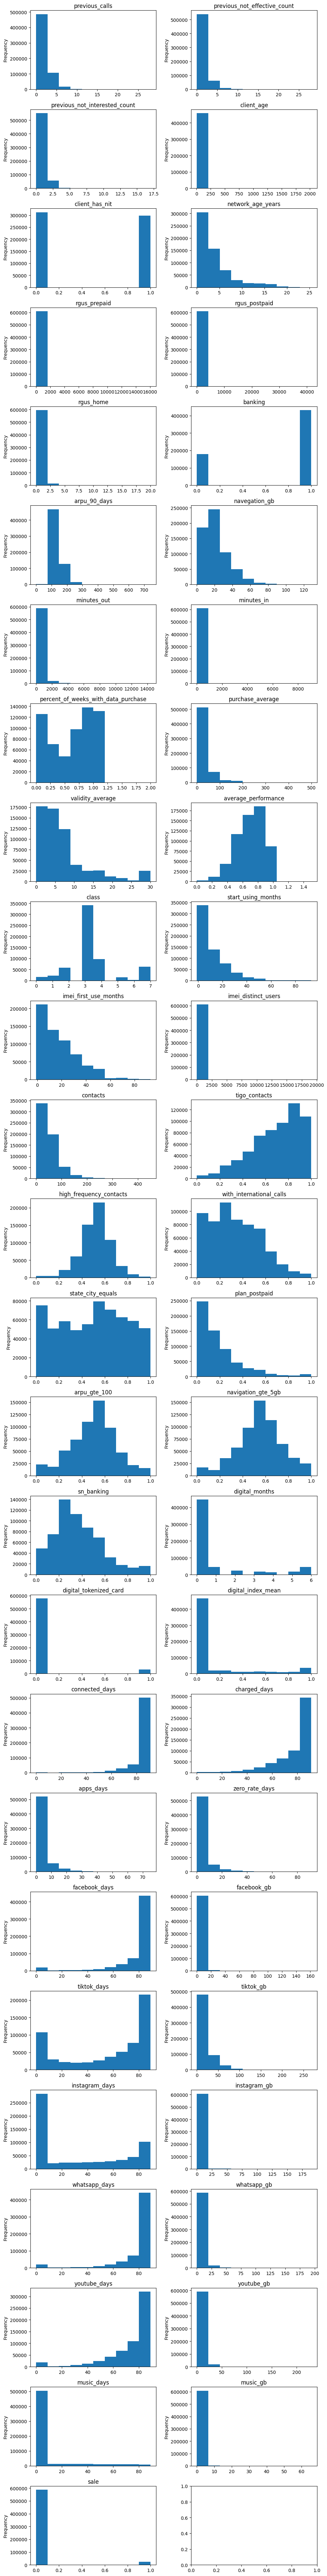

In [13]:


n = len(numerical_variables)
cols = 2
rows = math.ceil(n/cols)

fig, axes = plt.subplots(rows,cols, figsize=(cols*5,rows*3))
axes= axes.flatten()

for i, col in enumerate(numerical_variables):
    df[col].plot(kind='hist', ax=axes[i])
    axes[i].set_title(col)
    #axes[i].set_xlabel(col)
    #axes[i].set_ylabel('Counts')

plt.tight_layout()
plt.show()

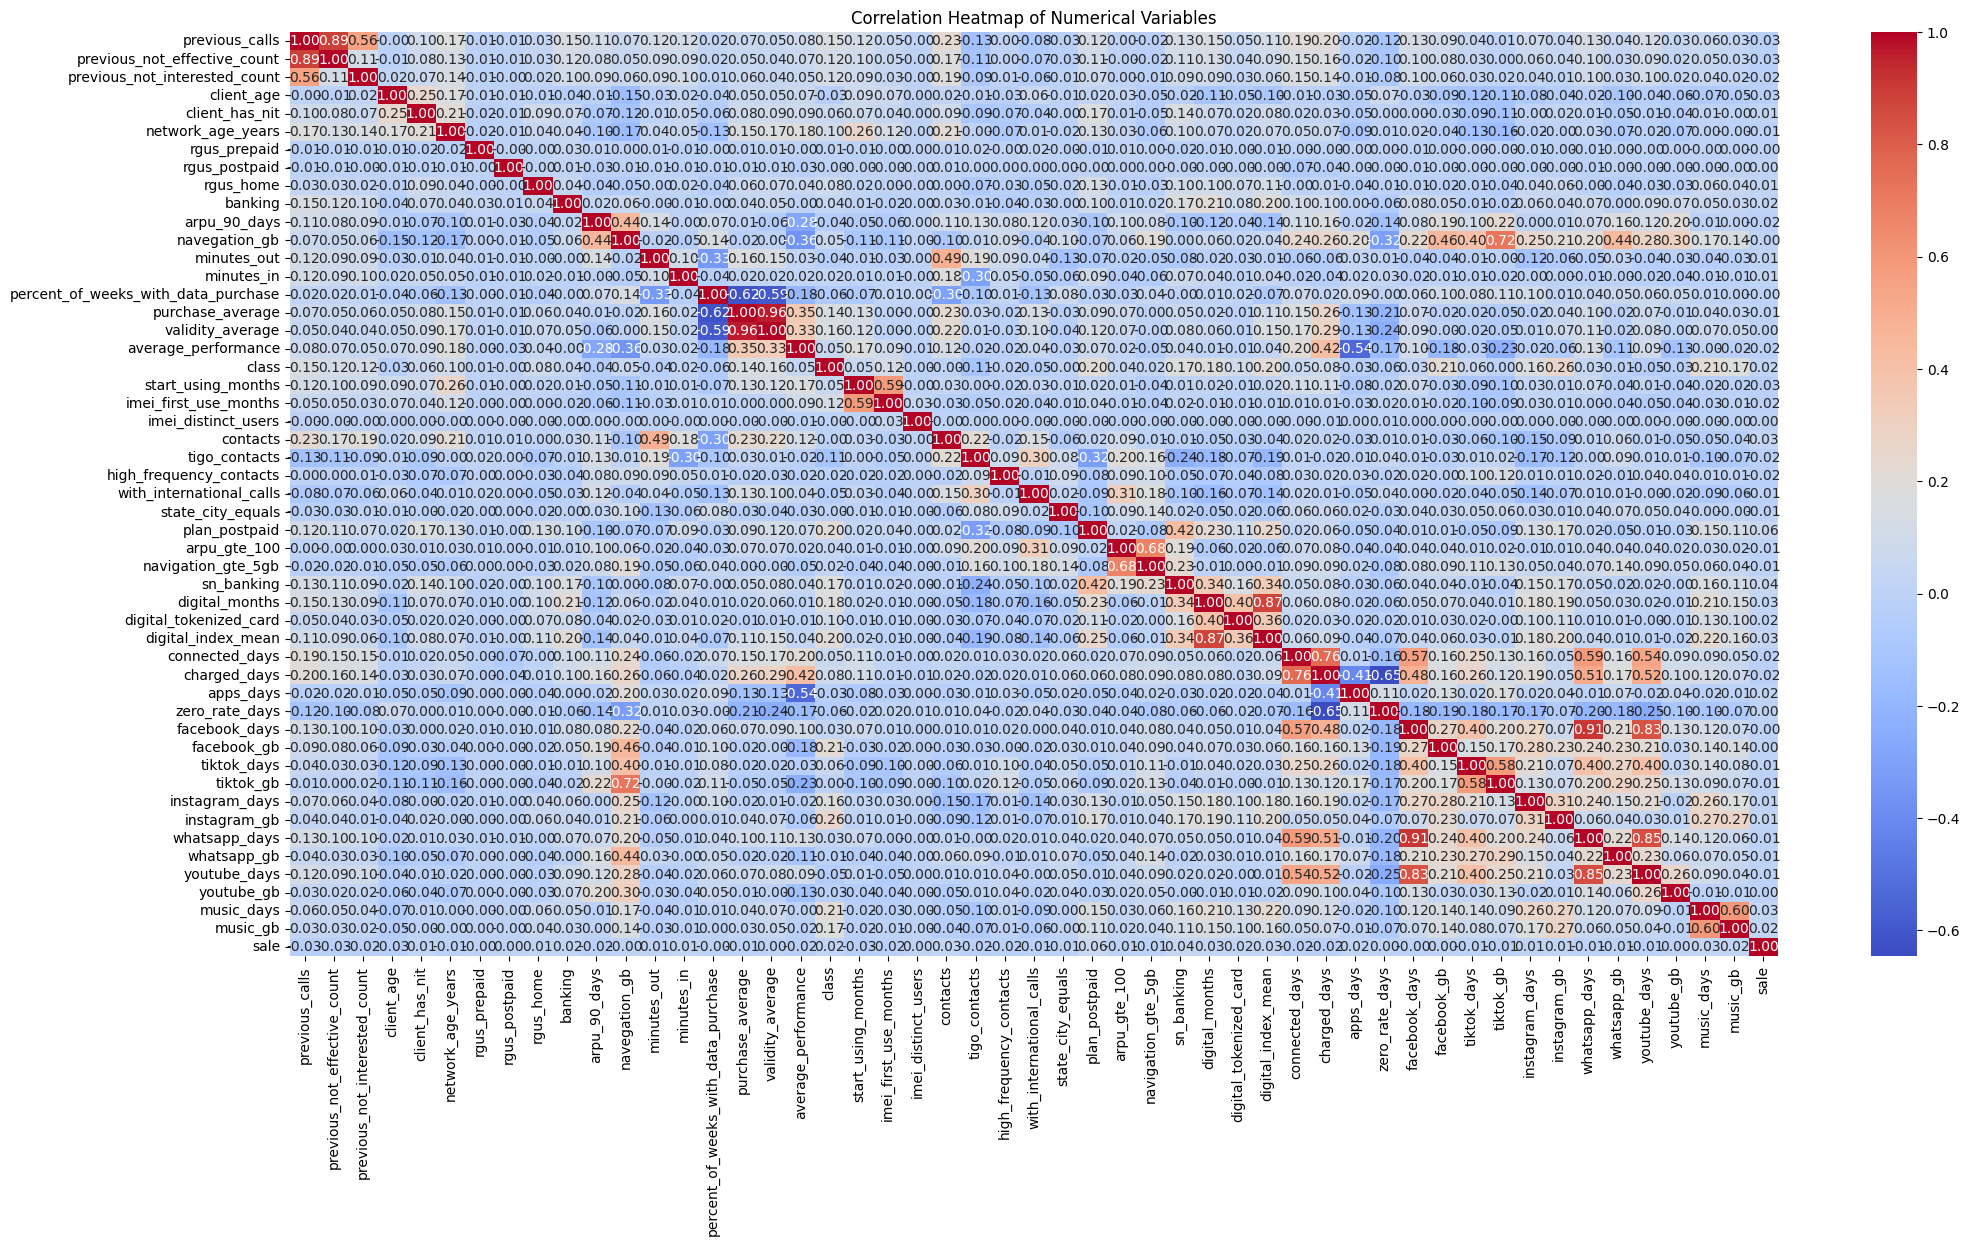

In [14]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(24, 12))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [15]:
corr_matrix = df.corr(numeric_only=True).abs()

# Upper triangle mask
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.5
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print("Highly correlated variables:", to_drop)

Highly correlated variables: ['previous_not_effective_count', 'previous_not_interested_count', 'purchase_average', 'validity_average', 'imei_first_use_months', 'navigation_gte_5gb', 'digital_index_mean', 'charged_days', 'apps_days', 'zero_rate_days', 'facebook_days', 'tiktok_gb', 'whatsapp_days', 'youtube_days', 'music_gb']


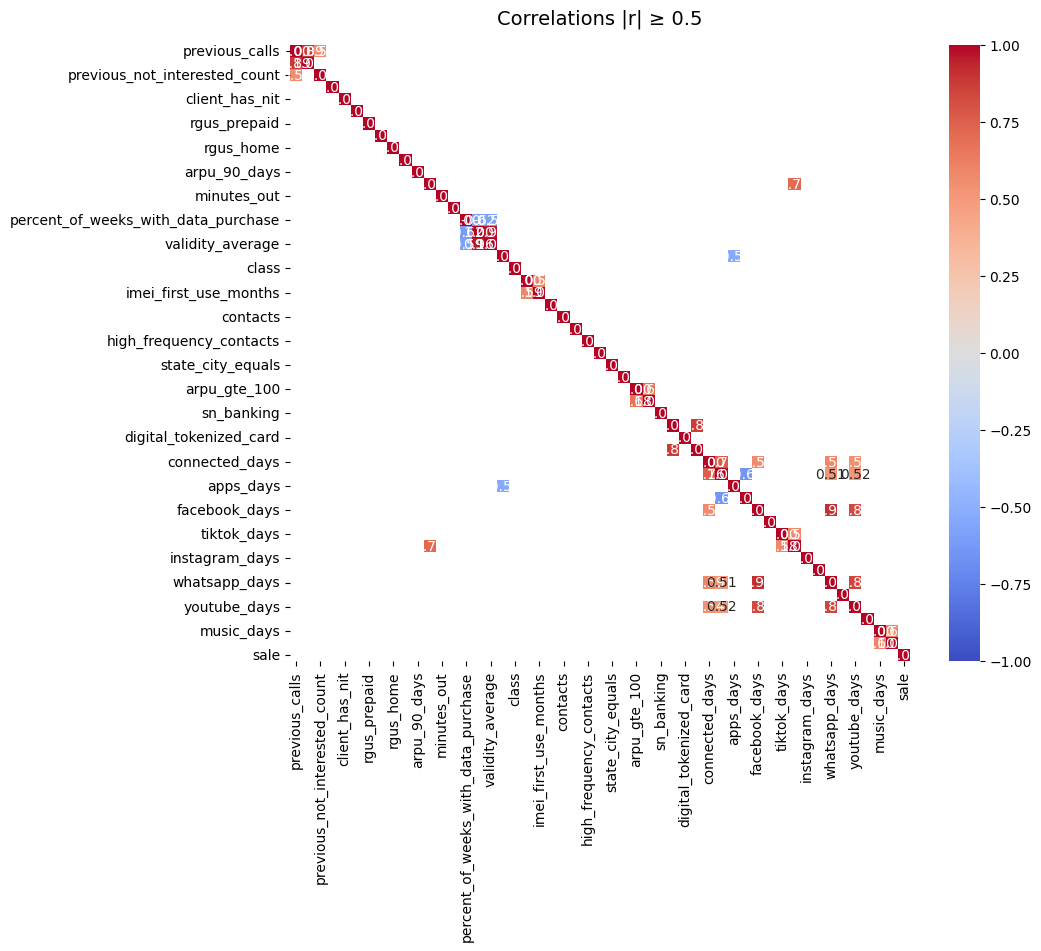

In [16]:
threshold = 0.5
mask = corr.abs() < threshold
filtered_corr = corr.mask(mask)

plt.figure(figsize=(10, 8))
sns.heatmap(filtered_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title(f"Correlations |r| ≥ {threshold}", fontsize=14, pad=15)
plt.show()

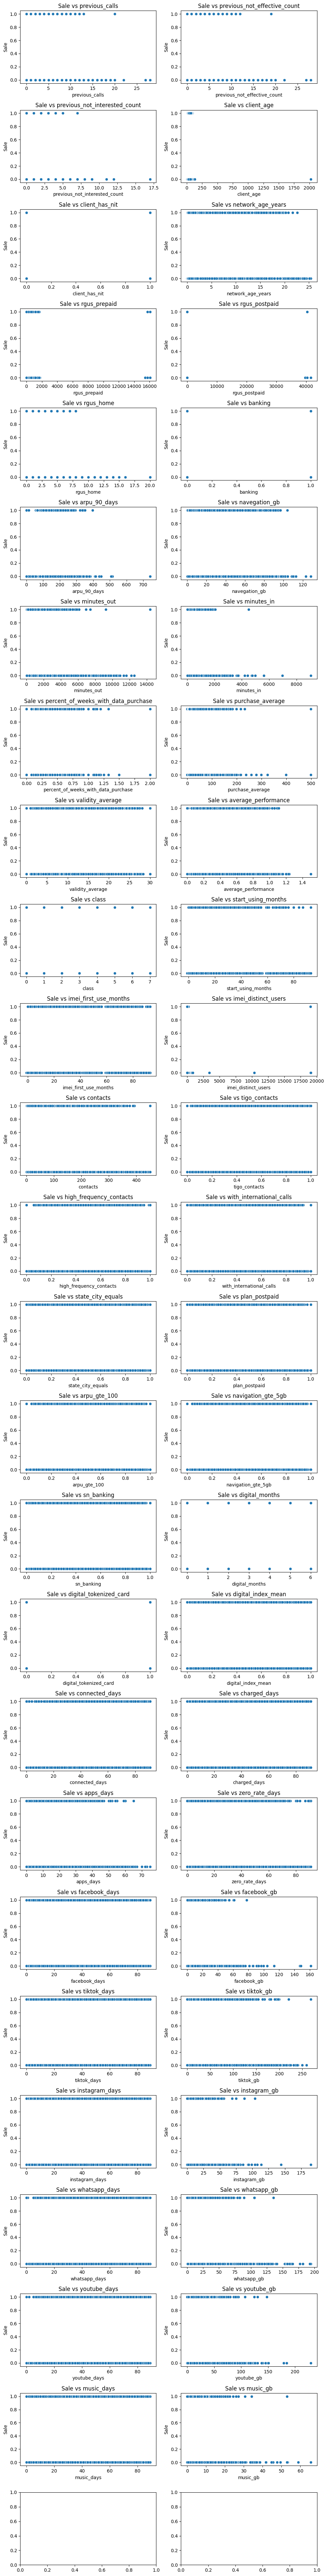

In [17]:

cols = 2

n = len(numerical_variables)

rows = math.ceil(n/cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))

axes = axes.flatten()

num_feats = [num_col for num_col in numerical_variables if num_col != 'sale']

for i, col in enumerate(num_feats):
    sns.scatterplot(data=df, x=col, y='sale', ax=axes[i])
    axes[i].set_title(f"Sale vs {col}")
    axes[i].set_ylabel('Sale')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()




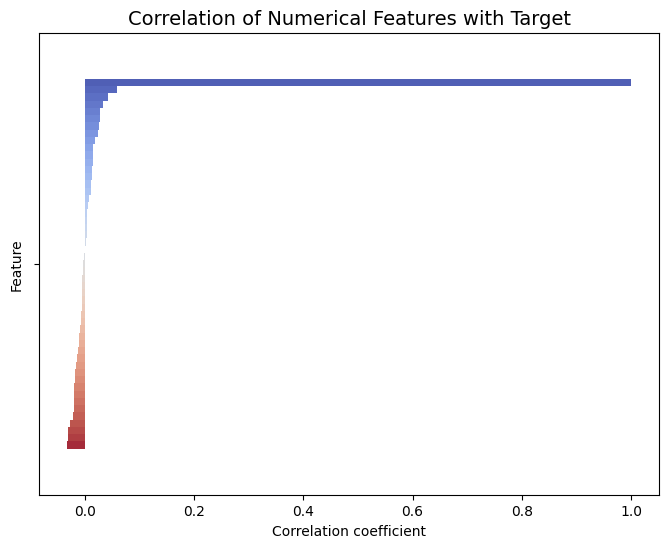

In [18]:
corr = df.corr(numeric_only=True)['sale'].sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=corr.values, hue=corr.index, palette="coolwarm", legend=False)
plt.title("Correlation of Numerical Features with Target", fontsize=14)
plt.xlabel("Correlation coefficient")
plt.ylabel("Feature")
plt.show()

#### missing numerical values

In [19]:
missing = df[numerical_variables].isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent.round(2)
})

missing_df

,Missing Values,Percentage
client_age,151524,24.84
imei_distinct_users,19,0.00
imei_first_use_months,19,0.00
start_using_months,19,0.00
class,19,0.00
network_age_years,2,0.00
previous_calls,0,0.00
facebook_days,0,0.00
digital_months,0,0.00
digital_tokenized_card,0,0.00


#### outliers

Outlier detection helps identify data points that deviate significantly from other observations.

In this notebook, boxplots are used (see next cell) to visualize outliers for each numerical variable. In a boxplot, outliers are typically shown as points outside the "whiskers" (which represent 1.5 times the interquartile range from the quartiles).

These outliers may indicate errors, rare events, or variability in the data, and can impact model performance.

Detecting and handling outliers is important for robust data analysis and modeling.

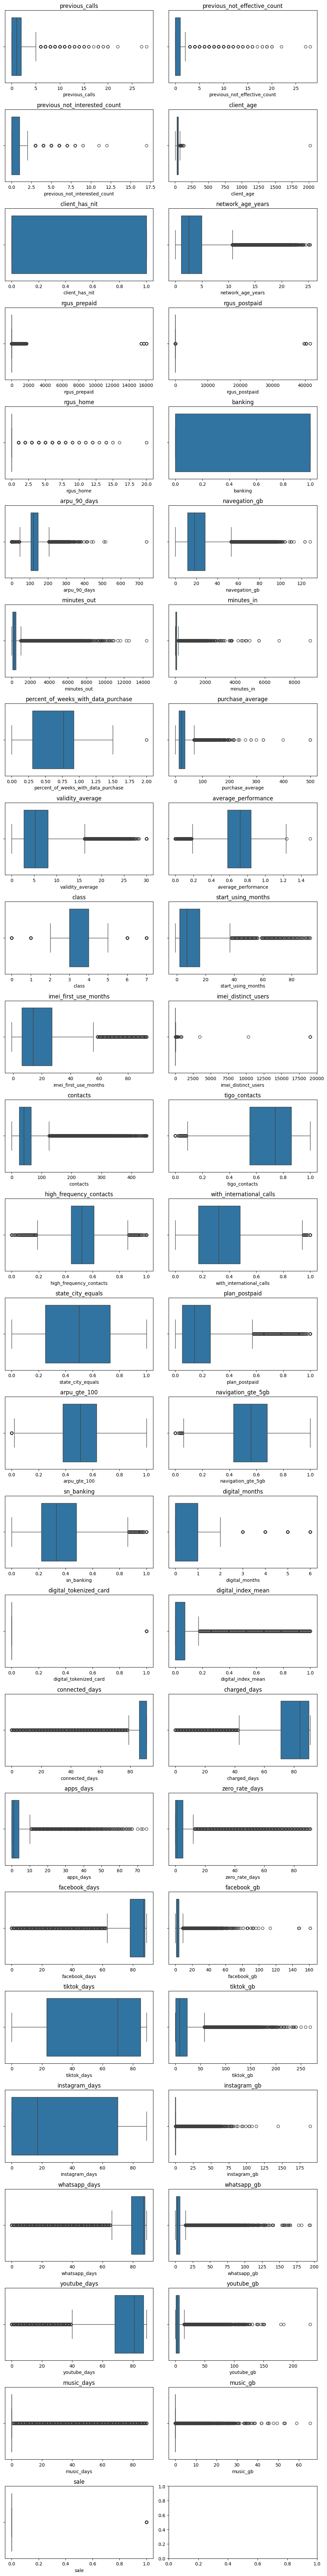

In [20]:
n = len(numerical_variables)

cols = 2
rows = math.ceil(n/cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))

axes = axes.flatten()

for i, col in enumerate(numerical_variables):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### 2.4.3 Categorical Variables

This dataset has 9 categorical variables

In [21]:
categorical_variables = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'categorical variables: {len(categorical_variables)}')

categorical variables: 9


The following tables describes the categorical variables in the dataset making emphasis in:
* Count
* Top
* Frequency

In [22]:
df.describe(include="object").T

,count,unique,top,freq
state_name,610068,22,GUATEMALA,104875
previous_classification,610083,3,NEW CLIENT,231950
client_gender,458428,2,M,247019
socioeconomic_level,610083,6,D,227175
network_technology_code,610064,4,4G,554284
operating_system,610064,9,ANDROID,564097
type_name,610064,4,SMARTPHONE,609528
brand_name,610064,128,SAMSUNG,358068
model_name,610064,2382,SAMSUNG A10S 2GB+32GB,41674


#### A) Cardinal values
the following instruction will show the cardinal values for categorical variables

In [23]:
for cat_variable in categorical_variables[:-1]:
    print(f'[{cat_variable}] = {df[cat_variable].value_counts()}\n' )

[state_name] = state_name
GUATEMALA         104875
HUEHUETENANGO      66354
SAN MARCOS         56817
QUICHE             45712
ALTA VERAPAZ       38236
QUETZALTENANGO     37619
ESCUINTLA          30357
PETEN              25095
CHIMALTENANGO      24117
JUTIAPA            19469
SOLOLA             18671
TOTONICAPAN        18569
IZABAL             17901
SANTA ROSA         13704
SUCHITEPEQUEZ      13596
JALAPA             12974
CHIQUIMULA         12768
RETALHULEU         12229
ZACAPA             12102
BAJA VERAPAZ       10926
SACATEPEQUEZ       10873
EL PROGRESO         7104
Name: count, dtype: int64

[previous_classification] = previous_classification
NEW CLIENT        231950
NOT INTERESTED    201022
NOT EFFECTIVE     177111
Name: count, dtype: int64

[client_gender] = client_gender
M    247019
F    211409
Name: count, dtype: int64

[socioeconomic_level] = socioeconomic_level
D     227175
C-    156787
CC    108909
E      48852
C+     35455
AB     32905
Name: count, dtype: int64

[network_te

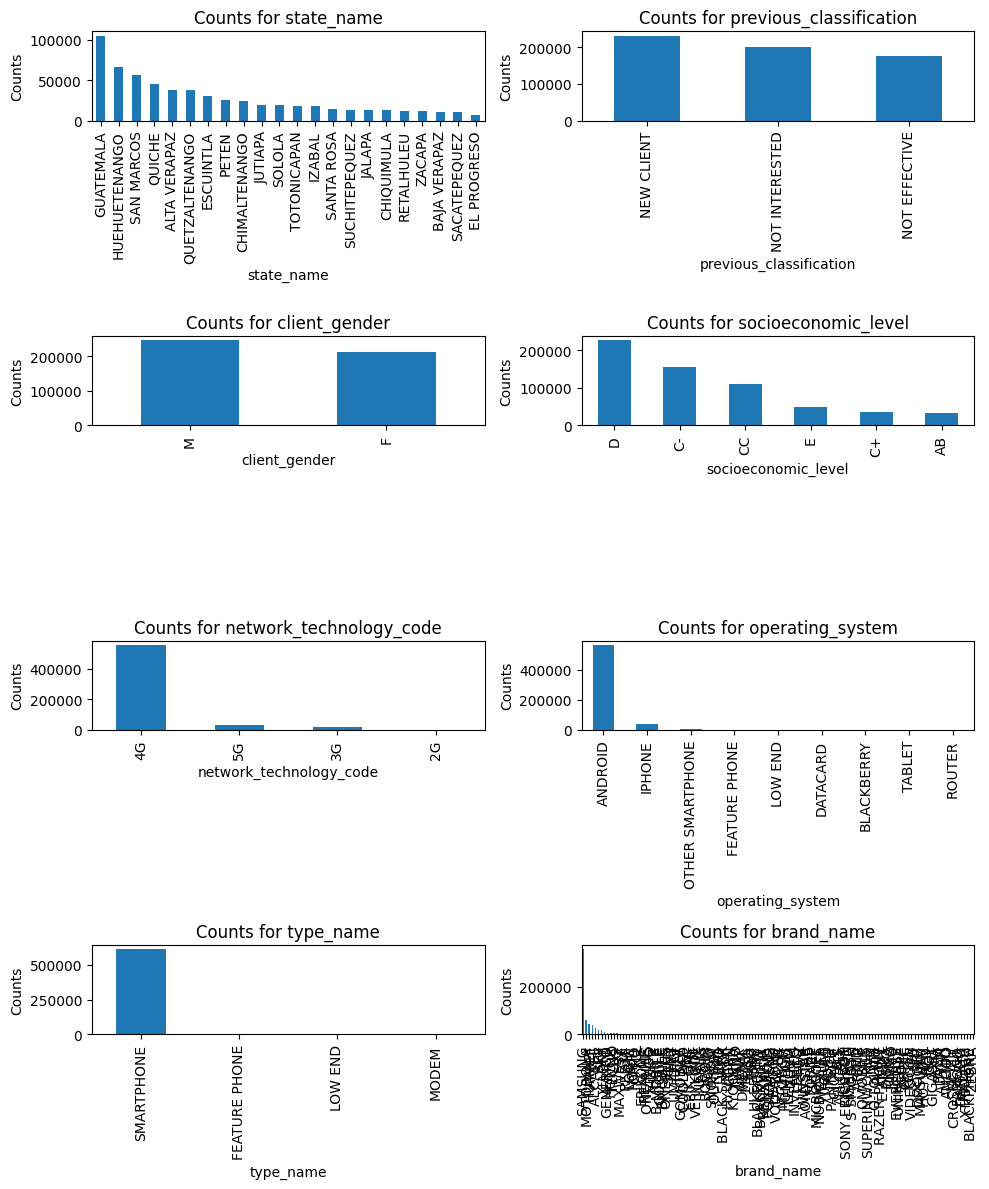

In [24]:

n = len(categorical_variables[:-1])
cols = 2
rows = math.ceil(n/cols)


fig, axes = plt.subplots(rows, cols, figsize=(cols*5,rows*3))

axes= axes.flatten()

for i, col in enumerate(categorical_variables[:-1]):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Counts for {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Counts')

plt.tight_layout()
plt.show()


#sns.barplot(data=df, x='state_name')

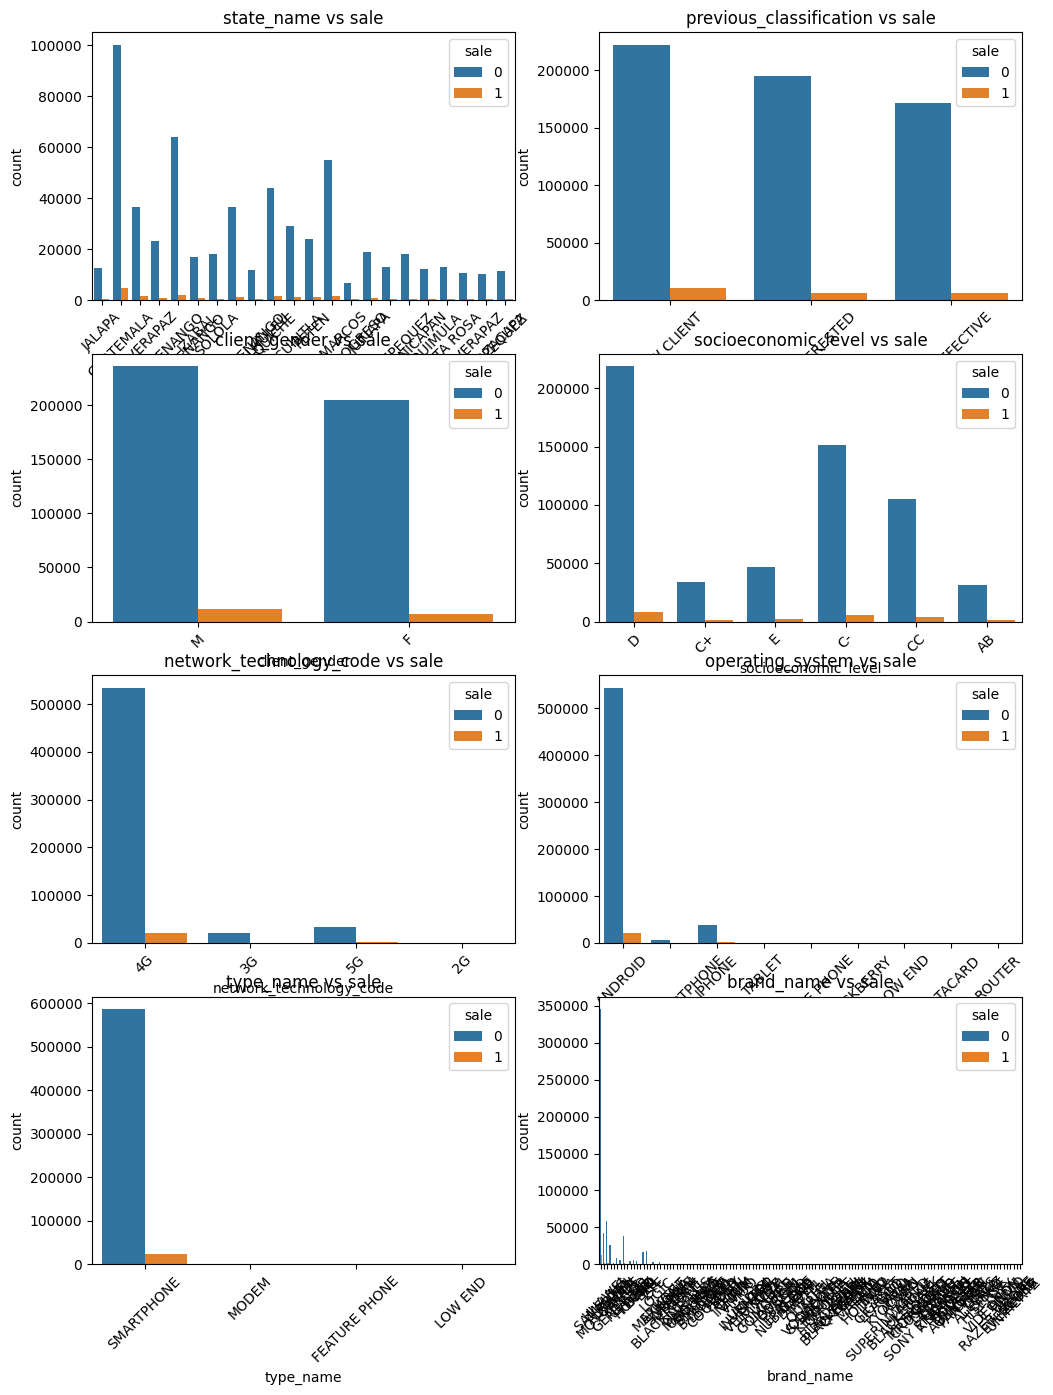

In [25]:

n = len(categorical_variables[:-1])
cols = 2
rows = math.ceil(n/cols)


fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4))
axes = axes.flatten()

for i, col in enumerate(categorical_variables[:-1]):
    sns.countplot(data=df, x=col, hue='sale', ax=axes[i])
    axes[i].set_title(f"{col} vs sale", fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout
plt.show()

#### explaining proportion of sales respectly categorical vars

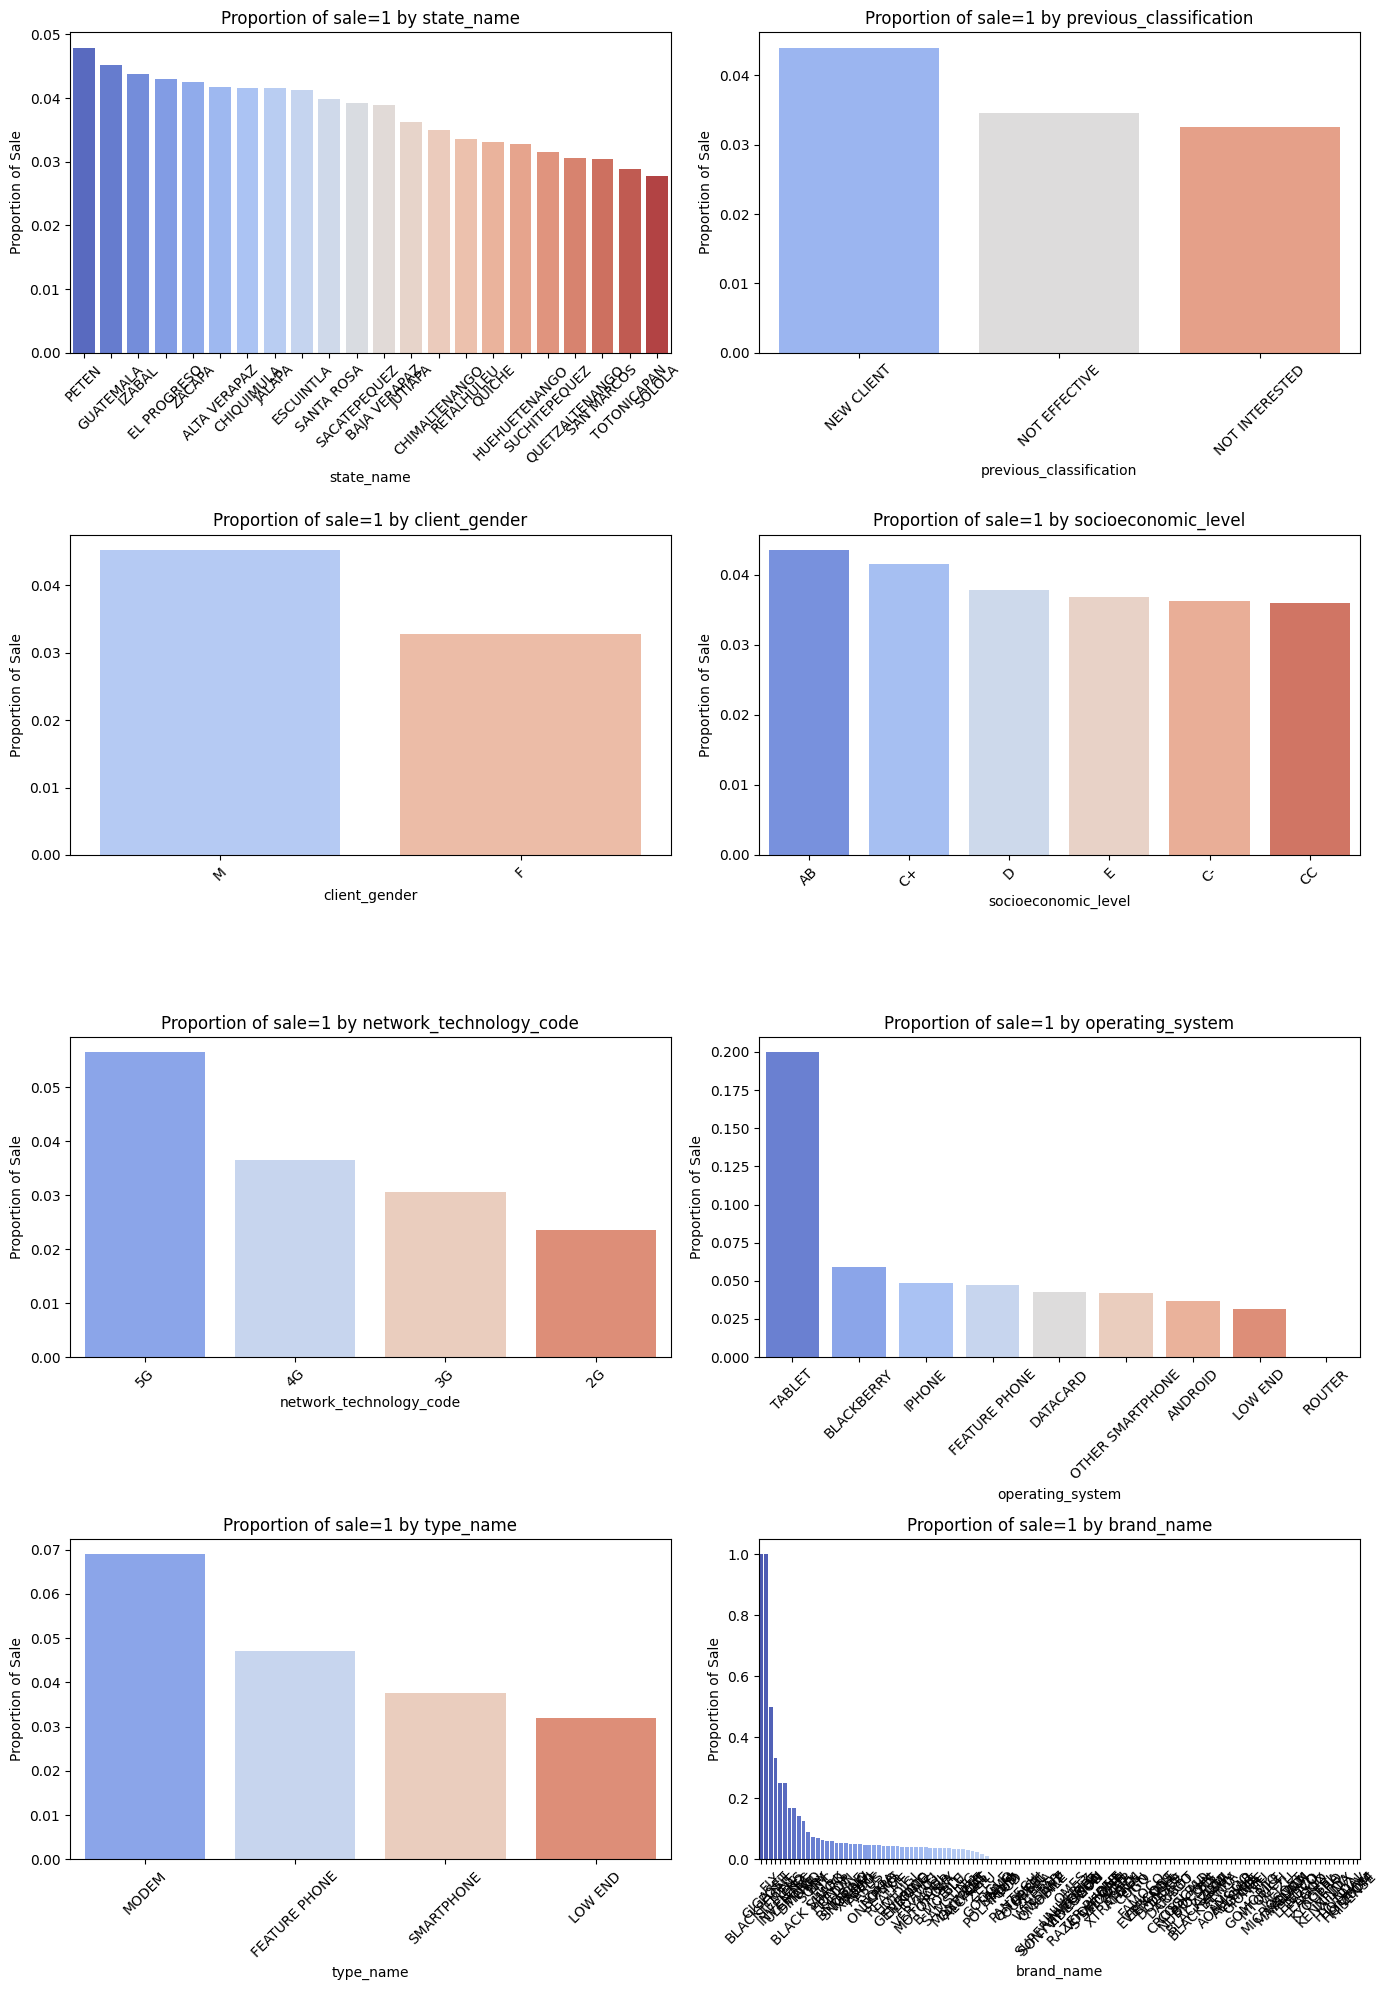

In [26]:
target = "sale"

cols = 2
rows = math.ceil(len(categorical_variables[:-1]) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*7, rows*5))
axes = axes.flatten()

for i, col in enumerate(categorical_variables[:-1]):
    prop = (
        df.groupby(col)[target]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    sns.barplot(data=prop, x=col, y=target, ax=axes[i], palette="coolwarm")
    axes[i].set_title(f"Proportion of {target}=1 by {col}", fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel("Proportion of Sale")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

#### Missing values

Identifying missing values in a dataset is a crucial step in the data preprocessing phase. Missing values can lead to inaccurate analyses, biased results, and errors in machine learning models. By detecting and handling missing data appropriately, we ensure the integrity and reliability of our subsequent data analysis and modeling processes.

In [27]:
missing = df[categorical_variables].isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent.round(2)
})

missing_df

,Missing Values,Percentage
client_gender,151655,24.86
network_technology_code,19,0.00
operating_system,19,0.00
type_name,19,0.00
brand_name,19,0.00
model_name,19,0.00
state_name,15,0.00
previous_classification,0,0.00
socioeconomic_level,0,0.00


*EDA*

Across all cuts the conversion rate is low (~3–5%), confirming **strong class imbalance**. Categorical signals are material: **previous_classification** is highly informative (NEW CLIENT highest, NOT INTERESTED lowest), **socioeconomic_level** shows a clear gradient (A/B, C+ > C/D/E), and **state_name** differences are present but secondary. **Technology and device** matter: 5G > 4G > 3G > 2G in sale proportion; **SMARTPHONE** dominates volume, while categories like **MODEM/TABLET/BLACKBERRY** can show high lift but with **small sample sizes**; **Android** concentrates most of the base. **brand_name** exhibits a long tail (high cardinality), requiring careful encoding.

Operationally, this suggests prioritizing campaigns toward segments with better **lift × volume** (NEW CLIENT, 4G/5G, higher socioeconomic tiers, smartphones) while tailoring scripts for low-propensity niches (NOT INTERESTED, 2G/3G). For modeling, expect **non-linear, multifactor effects**; use encodings aligned to cardinality (target vs one-hot), **rebalance classes**, and set the operating threshold via **precision/recall/F1** trade-offs. Finally, control for small-n volatility in niche device/OS buckets and keep explainability (e.g., **SHAP**) to translate scores into actionable reasons for telemarketing.


## Select Features

Feature selection is justified to enhance model accuracy, reduce overfitting, and simplify interpretation. By removing highly correlated, irrelevant, or redundant features, the model focuses on variables most likely to influence the target (`sale`). This approach also addresses issues like multicollinearity and missing data, ensuring the model is robust and generalizes well to new data. Selected features reflect both statistical relevance and practical business insights, supporting reliable predictions and actionable results.

In [28]:
selected_columns = [
    'state_name'
    , 'previous_classification'
    , 'previous_calls'
    #, 'previous_not_effective_count'
    #, 'previous_not_interested_count'
    #, 'client_gender'
    , 'client_age'
    #, 'client_has_nit'
    , 'network_age_years'
    #, 'rgus_prepaid'
    #, 'rgus_postpaid'
    #, 'rgus_home'
    , 'banking'
    , 'arpu_90_days'
    #, 'navegation_gb'
    #, 'minutes_out'
    , 'minutes_in'
    #, 'percent_of_weeks_with_data_purchase'
    #, 'purchase_average'
    , 'validity_average'
    , 'average_performance'
    #, 'socioeconomic_level'
    #, 'network_technology_code'
    #, 'operating_system'
    #, 'type_name'
    #, 'brand_name'
    #, 'model_name'
    #, 'class'
    , 'start_using_months'
    #, 'imei_first_use_months'
    #, 'imei_distinct_users'
    , 'contacts'
    #, 'tigo_contacts'
    , 'high_frequency_contacts'
    #, 'with_international_calls'
    #, 'state_city_equals'
    , 'plan_postpaid'
    #, 'arpu_gte_100'
    #, 'navigation_gte_5gb'
    , 'sn_banking'
    #, 'digital_months'
    #, 'digital_tokenized_card'
    , 'digital_index_mean'
    , 'connected_days'
    , 'charged_days'
    , 'apps_days'
    #, 'zero_rate_days'
    #, 'facebook_days'
    #, 'facebook_gb'
    #, 'tiktok_days'
    #, 'tiktok_gb'
    #, 'instagram_days'
    #, 'instagram_gb'
    #, 'whatsapp_days'
    #, 'whatsapp_gb'
    #, 'youtube_days'
    #, 'youtube_gb'
    #, 'music_days'
    , 'music_gb'
    , 'sale'
]

In [29]:
len(selected_columns)

21

In [30]:
df_selected = df[selected_columns]

In [31]:
df_selected.shape

(610083, 21)

## Calculation and Export of SHAP Values for the Entire Selected Dataset

In this section, the model will be applied to `df_selected`, and SHAP values will be computed for each sample. The results will be saved to a CSV file, and a summary plot will be displayed.


## Train/Test Split

In [32]:
df_train=df_selected.sample(frac=0.7,random_state=100)
df_test=df_selected.drop(df_train.index)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [33]:
df_train.shape

(427058, 21)

In [34]:
df_test.shape

(183025, 21)

In [35]:
df_train.describe()

,previous_calls,client_age,network_age_years,banking,arpu_90_days,minutes_in,validity_average,average_performance,start_using_months,contacts,high_frequency_contacts,plan_postpaid,sn_banking,digital_index_mean,connected_days,charged_days,apps_days,music_gb,sale
count,427058.000000,320879.000000,427057.000000,427058.000000,427058.000000,427058.000000,427058.000000,427058.000000,427040.000000,427058.000000,427058.000000,427058.000000,427058.000000,427058.000000,427058.000000,427058.000000,427058.000000,427058.000000,427058.000000
mean,1.406413,41.240527,3.753322,0.706590,129.689491,69.549010,7.122910,0.699338,10.769570,50.255820,0.521763,0.186584,0.365271,0.138517,85.851058,77.824621,3.388500,0.194037,0.037367
std,1.656201,12.445169,3.816367,0.455325,34.498689,110.727144,6.675478,0.179308,11.361819,38.084258,0.133990,0.190468,0.214550,0.287477,10.309549,16.046937,5.732648,0.897738,0.189660
min,0.000000,7.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,32.000000,1.090000,0.000000,105.010000,13.390000,2.680000,0.580000,2.000000,25.000000,0.440000,0.050000,0.220000,0.000000,86.000000,71.000000,0.000000,0.000000,0.000000
50%,1.000000,40.000000,2.530000,1.000000,120.220000,35.990000,5.240000,0.720000,7.000000,41.000000,0.520000,0.140000,0.330000,0.000000,91.000000,84.000000,1.000000,0.000000,0.000000
75%,2.000000,49.000000,4.950000,1.000000,145.380000,82.910000,8.110000,0.840000,16.000000,65.000000,0.610000,0.260000,0.480000,0.060000,91.000000,90.000000,4.000000,0.000000,0.000000
max,27.000000,2022.000000,25.370000,1.000000,740.730000,9047.500000,30.000000,1.500000,93.000000,450.000000,1.000000,1.000000,1.000000,1.000000,91.000000,91.000000,75.000000,65.499000,1.000000


## Explanation of Transformations

The pipeline applies several transformations to prepare the data for modeling:

- **Target Encoding (`state_name`)**: Converts categorical values into numerical representations based on the target variable, improving predictive power for categorical features.
- **One Hot Encoding (`previous_classification`)**: Expands categorical variables into multiple binary columns, allowing models to interpret categories independently.
- **Outlier Handling & Imputation (`client_age`, `network_age_years`, `start_using_months`)**: Sets out-of-range values to NaN and imputes missing values using the median, ensuring data consistency and reducing bias from missing data.
- **Truncation (`minutes_in`, `average_performance`)**: Caps values at specified thresholds to limit the influence of extreme outliers.
- **Quantile Transformation**: Applies a quantile-based normalization to selected numerical features, making their distributions more Gaussian-like and improving model performance.
- **Yeo-Johnson Transformation**: Applies a power transformation to selected features, stabilizing variance and making data more normal-distributed.
- **Debug Step**: Outputs the shape and saves the transformed data for inspection.
- **Classifier**: Trains the XGBoost model on the processed features.

These steps collectively clean, normalize, and encode the data, ensuring robust and effective model training.

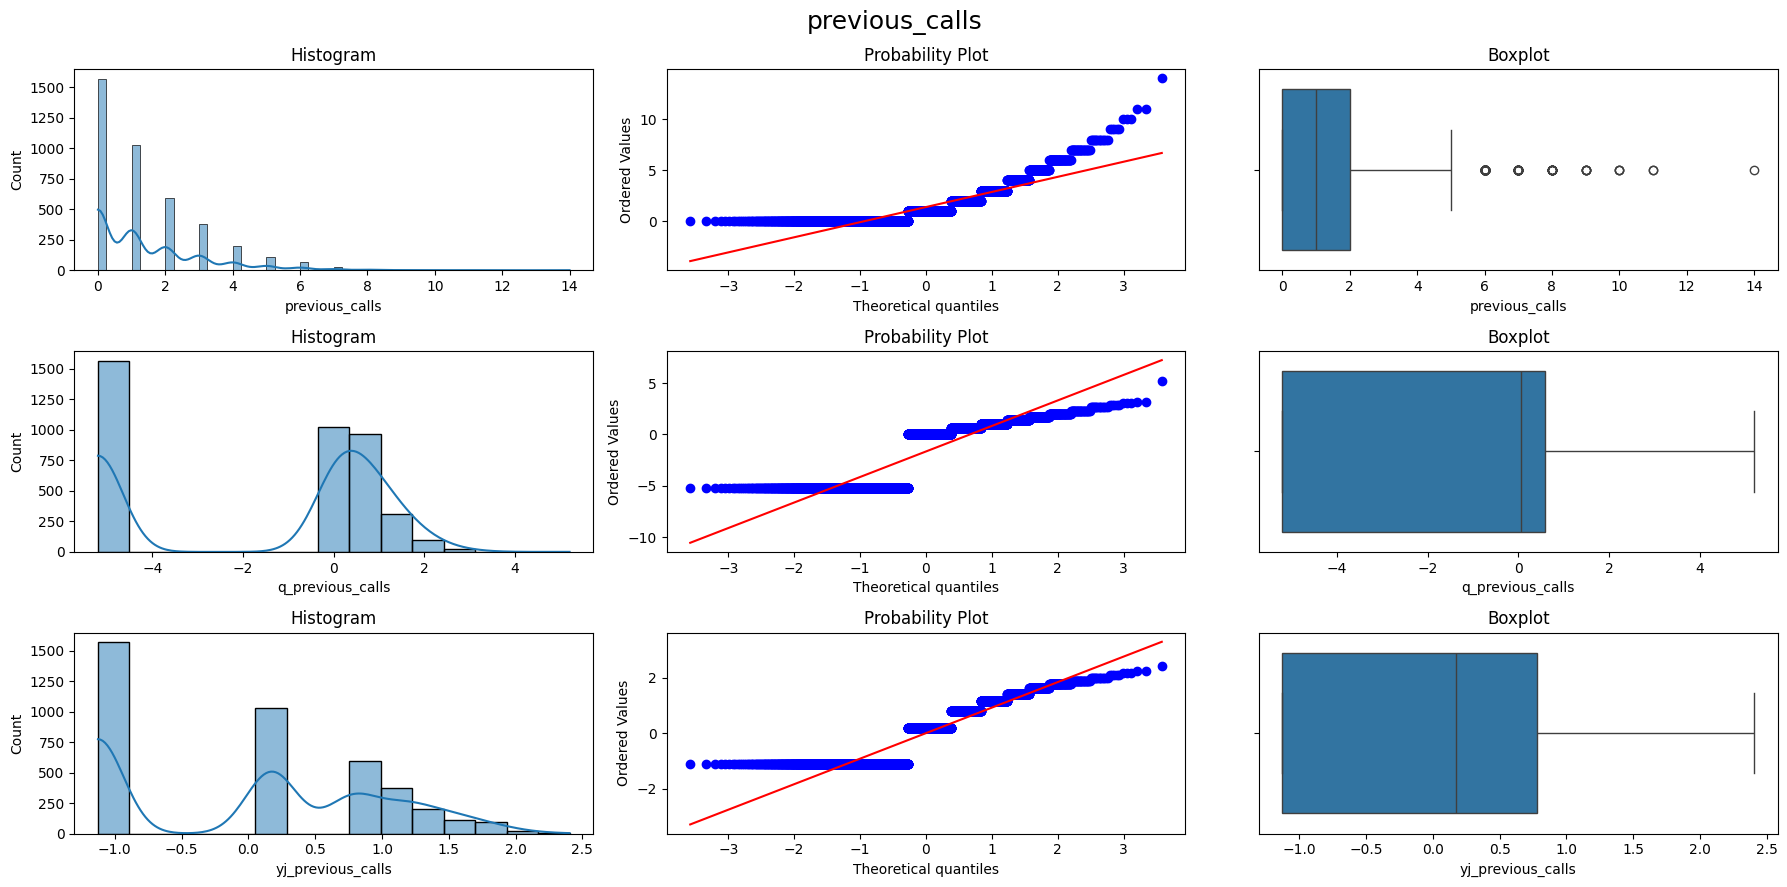

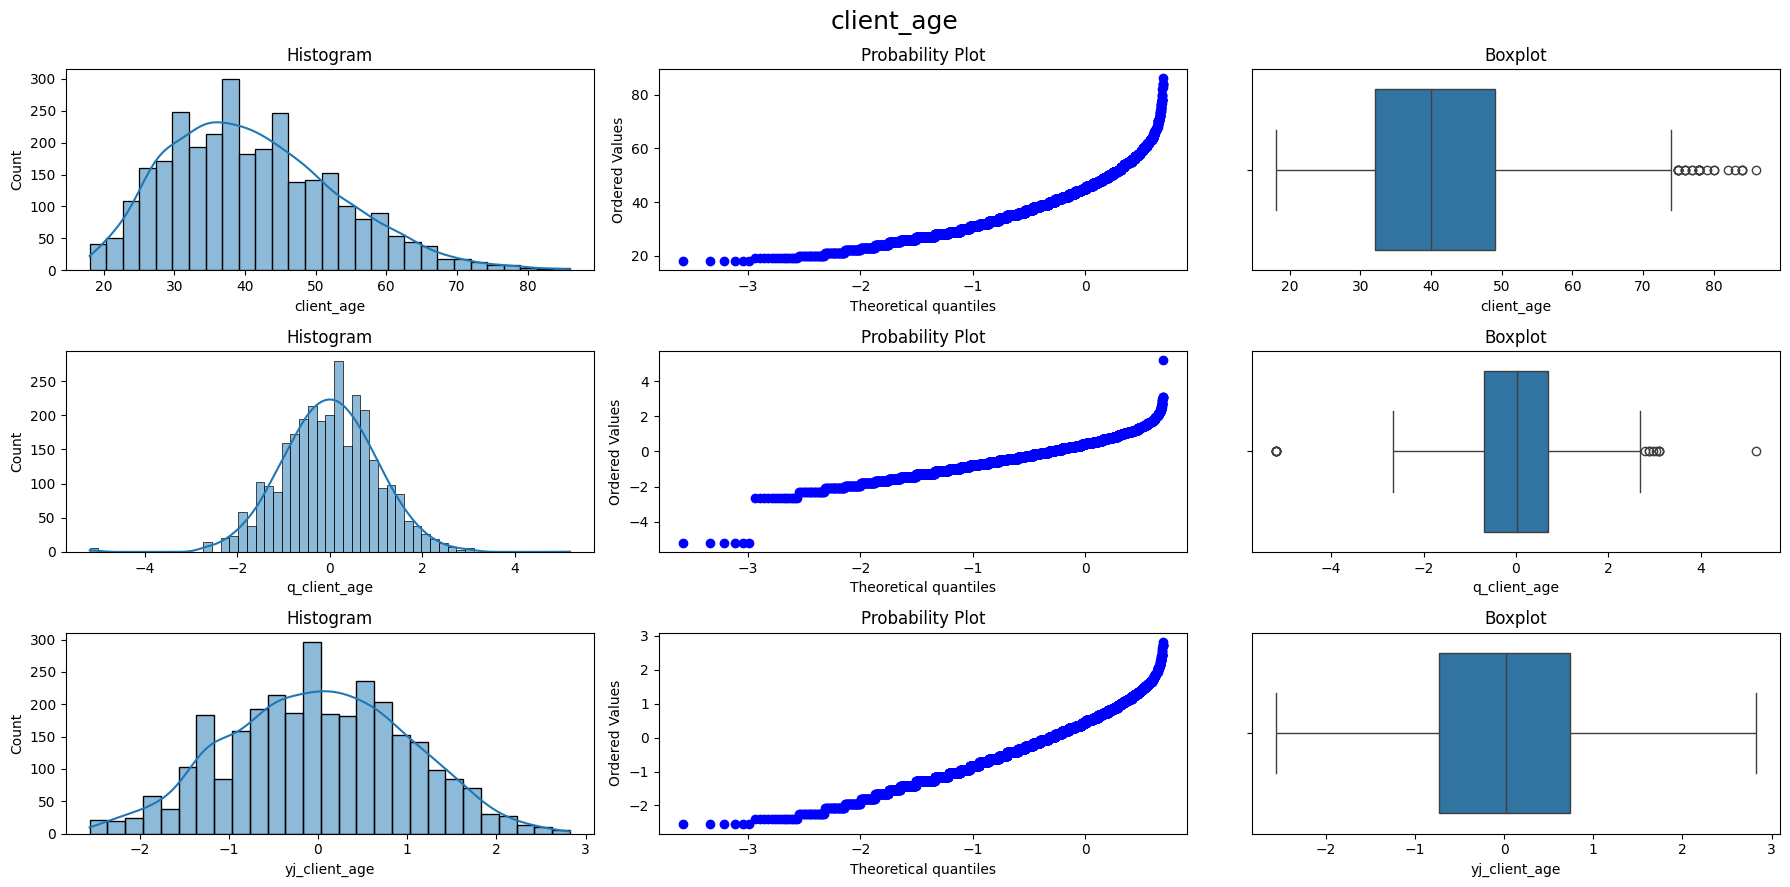

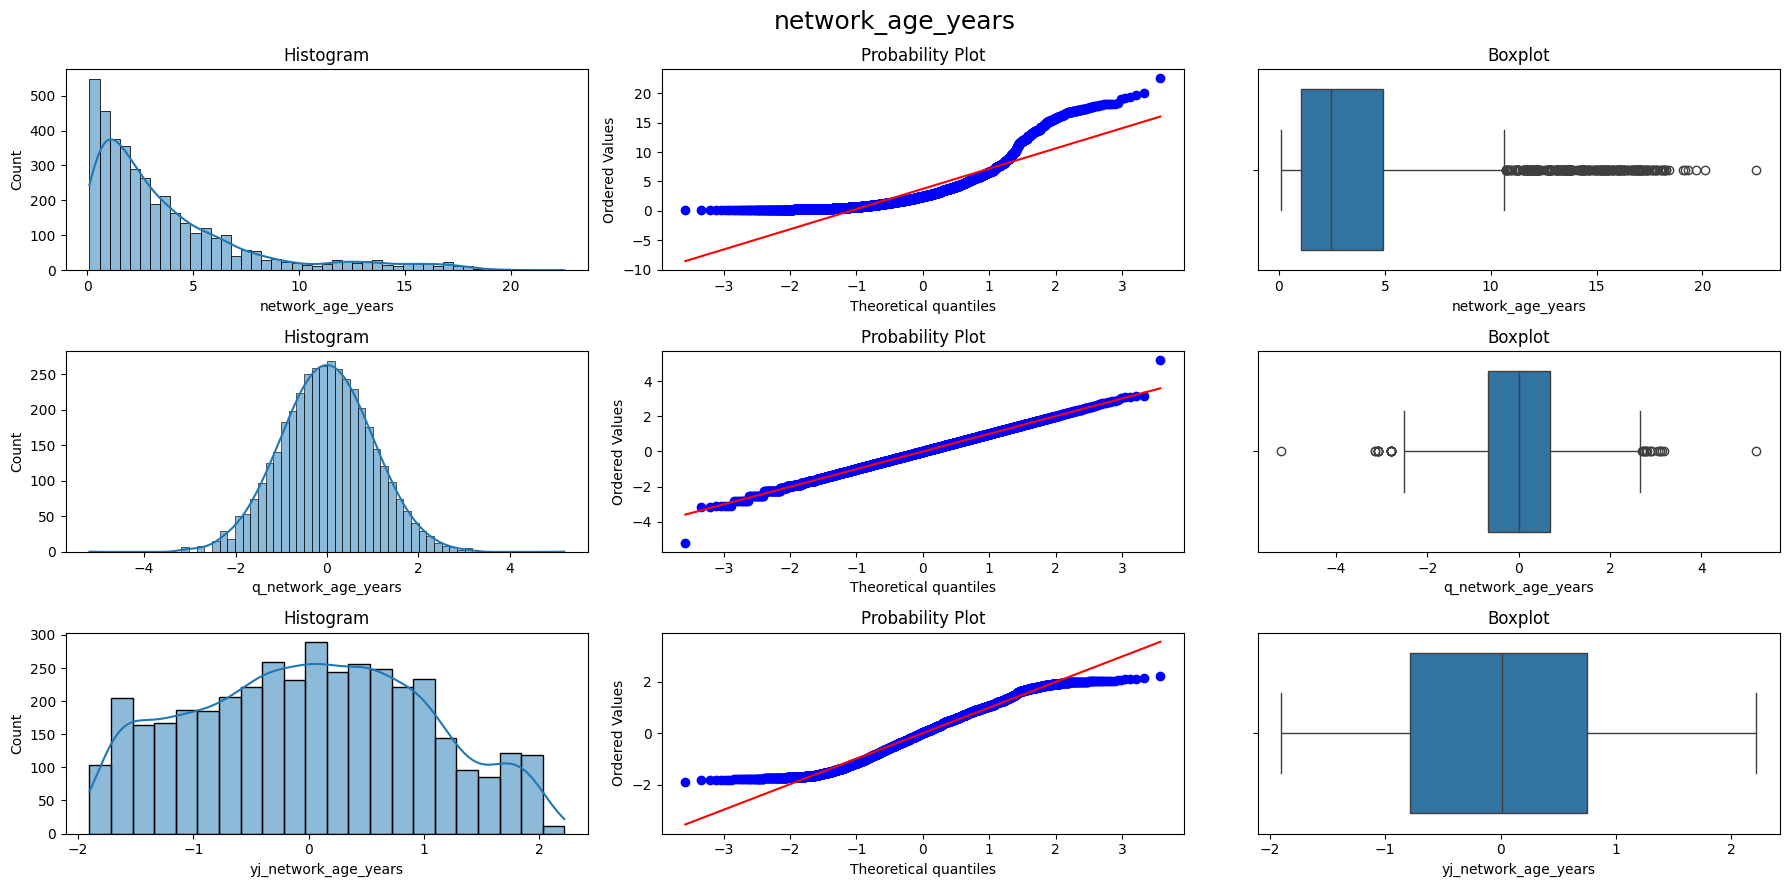

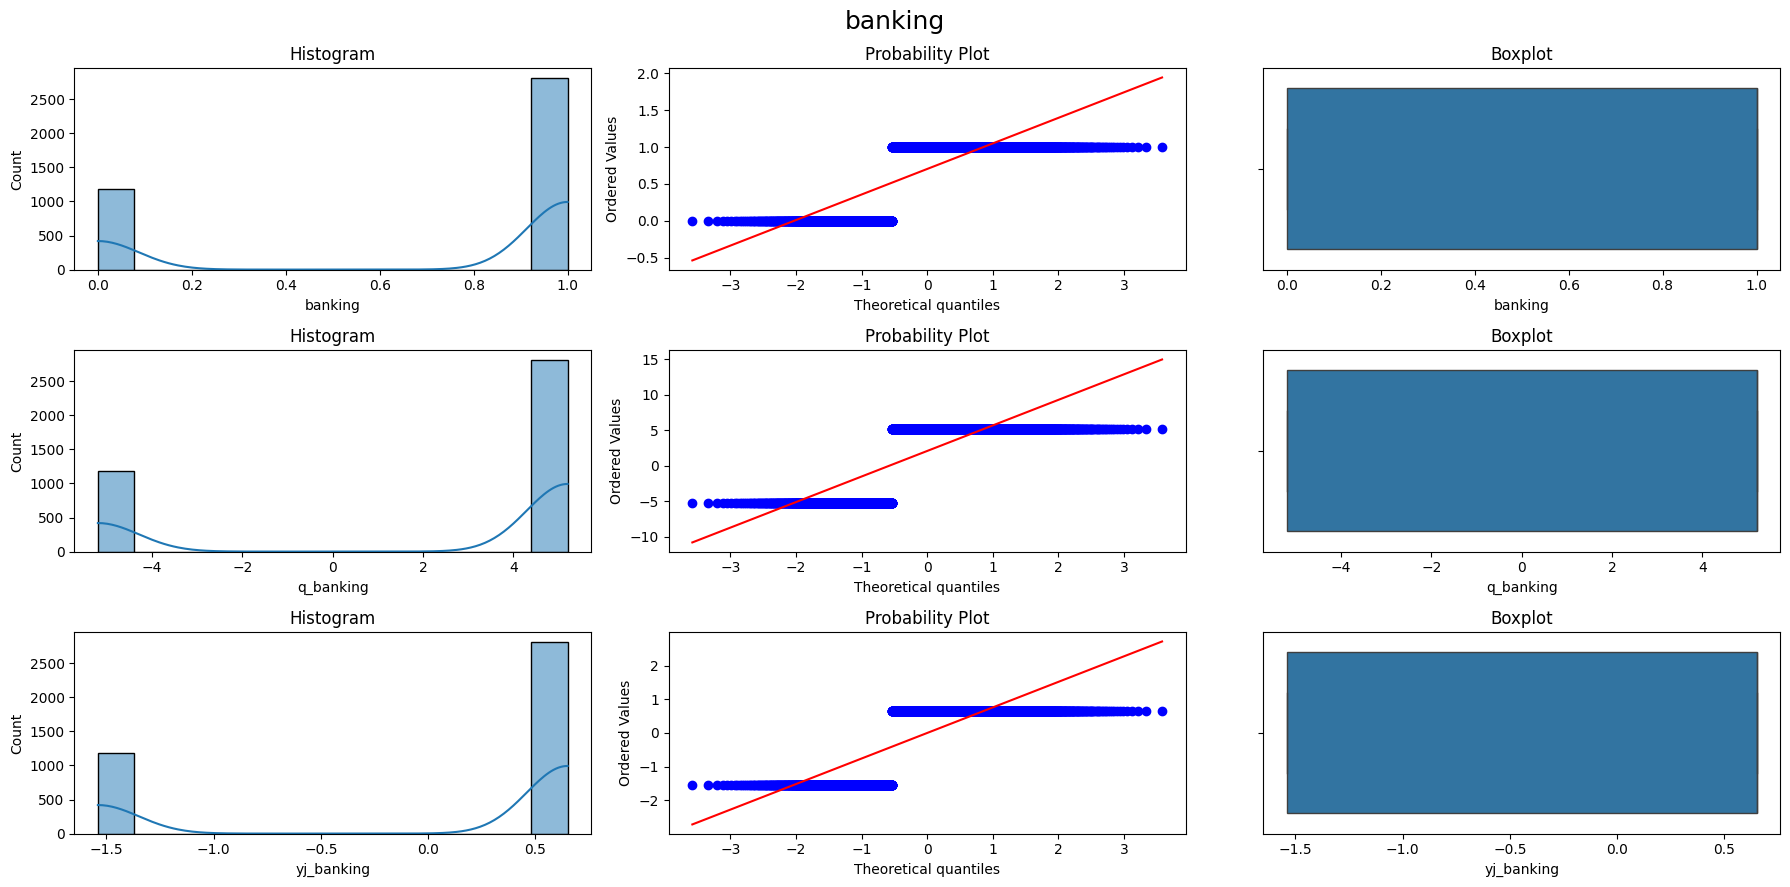

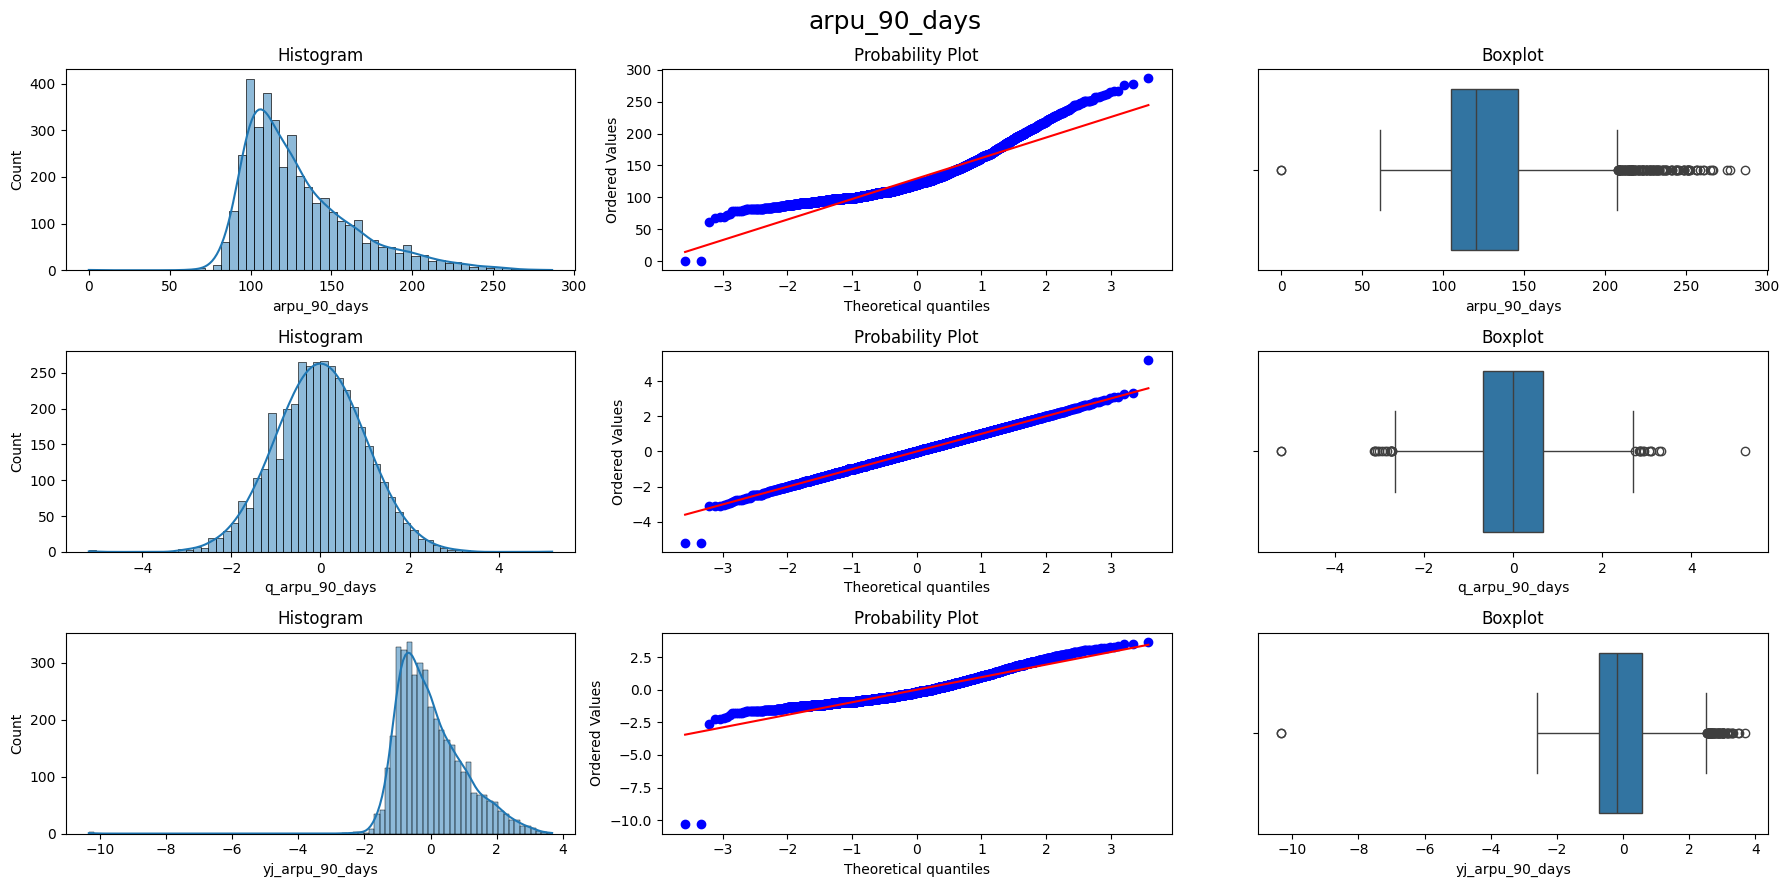

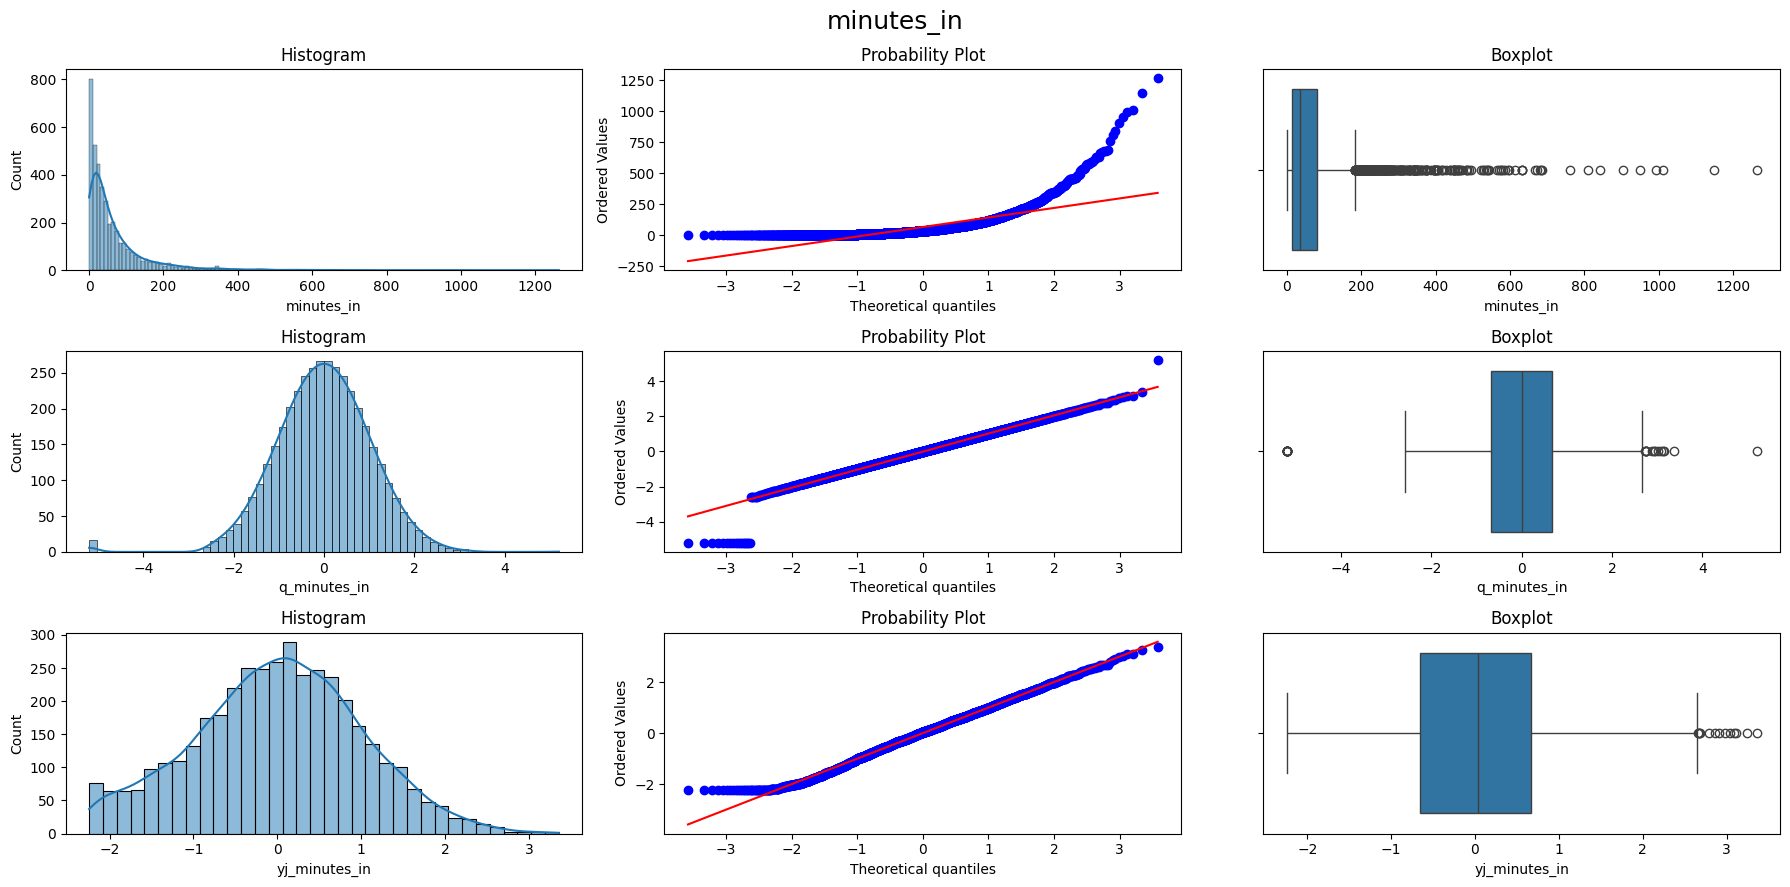

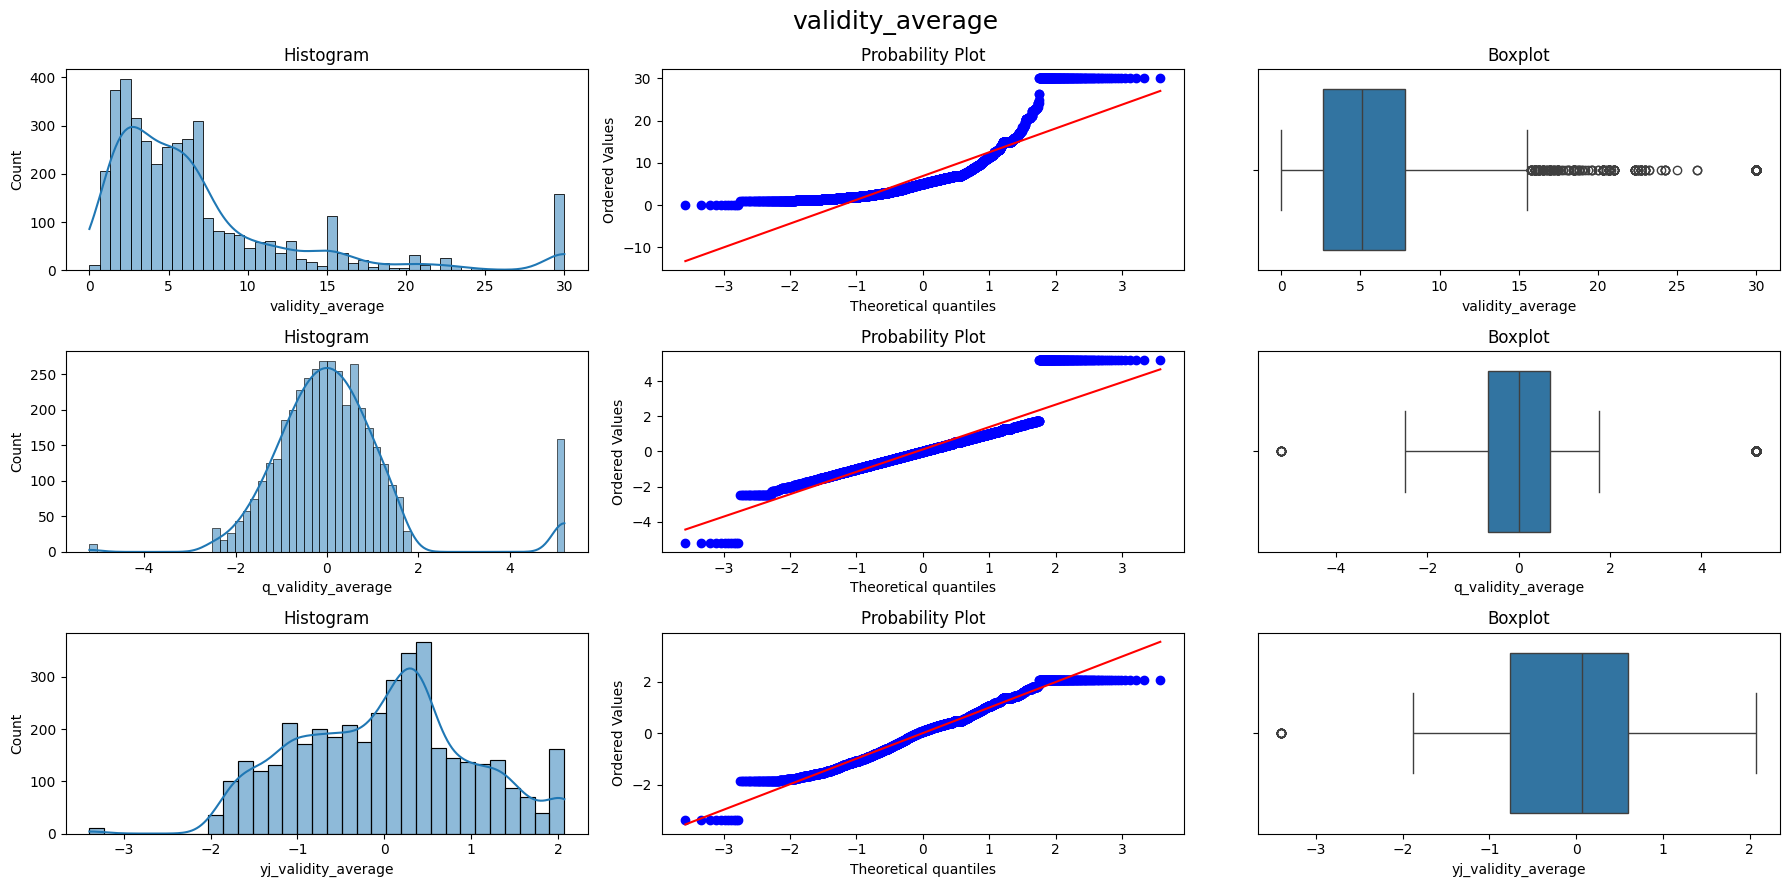

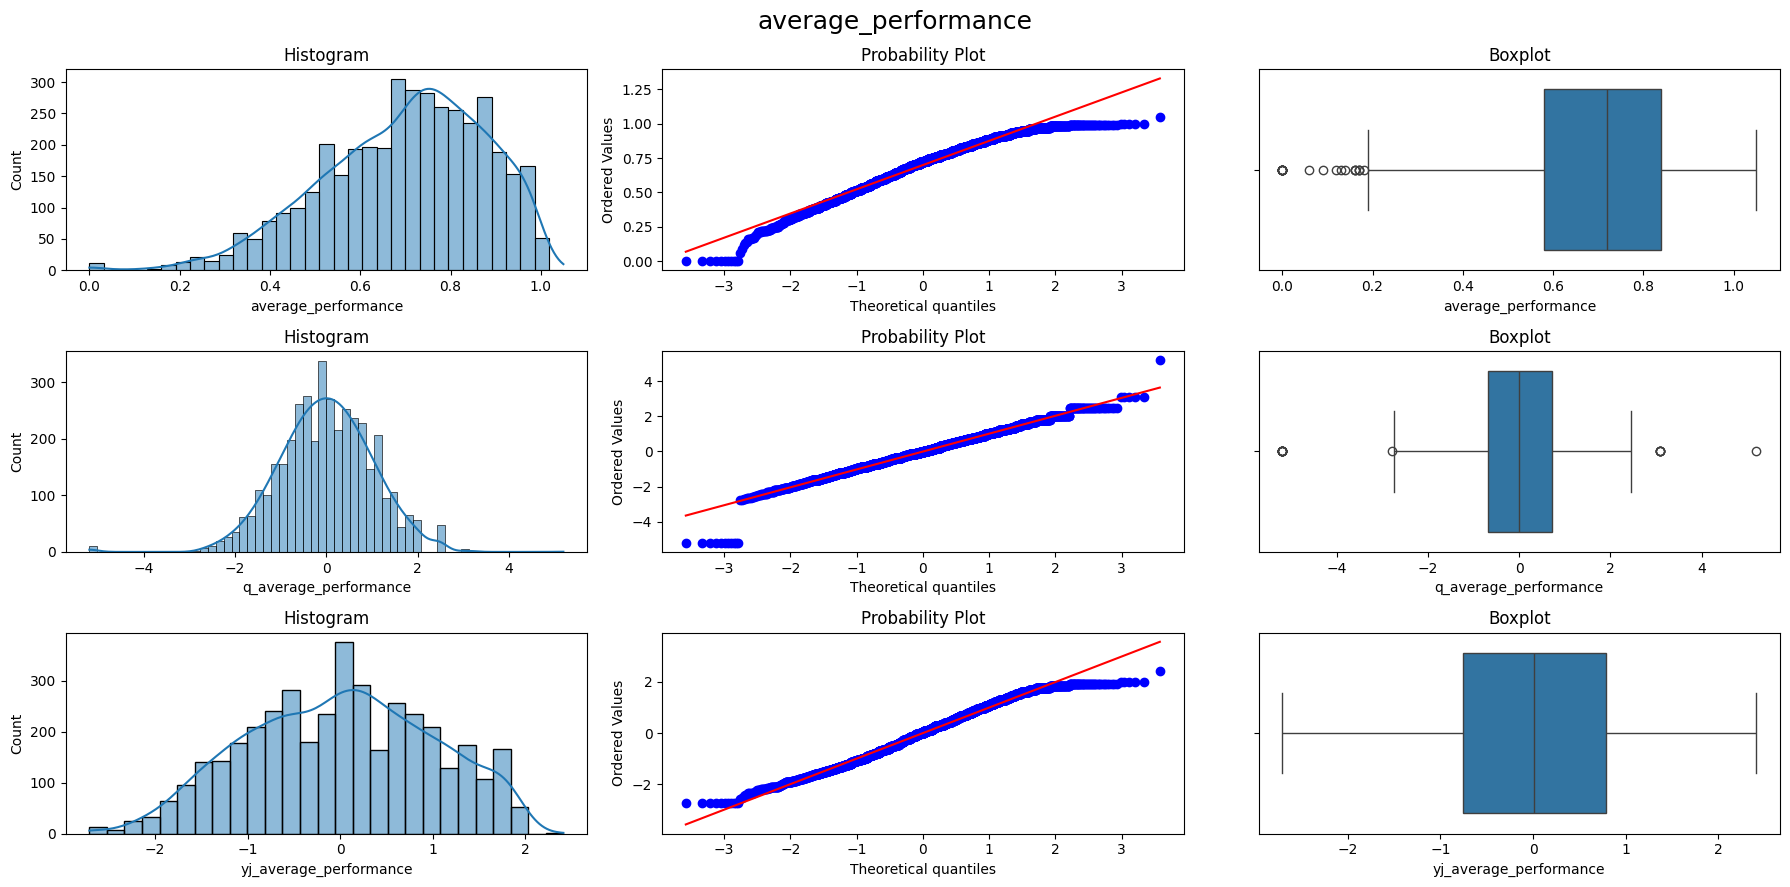

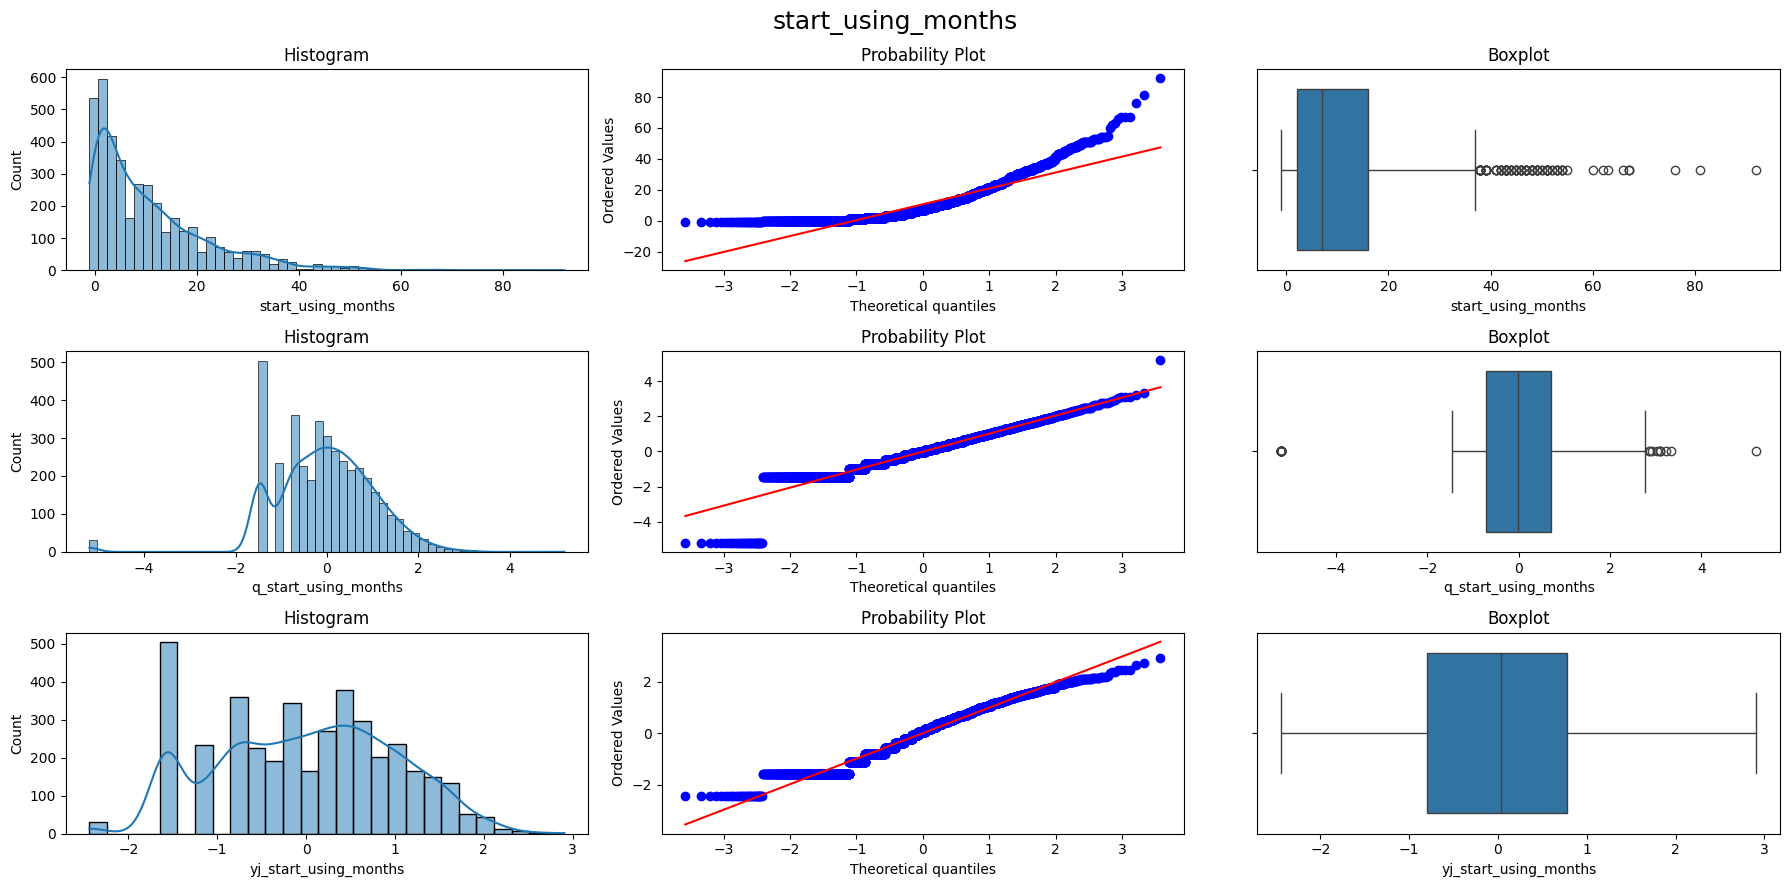

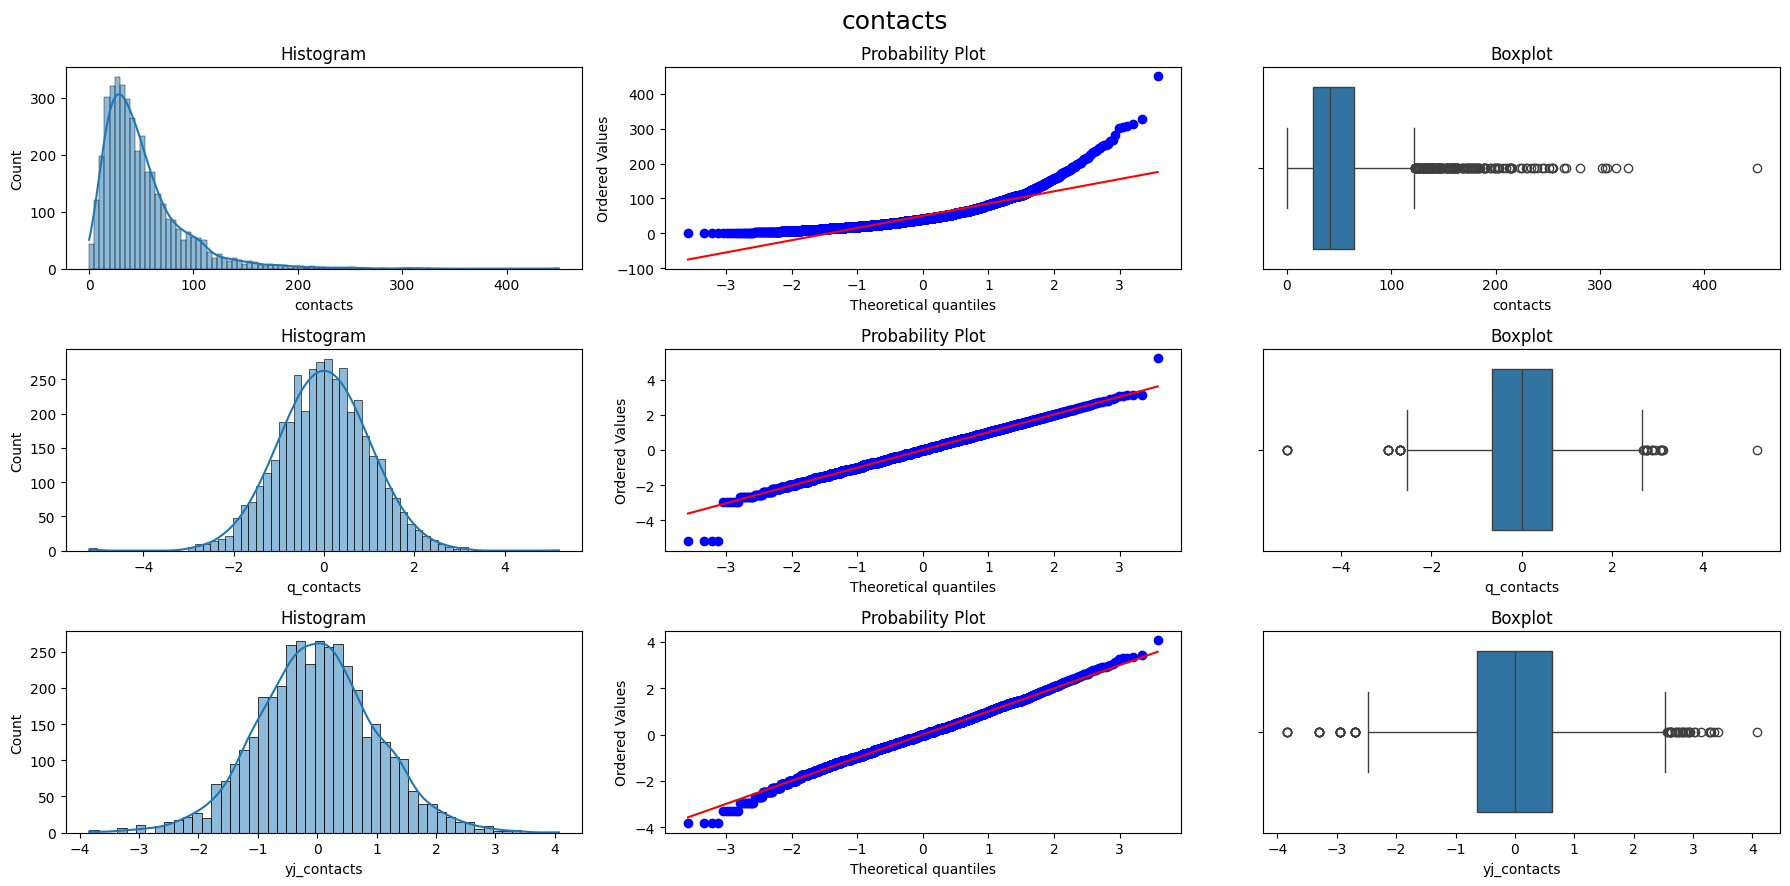

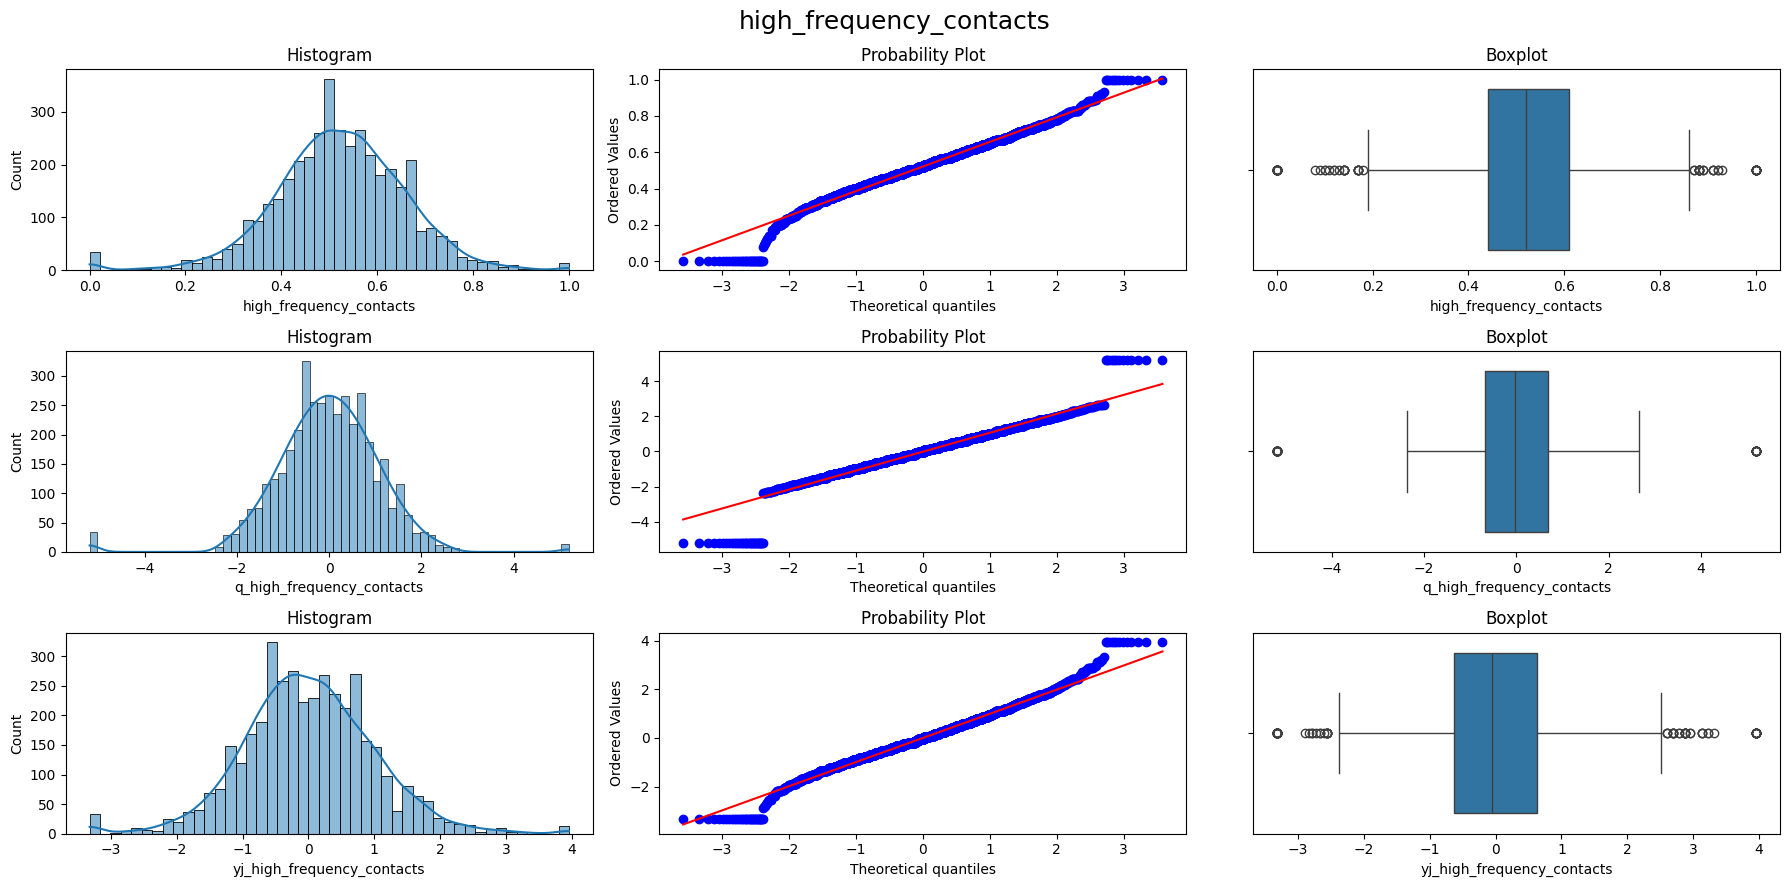

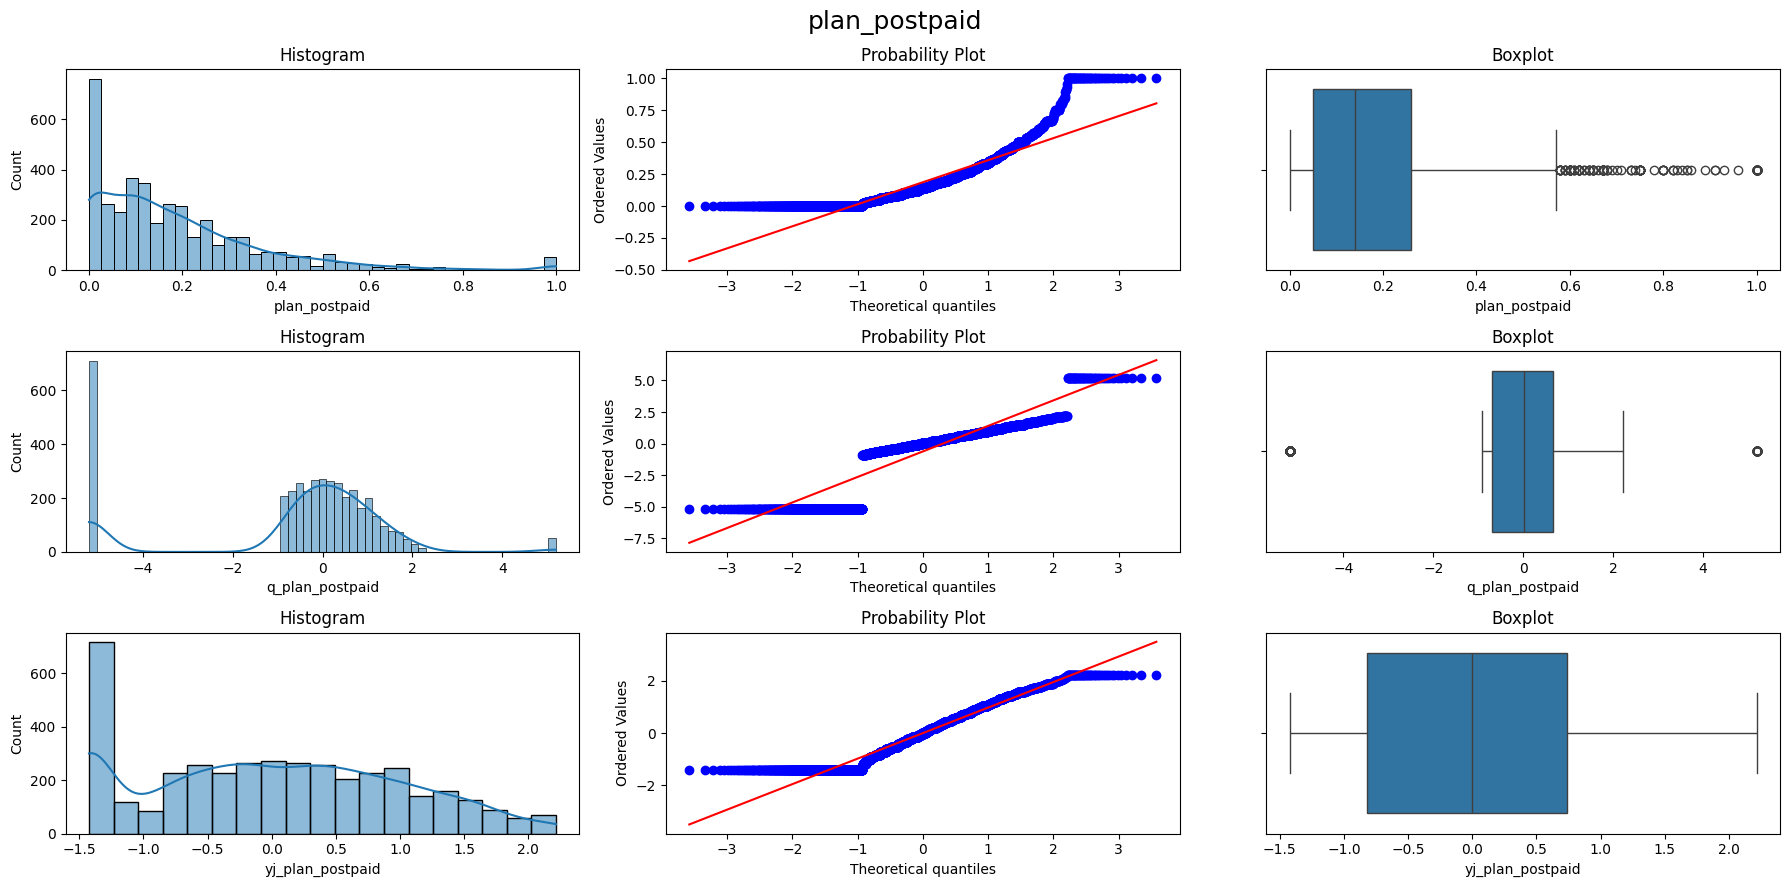

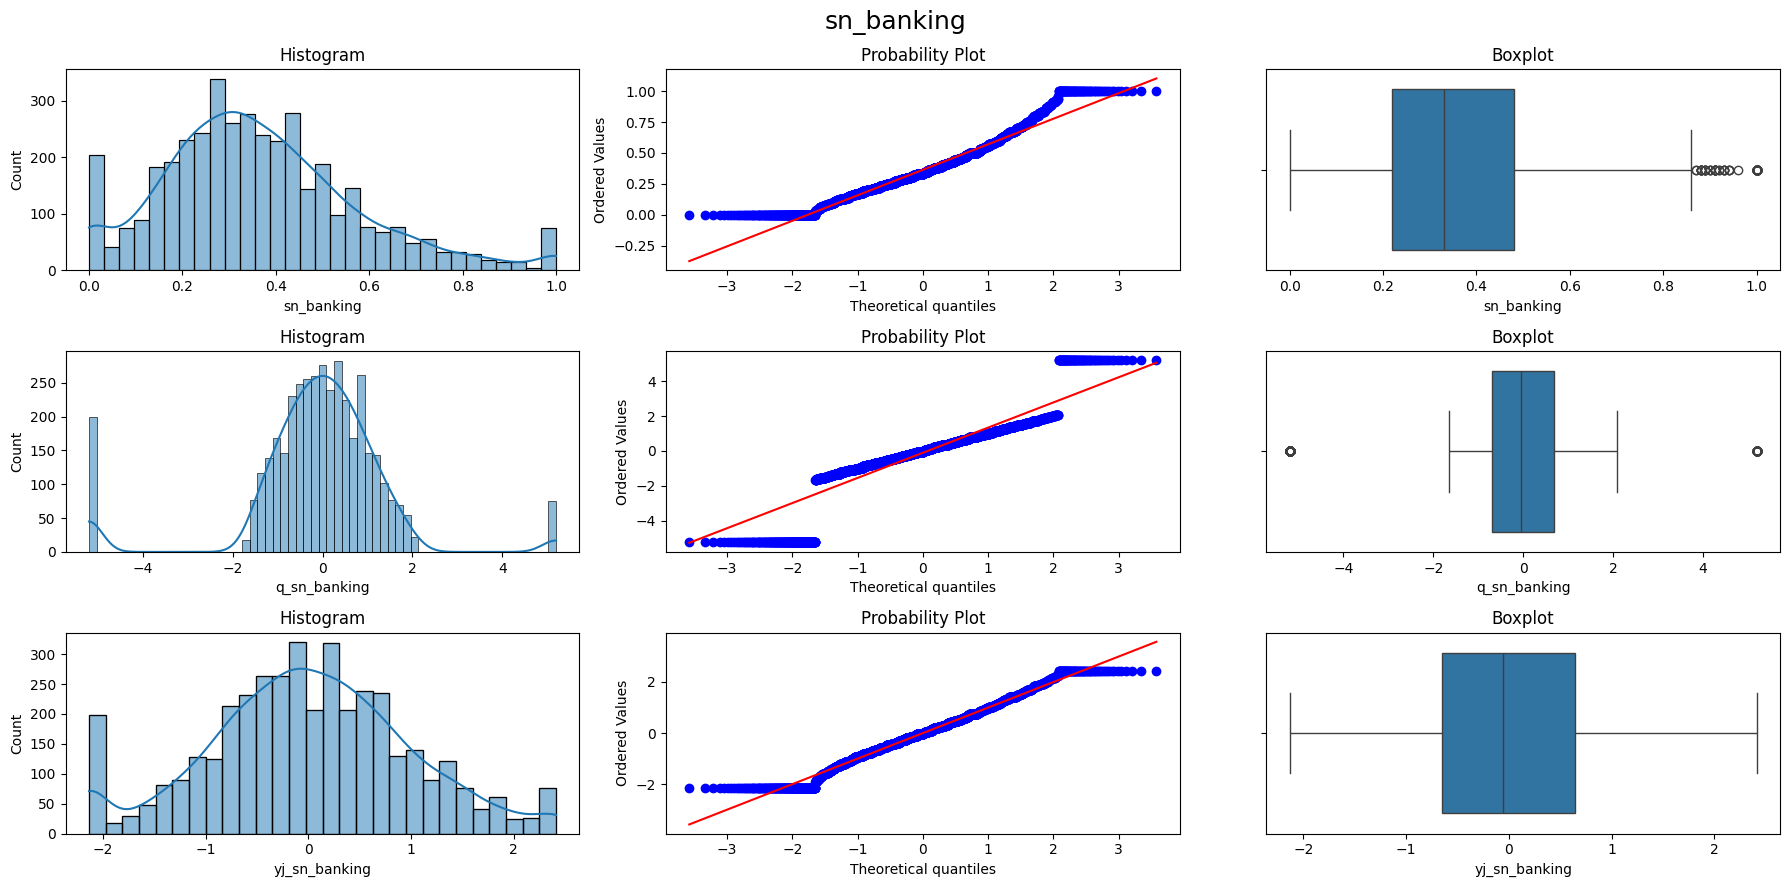

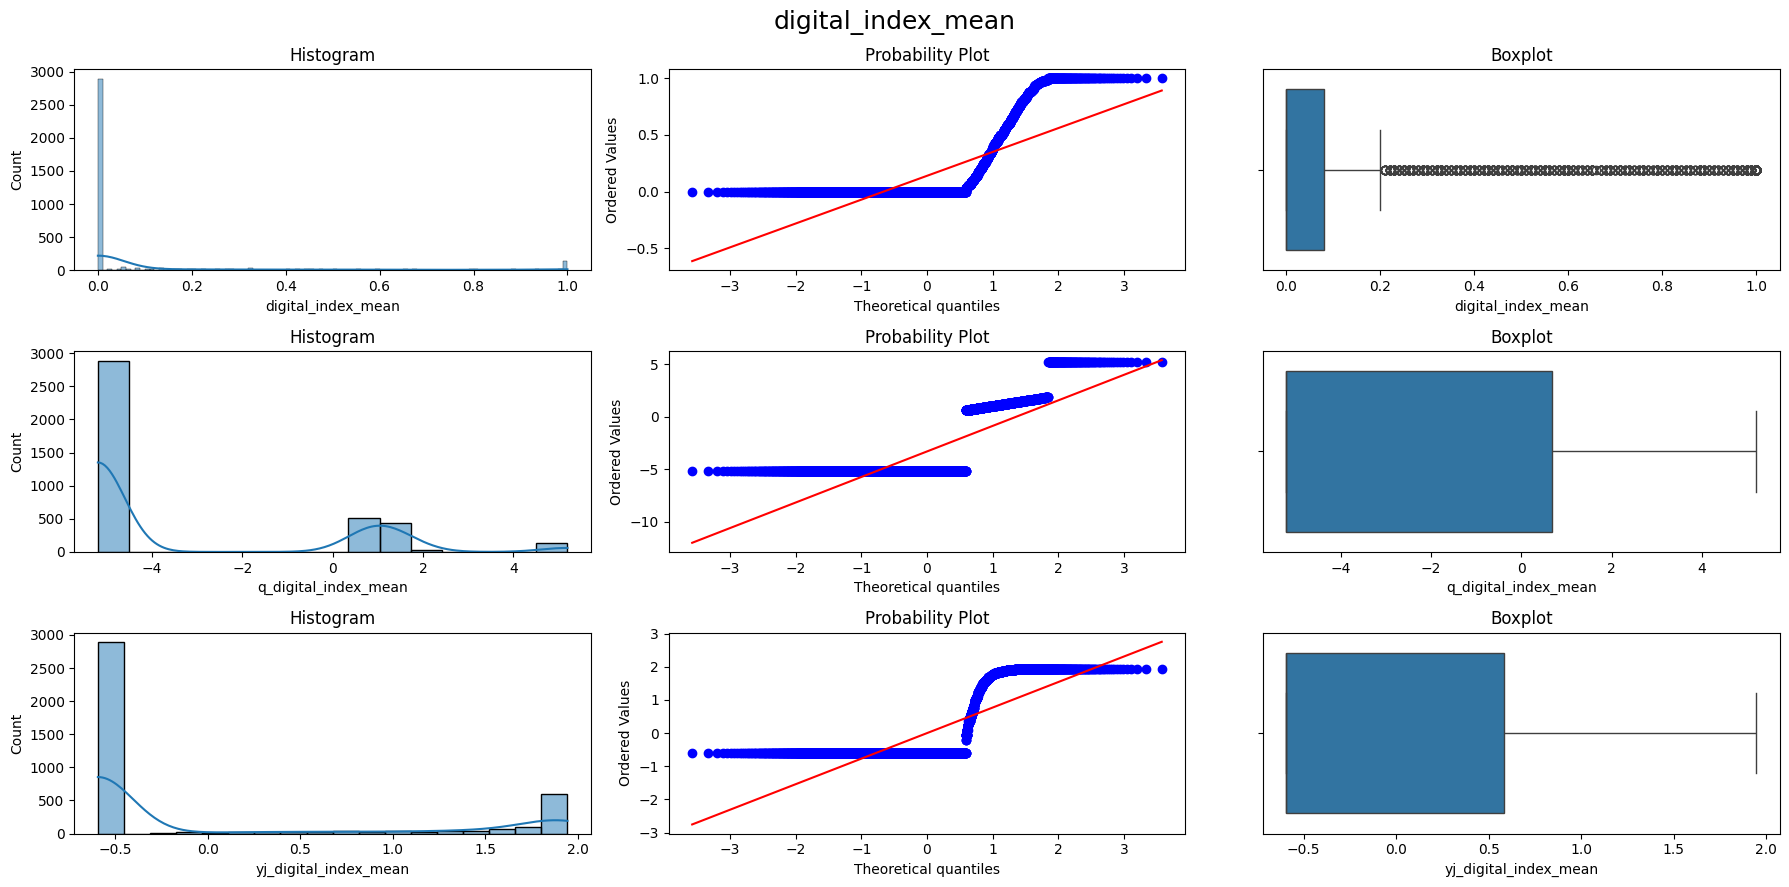

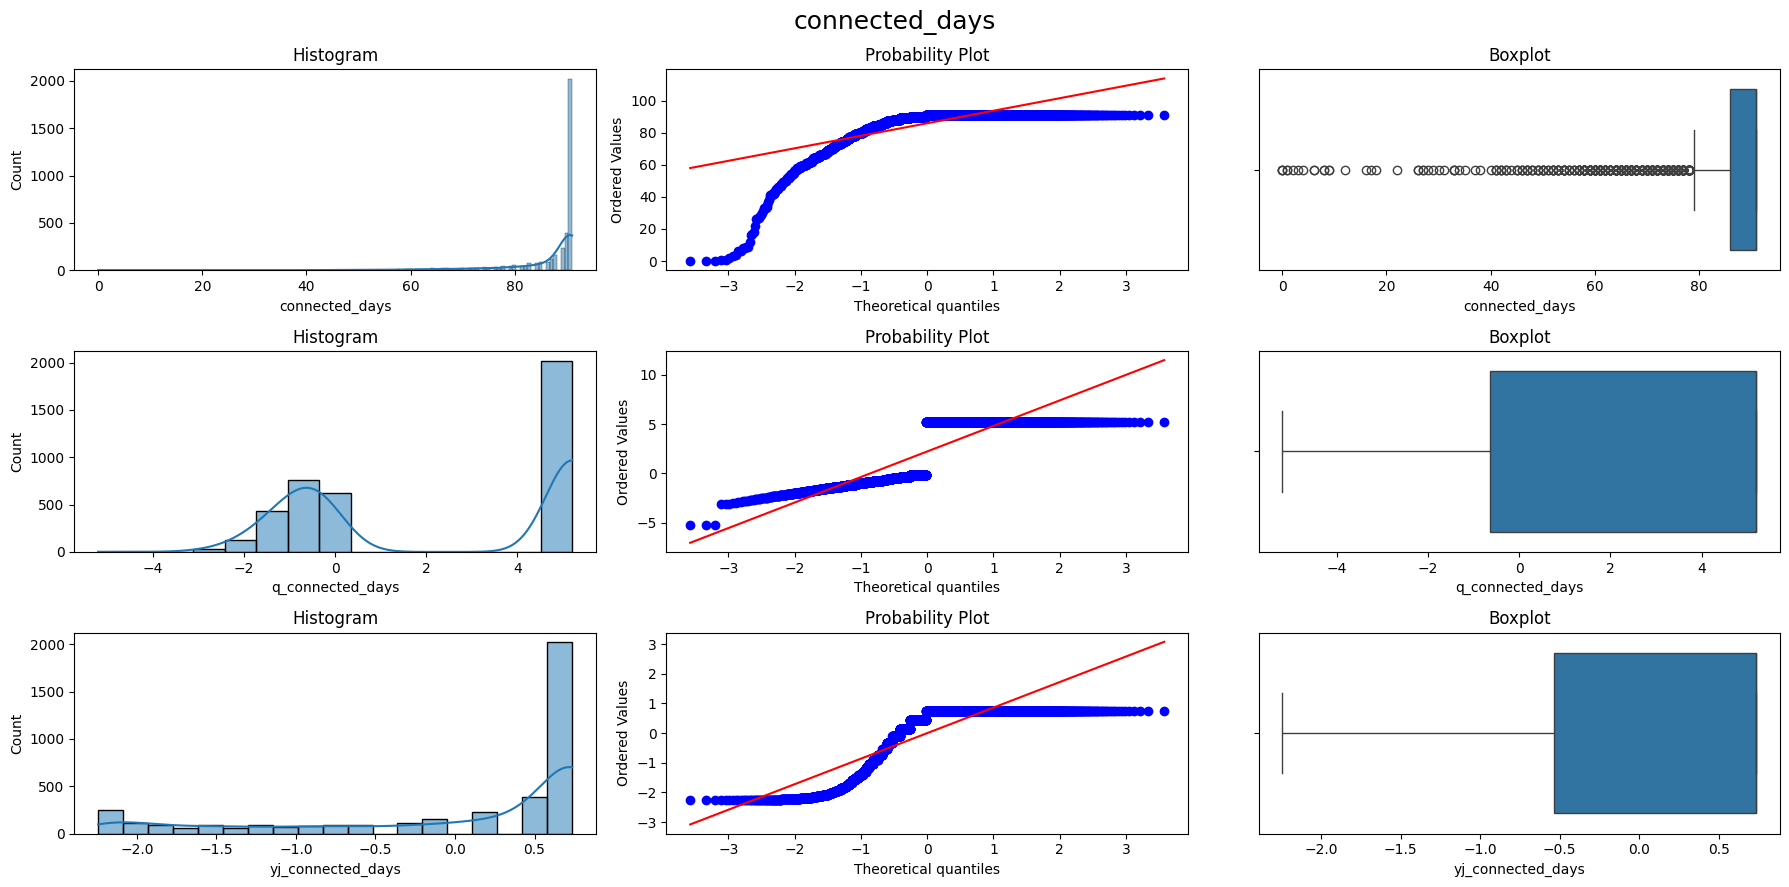

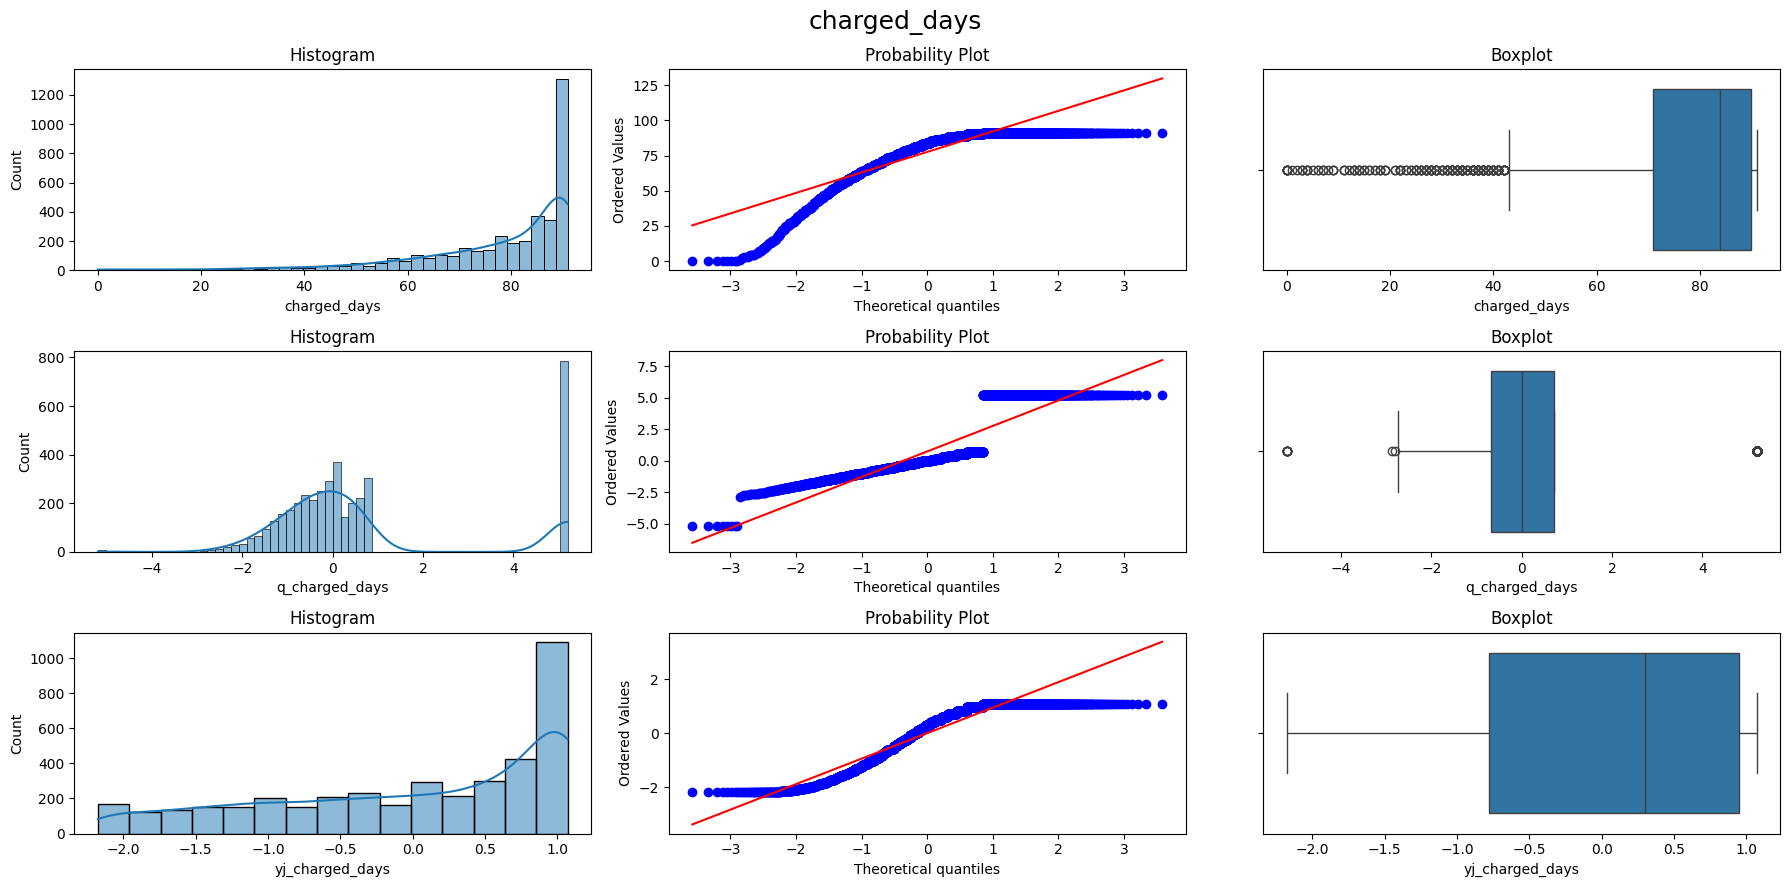

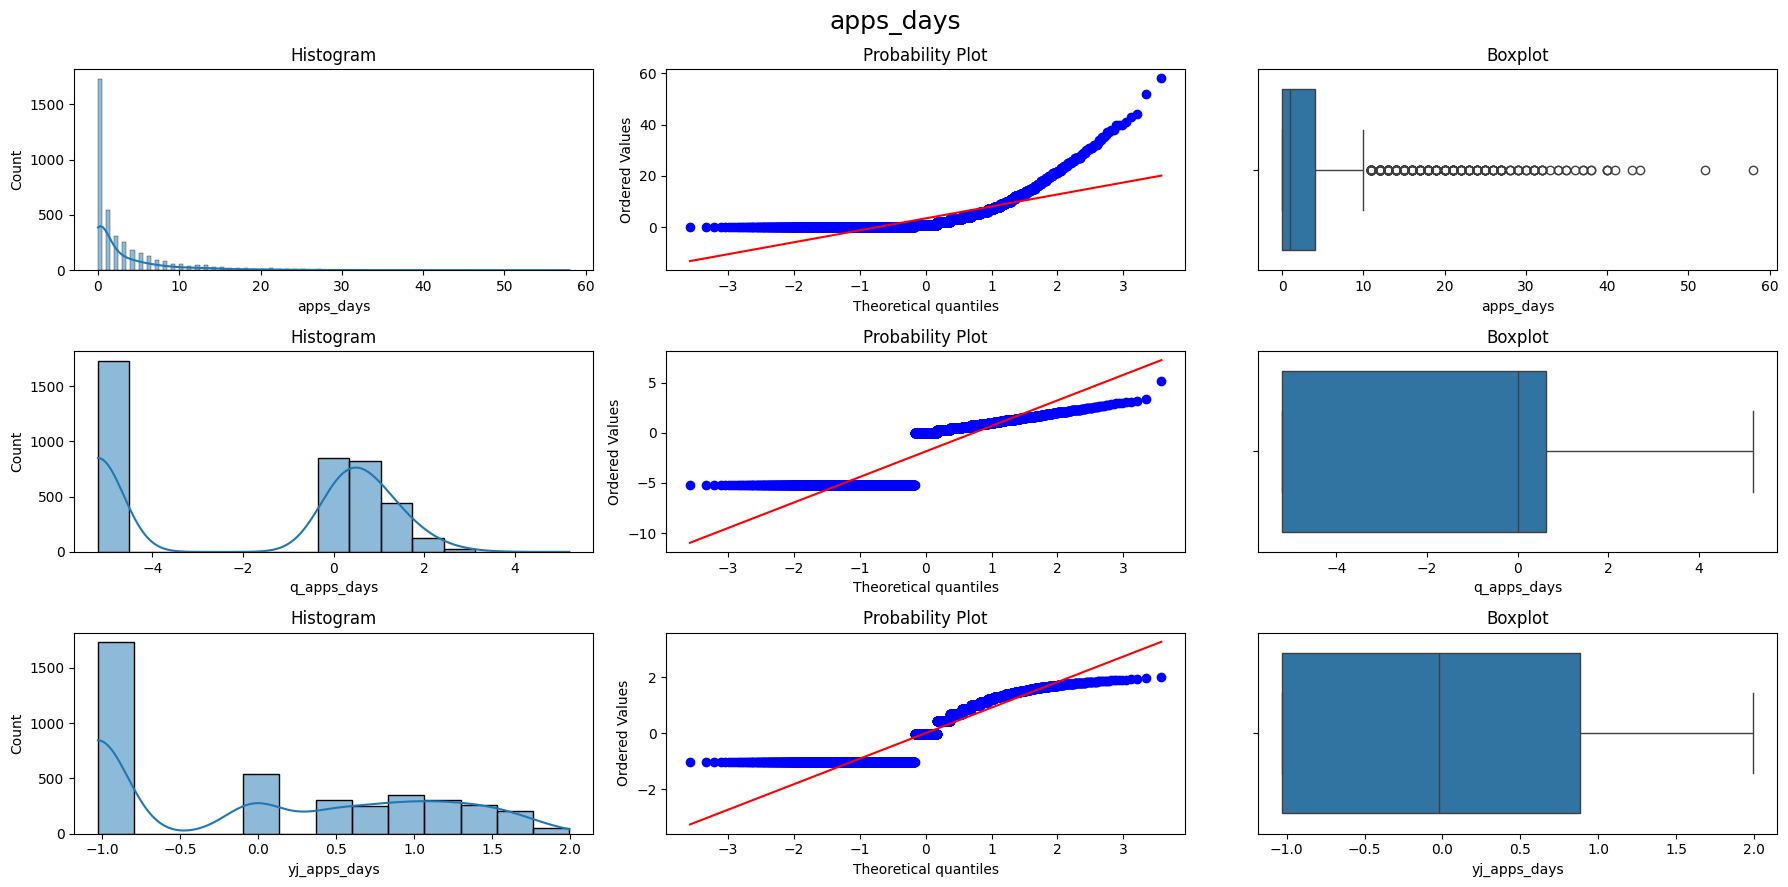

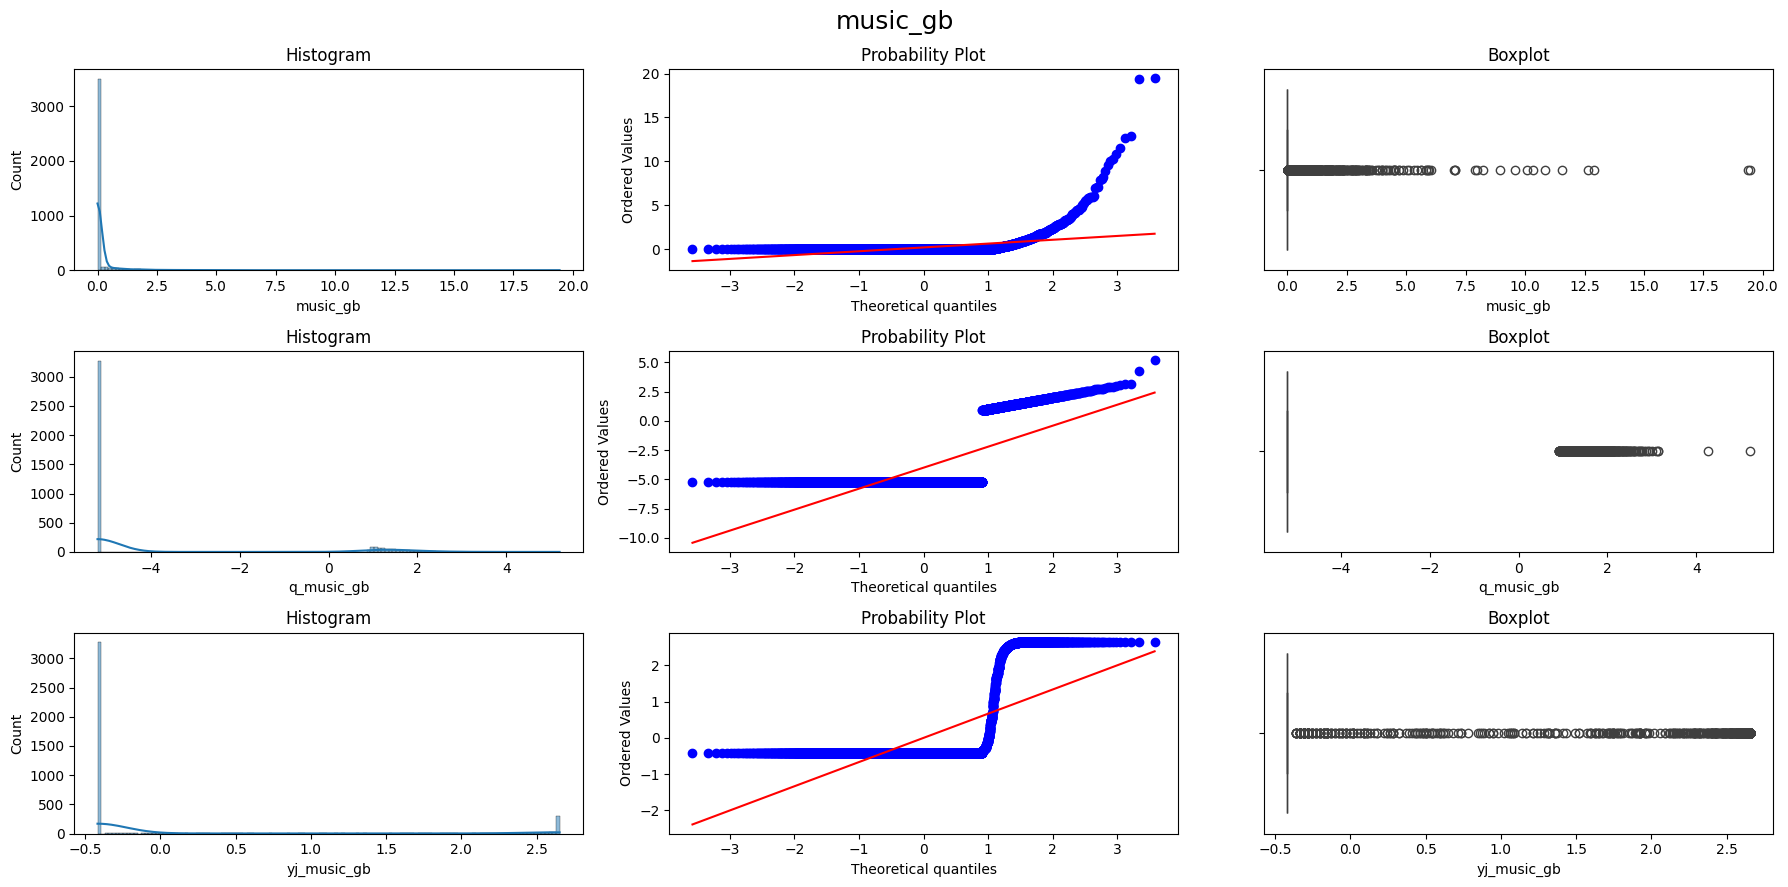

In [36]:
df_train_sample = df_train.sample(4000)

for col in df_train_sample.columns[2:len(df_train_sample.columns)-1]:
    plot_hist_prob(df_train_sample, col)

Using `plot_hist_prob`, the before/after panels show a consistent pattern: most numeric features (e.g., `previous_calls`, `network_age_years`, `arpu_90_days`, `minutes_in`, `start_using_months`, `contacts`) start highly right-skewed with long tails and many outliers; the **QuantileTransformer→normal** version yields the straightest QQ lines, bell-shaped histograms, and compressed whiskers—i.e., variance stabilized and extremes tamed. Overall, the transformed views indicate cleaner, near-Gaussian feature shapes with fewer leverage points, which aligns with the behavior seen across all plotted columns.



## Resampling

In [37]:
train_X, train_y = df_split(df_train)
test_X, test_y = df_split(df_test)

In [38]:
train_X_resampled, train_y_resampled = under_sampling(train_X, train_y, ratio=0.85)

Revisar cómo quedó el remuestreo en el balance de las clases

In [39]:
train_y.mean()

np.float64(0.03736728968898838)

In [40]:
train_y_resampled.mean()

np.float64(0.45946101577795695)

Revisar el tamaño del dataset de entrenamiento

In [41]:
train_X.shape

(427058, 20)

In [42]:
train_X_resampled.shape

(34732, 20)

# Data Pipeline

* Cleaning
* Training

In [43]:
train_X_resampled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34732 entries, 51020 to 426991
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   state_name               34732 non-null  object 
 1   previous_classification  34732 non-null  object 
 2   previous_calls           34732 non-null  int64  
 3   client_age               26720 non-null  float64
 4   network_age_years        34732 non-null  float64
 5   banking                  34732 non-null  int64  
 6   arpu_90_days             34732 non-null  float64
 7   minutes_in               34732 non-null  float64
 8   validity_average         34732 non-null  float64
 9   average_performance      34732 non-null  float64
 10  start_using_months       34729 non-null  float64
 11  contacts                 34732 non-null  int64  
 12  high_frequency_contacts  34732 non-null  float64
 13  plan_postpaid            34732 non-null  float64
 14  sn_banking            

In [44]:
model = XGBClassifier(max_depth = 2, random_state=123)
model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Train transformation with all the data.

In [45]:
target_encoder_state = TargetEncoder()
target_encoder_state.fit(train_X['state_name'],train_y)

,verbose,0
,cols,['state_name']
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20
,smoothing,10
,hierarchy,None


In [46]:
client_age_median = train_X['client_age'].median()
network_age_years_median = train_X['network_age_years'].median()
start_using_months_median = train_X['start_using_months'].median()

The previous cell calculates the median values for the columns `client_age`, `network_age_years`, and `start_using_months` from the training set. These medians are used for imputing missing values in the corresponding features during data preprocessing. Using the median helps reduce the impact of outliers and ensures that missing data is replaced with a representative value from the distribution, improving model robustness.

In [47]:
quantile_transform_features = ['client_age','network_age_years','arpu_90_days','minutes_in','validity_average','average_performance','contacts']

q_transformer = QuantileTransformer(output_distribution='normal')
q_transformer.fit(train_X[quantile_transform_features])

,n_quantiles,1000
,output_distribution,'normal'
,ignore_implicit_zeros,False
,subsample,10000
,random_state,None
,copy,True


The selected features in `quantile_transform_features` are numerical variables that may have skewed distributions or outliers, which can negatively impact model performance. Applying a `QuantileTransformer` with `output_distribution='normal'` transforms these features to follow a Gaussian-like distribution. This normalization helps stabilize variance, reduces the influence of outliers, and makes the data more suitable for many machine learning algorithms, leading to improved predictive accuracy and model robustness.

In [48]:
yj_transform_features = ['previous_calls','start_using_months','high_frequency_contacts','plan_postpaid','sn_banking','connected_days','charged_days','apps_days']

yj_transformer = PowerTransformer(method='yeo-johnson')
yj_transformer.fit(train_X[yj_transform_features])

,method,'yeo-johnson'
,standardize,True
,copy,True


The previous cell fits a Yeo-Johnson power transformer on selected features from the training set. This transformation helps stabilize variance and make the data more Gaussian-like, which can improve the performance of many machine learning algorithms. By fitting the transformer only on the training data, we avoid data leakage and ensure that the transformation is consistent when applied to new data.

Definición del pipeline

In [49]:
model_pipeline = Pipeline(steps=[
    # state_name: Target Encoder
    #('state_name_target_encoder', ExperimentalTransformer('state_name', 'apply_target_encoder'))
    ('state_name_target_encoder', ExperimentalTransformer('state_name', 'use_target_encoder', {'encoder':target_encoder_state}))
    # previous_classification: One Hot Encoder
    , ('previous_classification_one_hot_encoder', ExperimentalTransformer('previous_classification', 'apply_one_hot_encoder'))
    # client_age: set_nan_value fuera de 18-80, imputar con mediana
    , ('client_age_set_nan', ExperimentalTransformer('client_age', 'set_nan_value', {'min': 18, 'max': 80}))
    #, ('client_age_impute_nan', ExperimentalTransformer('client_age', 'impute_nan', {'metric': 'median', 'specific_value': None}))
    , ('client_age_impute_nan', ExperimentalTransformer('client_age', 'impute_nan', {'metric': 'specific', 'specific_value': client_age_median}))
    # network_age_years: imputar con mediana
    #, ('network_age_years_impute_nan', ExperimentalTransformer('network_age_years', 'impute_nan', {'metric': 'median', 'specific_value': None}))
    , ('network_age_years_impute_nan', ExperimentalTransformer('network_age_years', 'impute_nan', {'metric': 'specific', 'specific_value': network_age_years_median}))
    # minutes_in: truncar en 300
    , ('minutes_in_truncate', ExperimentalTransformer('minutes_in', 'column_truncate', {'upper_bound': 300, 'value': 300}))
    # average_performance: truncar en 1
    , ('average_performance_truncate', ExperimentalTransformer('average_performance', 'column_truncate', {'upper_bound': 1, 'value': 1}))
    # start_using_months: set_nan_value fuera de 0-94, imputar con mediana
    , ('start_using_months_set_nan', ExperimentalTransformer('start_using_months', 'set_nan_value', {'min': 0, 'max': 94}))
    #, ('start_using_months_impute_nan', ExperimentalTransformer('start_using_months', 'impute_nan', {'metric': 'median', 'specific_value': None}))
    , ('start_using_months_impute_nan', ExperimentalTransformer('start_using_months', 'impute_nan', {'metric': 'specific', 'specific_value': start_using_months_median}))
    # previous_calls: ninguna accion
    # banking: ninguna accion
    # arpu_90_days: ninguna accion
    # validity_average: ninguna accion
    # contacts: ninguna accion
    # high_frequency_contacts: ninguna accion
    # plan_postpaid: ninguna accion
    # sn_banking: ninguna accion
    # digital_index_mean: ninguna accion
    # connected_days: ninguna accion
    # charged_days: ninguna accion
    # apps_days: ninguna accion
    # music_gb: ninguna accion
    , ('quantile_transformations', ExperimentalTransformer(quantile_transform_features, 'apply_transformer', {'transformer': q_transformer}))
    , ('yeo_johnson_transformations', ExperimentalTransformer(yj_transform_features, 'apply_transformer', {'transformer': yj_transformer}))

    # debug
    , ("debug", Debug())

    # model
    , ('classifier', model)
])

In [50]:
result = model_pipeline.fit(X=train_X_resampled, y=train_y_resampled)

Doing fit on feature  state_name
Doing transform on feature  state_name
Doing fit on feature  previous_classification
Doing transform on feature  previous_classification
Doing fit on feature  client_age
Doing transform on feature  client_age
Doing transform on feature  client_age  | lower bound: 18  | upper bound: 80
Doing fit on feature  client_age
 The value on impute_nan is: 40.0
Doing transform on feature  client_age
 The value on impute_nan is: 40.0
Doing fit on feature  network_age_years
 The value on impute_nan is: 2.53
Doing transform on feature  network_age_years
 The value on impute_nan is: 2.53
Doing fit on feature  minutes_in
Doing transform on feature  minutes_in
Doing fit on feature  average_performance
Doing transform on feature  average_performance
Doing fit on feature  start_using_months
Doing transform on feature  start_using_months
Doing transform on feature  start_using_months  | lower bound: 0  | upper bound: 94
Doing fit on feature  start_using_months
 The value o

In [51]:
result

,steps,"[('state_name_target_encoder', ...), ('previous_classification_one_hot_encoder', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,feature_name,'state_name'
,transformation,'use_target_encoder'
,parameters,{'encoder': TargetEncoder...'state_name'])}
,feature_name,'previous_classification'
,transformation,'apply_one_hot_encoder'
,parameters,None
,feature_name,'client_age'


In [52]:
train_X_transformed = pd.read_csv('x.csv')

In [53]:
train_X_transformed

,state_name,previous_classification_NOT INTERESTED,previous_classification_NEW CLIENT,previous_classification_NOT EFFECTIVE,previous_calls,client_age,network_age_years,banking,arpu_90_days,minutes_in,...,start_using_months,contacts,high_frequency_contacts,plan_postpaid,sn_banking,digital_index_mean,connected_days,charged_days,apps_days,music_gb
0,0.044849,1,0,0,0.756483,0.061513,-0.622621,1,1.834093,-0.001107,...,0.027311,-0.149853,1.284758,-1.414035,-0.811771,0.00,-0.737149,-0.016293,-0.015106,0.000
1,0.032019,0,1,0,-1.146922,-0.021329,-1.571286,0,1.982798,0.288576,...,-0.571819,-0.758004,-0.708361,-1.414035,-1.189348,0.00,0.744967,0.276554,-1.027077,0.000
2,0.042551,0,1,0,-1.146922,-0.021329,-0.326900,1,3.129455,0.299118,...,0.493837,0.667419,1.122551,-0.705836,-0.355237,0.00,-0.737149,0.078284,-1.027077,0.000
3,0.032019,0,0,1,0.141891,-0.103057,-1.066304,0,-0.675277,-0.880149,...,-0.094003,-1.244778,1.122551,0.220364,-0.934025,0.00,0.744967,0.828181,-1.027077,0.000
4,0.040718,0,0,1,0.141891,1.381364,0.710904,1,-0.824933,-0.349483,...,-1.567259,-1.053106,-0.196601,-0.412416,-0.872465,0.00,-0.112564,0.487373,-1.027077,0.062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34727,0.044849,0,0,1,0.141891,-0.805692,-0.096753,1,-0.619631,1.850786,...,1.047643,0.414267,0.723455,1.974538,1.867379,0.00,-0.112564,-0.107908,-0.015106,0.930
34728,0.032019,0,0,1,0.141891,1.070745,2.140373,1,1.111238,0.686057,...,-0.799323,0.991746,-1.407060,-0.811871,-0.872465,0.00,-1.928793,-1.216911,0.434698,0.000
34729,0.042471,0,1,0,-1.146922,-0.021329,-1.025123,1,-0.624145,0.740387,...,-1.100588,0.642543,-0.418195,0.286821,1.778184,0.35,-2.136133,-1.888953,0.887025,0.000
34730,0.032019,1,0,0,0.141891,-0.182928,-0.084155,1,-0.565738,-1.761948,...,0.493837,-1.318946,2.117625,0.880332,-0.248548,0.00,0.744967,0.948581,-0.015106,0.039


In [54]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=24)

# cross_val = cross_val_score(model, train_X_transformed, train_y_resampled, cv=cv, scoring=["accuracy", "recall"])
# print(cross_val)
res = cross_validate(
    model, train_X_transformed, train_y_resampled, cv=cv,
    scoring={"acc": "accuracy", "f1": "f1", "recall": "recall"},
    return_train_score=True
)
# print(res["test_acc"].mean(), res["test_f1"].mean())

In [55]:
print(f"accuracy-avg:{res['test_acc'].mean()} \n recall-avg: {res['test_recall'].mean()} \n f1_avg: {res['test_f1'].mean()}" )

accuracy-avg:0.624697414929315 
 recall-avg: 0.5250651314807395 
 f1_avg: 0.562478984314766


# Evaluate Train

In [56]:
train_y_predicted = result.predict_proba(train_X)[:,1]

Doing transform on feature  state_name
Doing transform on feature  previous_classification
Doing transform on feature  client_age
Doing transform on feature  client_age  | lower bound: 18  | upper bound: 80
Doing transform on feature  client_age
 The value on impute_nan is: 40.0
Doing transform on feature  network_age_years
 The value on impute_nan is: 2.53
Doing transform on feature  minutes_in
Doing transform on feature  average_performance
Doing transform on feature  start_using_months
Doing transform on feature  start_using_months  | lower bound: 0  | upper bound: 94
Doing transform on feature  start_using_months
 The value on impute_nan is: 7.0
Doing transform on feature  ['client_age', 'network_age_years', 'arpu_90_days', 'minutes_in', 'validity_average', 'average_performance', 'contacts']
Doing transform on feature  ['previous_calls', 'start_using_months', 'high_frequency_contacts', 'plan_postpaid', 'sn_banking', 'connected_days', 'charged_days', 'apps_days']
(427058, 22)


In [57]:
threshold_metrics = threshold_iter(train_y, train_y_predicted, min=0, max=1, step=0.05)
threshold_metrics_df = pd.DataFrame(threshold_metrics)
threshold_metrics_df

,threshold,positive_prediction,precision,recall,f1,support,tn,fp,fn,tp
0,0.00,1.000000,0.037367,1.000000,0.072043,None,0,411100,0,15958
1,0.05,0.999932,0.037370,1.000000,0.072047,None,29,411071,0,15958
2,0.10,0.998061,0.037430,0.999749,0.072159,None,824,410276,4,15954
3,0.15,0.986740,0.037817,0.998621,0.072875,None,5641,405459,22,15936
4,0.20,0.948745,0.039016,0.990600,0.075075,None,21739,389361,150,15808
5,0.25,0.875963,0.041271,0.967477,0.079165,None,52452,358648,519,15439
6,0.30,0.775712,0.044510,0.923988,0.084929,None,94571,316529,1213,14745
7,0.35,0.658932,0.048614,0.857250,0.092010,None,143378,267722,2278,13680
8,0.40,0.534255,0.053993,0.771964,0.100927,None,195261,215839,3639,12319
9,0.45,0.411469,0.060226,0.663178,0.110424,None,245962,165138,5375,10583


# Evaluate Test

In [58]:
test_y_predicted = result.predict_proba(test_X)[:,1]

Doing transform on feature  state_name
Doing transform on feature  previous_classification
Doing transform on feature  client_age
Doing transform on feature  client_age  | lower bound: 18  | upper bound: 80
Doing transform on feature  client_age
 The value on impute_nan is: 40.0
Doing transform on feature  network_age_years
 The value on impute_nan is: 2.53
Doing transform on feature  minutes_in
Doing transform on feature  average_performance
Doing transform on feature  start_using_months
Doing transform on feature  start_using_months  | lower bound: 0  | upper bound: 94
Doing transform on feature  start_using_months
 The value on impute_nan is: 7.0
Doing transform on feature  ['client_age', 'network_age_years', 'arpu_90_days', 'minutes_in', 'validity_average', 'average_performance', 'contacts']
Doing transform on feature  ['previous_calls', 'start_using_months', 'high_frequency_contacts', 'plan_postpaid', 'sn_banking', 'connected_days', 'charged_days', 'apps_days']
(183025, 22)


In [59]:
test_y_predicted

array([0.69199574, 0.5817379 , 0.33642635, ..., 0.39005464, 0.41628173,
       0.38064808], shape=(183025,), dtype=float32)

array([[<Axes: title={'center': '0'}>]], dtype=object)

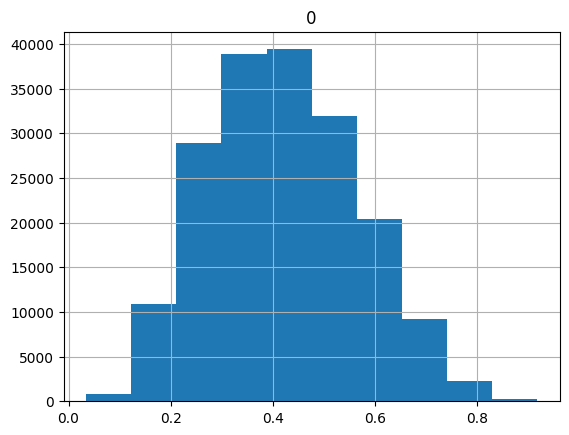

In [60]:
pd.DataFrame(test_y_predicted).hist()

In [61]:
test_X_transformed = pd.read_csv('x.csv')

In [62]:
test_X_transformed

,state_name,previous_classification_NOT INTERESTED,previous_classification_NEW CLIENT,previous_classification_NOT EFFECTIVE,previous_calls,client_age,network_age_years,banking,arpu_90_days,minutes_in,...,start_using_months,contacts,high_frequency_contacts,plan_postpaid,sn_banking,digital_index_mean,connected_days,charged_days,apps_days,music_gb
0,0.044849,0,1,0,-1.146922,-1.140077,0.427976,1,1.838011,-0.171302,...,-0.799323,-1.831224,0.802538,1.869874,2.330070,0.00,0.744967,1.072482,-1.027077,5.946
1,0.041623,1,0,0,0.756483,0.308427,1.637797,1,-0.561327,-0.762694,...,0.568708,1.135284,-0.851165,0.529697,0.006457,0.00,0.744967,0.175880,1.128329,0.298
2,0.046469,0,1,0,-1.146922,-0.103057,0.140977,1,-0.412820,-1.738731,...,-1.567259,0.110627,0.410817,0.638714,-0.093603,0.00,0.744967,1.072482,-1.027077,0.000
3,0.043204,0,0,1,0.141891,-0.103057,1.670731,1,-1.893458,1.061715,...,-0.571819,0.667419,-0.046990,0.079803,0.055556,0.00,-0.737149,-0.107908,-1.027077,0.000
4,0.029995,0,1,0,-1.146922,1.202347,1.472564,0,-1.107059,-1.502760,...,-0.094003,-0.933910,-1.270395,-1.414035,-0.409644,0.00,0.144077,-0.873712,1.284120,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183020,0.044849,0,1,0,-1.146922,0.061513,-1.152175,0,-0.658043,1.713591,...,-0.799323,-0.705530,0.104119,0.690421,-0.043258,0.00,-1.791097,-0.873712,-1.027077,0.036
183021,0.030993,0,1,0,-1.146922,-0.261387,-0.568686,1,0.678608,-1.025645,...,0.639315,-0.399276,-0.708361,-1.414035,-0.409644,0.00,-1.791097,-1.693656,0.703386,0.000
183022,0.041623,0,0,1,0.141891,1.261282,-0.529301,0,0.906997,1.850786,...,-0.799323,-0.189310,-0.121983,-0.604052,0.806423,0.38,0.144077,0.380365,0.434698,0.000
183023,0.041623,1,0,0,1.410797,-0.021329,-0.149853,1,1.044076,-0.116825,...,0.236667,1.044409,-0.344707,-0.922378,-0.409644,0.65,0.429003,-0.282486,1.395348,0.000


In [63]:
threshold_metrics = threshold_iter(test_y, test_y_predicted, min=0, max=1, step=0.05)
threshold_metrics_df = pd.DataFrame(threshold_metrics)
threshold_metrics_df

,threshold,positive_prediction,precision,recall,f1,support,tn,fp,fn,tp
0,0.00,1.000000,0.037798,1.000000,0.072843,None,0,176107,0,6918
1,0.05,0.999956,0.037800,1.000000,0.072846,None,8,176099,0,6918
2,0.10,0.998284,0.037847,0.999566,0.072932,None,311,175796,3,6915
3,0.15,0.987177,0.038189,0.997398,0.073562,None,2329,173778,18,6900
4,0.20,0.949275,0.039317,0.987424,0.075623,None,9197,166910,87,6831
5,0.25,0.877077,0.041389,0.960393,0.079357,None,22224,153883,274,6644
6,0.30,0.776555,0.044530,0.914860,0.084926,None,40307,135800,589,6329
7,0.35,0.660374,0.048600,0.849089,0.091937,None,61116,114991,1044,5874
8,0.40,0.535140,0.053561,0.758312,0.100055,None,83409,92698,1672,5246
9,0.45,0.411512,0.059575,0.648598,0.109126,None,105277,70830,2431,4487


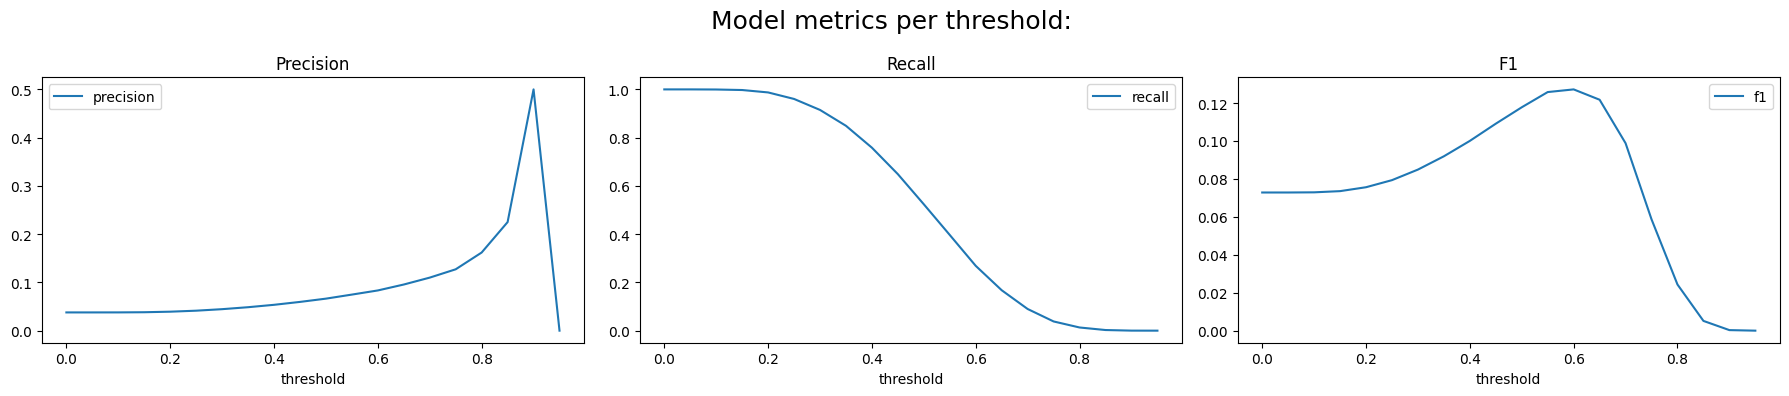

In [64]:
plot_threshold_metrics(threshold_metrics_df)

### Vector support machine

In [65]:
catboost_model = CatBoostClassifier(
    iterations=800, learning_rate=0.05, depth=10,
    eval_metric='AUC', loss_function='Logloss',
    # class_weigroc_auchts=[1, 3],  # ajusta si hay desbalance
    verbose=100, thread_count=-1
)
# model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=50)




scores_catboost = cross_validate(catboost_model, train_X_transformed, train_y_resampled, cv=cv, 
                            scoring=('precision', 'roc_auc', 'f1'), return_train_score=True, n_jobs=-1
                            )

0:	total: 167ms	remaining: 2m 13s
0:	total: 167ms	remaining: 2m 13s
0:	total: 186ms	remaining: 2m 28s
0:	total: 190ms	remaining: 2m 31s
0:	total: 190ms	remaining: 2m 31s
0:	total: 193ms	remaining: 2m 34s
0:	total: 195ms	remaining: 2m 35s
0:	total: 213ms	remaining: 2m 50s
100:	total: 5.62s	remaining: 38.9s
100:	total: 5.82s	remaining: 40.3s
100:	total: 5.82s	remaining: 40.3s
100:	total: 5.83s	remaining: 40.3s
100:	total: 5.91s	remaining: 40.9s
100:	total: 5.93s	remaining: 41s
100:	total: 5.92s	remaining: 41s
100:	total: 6.03s	remaining: 41.8s
200:	total: 11.4s	remaining: 34.1s
200:	total: 11.5s	remaining: 34.2s
200:	total: 13s	remaining: 38.6s
200:	total: 13.1s	remaining: 39s
200:	total: 13.2s	remaining: 39.5s
200:	total: 13.5s	remaining: 40.1s
200:	total: 13.5s	remaining: 40.3s
200:	total: 13.6s	remaining: 40.5s
300:	total: 15.5s	remaining: 25.7s
300:	total: 15.8s	remaining: 26.1s
300:	total: 18.1s	remaining: 30s
300:	total: 18.8s	remaining: 31.2s
300:	total: 18.8s	remaining: 31.2s
300

In [66]:
scores_catboost

{'fit_time': array([43.33021283, 49.52072191, 49.05829501, 44.24723291, 46.36609077,
        47.13331819, 47.72390199, 47.47105694, 19.45905805, 17.80751395]),
 'score_time': array([0.03515124, 0.03368497, 0.05667591, 0.26062799, 0.09285498,
        0.08699179, 0.0503509 , 0.0647459 , 0.012604  , 0.01554894]),
 'test_precision': array([0.59357143, 0.59845288, 0.57619739, 0.58362248, 0.58762887,
        0.59508315, 0.57811425, 0.59106769, 0.5981703 , 0.59815734]),
 'train_precision': array([0.98024567, 0.976106  , 0.97741258, 0.97619048, 0.97798152,
        0.9768415 , 0.97814484, 0.97850941, 0.97762977, 0.97922398]),
 'test_roc_auc': array([0.64700072, 0.66045121, 0.63761221, 0.65107498, 0.65418875,
        0.65319866, 0.63761261, 0.65492581, 0.66178733, 0.65670586]),
 'train_roc_auc': array([0.9961914 , 0.99473022, 0.99479573, 0.99465764, 0.99557276,
        0.99521297, 0.99576858, 0.99544449, 0.99512259, 0.99561961]),
 'test_f1': array([0.55473965, 0.56394964, 0.5341406 , 0.55401845,

In [67]:
print(f"precision-avg:{scores_catboost['test_precision'].mean()} \n roc_auc-avg: {scores_catboost['test_roc_auc'].mean()} \n f1_avg: {scores_catboost['test_f1'].mean()}" )


precision-avg:0.5900065776659023 
 roc_auc-avg: 0.6514558144327668 
 f1_avg: 0.5554946009713851


In [68]:
print(train_X_transformed.shape)
print(len(train_y_resampled))


(34732, 22)
34732


## Model Train

In [69]:

try:
    import scipy.sparse as sp
    X_IS_SPARSE = sp.issparse(train_X_transformed)
except Exception:
    X_IS_SPARSE = False

def _ensure_dense_transformer():
    return FunctionTransformer(
        lambda arr: arr.toarray() if hasattr(arr, "toarray") else arr,
        accept_sparse=True
    )

def _auc_safe(y_true, proba_or_scores):
    try:
        if proba_or_scores.ndim == 1:
            return roc_auc_score(y_true, proba_or_scores)
        else:
            return roc_auc_score(y_true, proba_or_scores, multi_class="ovr")
    except Exception:
        return np.nan

def _pipeline_ready(name, est):
    """Densifica solo para modelos que no aceptan sparse (p. ej., GaussianNB)."""
    needs_dense = name in {"GaussianNB", "CatBoost"}
    if needs_dense and X_IS_SPARSE:
        return make_pipeline(_ensure_dense_transformer(), est)
    return est

def _plot_cm(cm, labels, title, normalize=False):
    import matplotlib.pyplot as plt
    if normalize:
        cm_ = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-12)
    else:
        cm_ = cm
    plt.figure()
    plt.imshow(cm_, interpolation="nearest")
    plt.title(title); plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45); plt.yticks(ticks, labels)
    fmt = ".2f" if normalize else "d"
    for i in range(cm_.shape[0]):
        for j in range(cm_.shape[1]):
            plt.text(j, i, format(cm_[i, j], fmt), ha="center", va="center")
    plt.ylabel("True"); plt.xlabel("Pred"); plt.tight_layout(); plt.show()

# ---------- Expansor de grids ----------
def _expand_specs(model_specs):
    """
    model_specs: lista de dicts con las llaves:
      - name (str): nombre base del modelo
      - estimator (obj): instancia sklearn-like
      - param_grid (dict opcional): {hiper: [vals,...]}
      - params (dict opcional): parámetros fijos (set_params)
    Retorna lista de (name_final, estimator_clonado_y_parametrizado).
    """
    expanded = []
    for spec in model_specs:
        base_name = spec["name"]
        base_est  = deepcopy(spec["estimator"])
        fixed     = spec.get("params", {}) or {}
        grid      = spec.get("param_grid", None)

        if grid:
            keys = list(grid.keys())
            for combo in product(*[grid[k] for k in keys]):
                est = deepcopy(base_est)
                # aplica fijos y del grid
                est.set_params(**fixed)
                est.set_params(**{k: v for k, v in zip(keys, combo)})
                suffix = ", ".join([f"{k}={v}" for k, v in zip(keys, combo)])
                expanded.append((f"{base_name} [{suffix}]", est))
        else:
            est = deepcopy(base_est)
            est.set_params(**fixed)
            expanded.append((base_name, est))
    return expanded

# ---------- Benchmark principal ----------
def run_benchmark(
    X, y, cv, model_specs,
    score_tuple=("precision", "recall", "f1", "roc_auc"),
    plot_cm=True, normalize_cm=False,
    save_prefix=None  # si no es None, guarda CSV con resultados
):
    """
    Ejecuta CV homogénea (misma data/splits/métricas) sobre múltiples modelos
    y múltiples configuraciones (param_grid), calcula AUC OOF y matrices de confusión OOF.
    - X, y: (usa tus train_X_transformed, train_y_resampled)
    - cv: tu StratifiedKFold ya definido
    - model_specs: lista de dicts (ver _expand_specs)
    - plot_cm: bool para mostrar CM OOF por config
    - normalize_cm: bool para CM normalizada
    - save_prefix: si se define, guarda resultados en '{save_prefix}_scores.csv'
    Retorna: (df_scores, oof_store)
        df_scores: tabla ordenada por roc_auc_mean
        oof_store: dict con OOF preds/probas por config para análisis extra
    """
    configs = _expand_specs(model_specs)
    labels_ = np.unique(y)
    results = []
    oof_store = {}  # {config_name: {"ypred":..., "yproba":..., "cm":...}}

    for conf_name, est in configs:
        est_use = _pipeline_ready(conf_name.split()[0], est)

        # CV métricas
        scores = cross_validate(
            est_use, X, y, cv=cv,
            scoring=score_tuple, return_train_score=False, n_jobs=-1
        )

        # OOF probas / decision_function → AUC global OOF
        auc_oof, yproba_oof = np.nan, None
        try:
            yproba_oof = cross_val_predict(est_use, X, y, cv=cv, n_jobs=-1, method="predict_proba")
            auc_oof = _auc_safe(y, yproba_oof[:,1] if yproba_oof.shape[1]==2 else yproba_oof)
        except Exception:
            try:
                scores_dec = cross_val_predict(est_use, X, y, cv=cv, n_jobs=-1, method="decision_function")
                if scores_dec.ndim == 1:
                    s = (scores_dec - scores_dec.min()) / (scores_dec.max() - scores_dec.min() + 1e-12)
                    yproba_oof = s
                    auc_oof = _auc_safe(y, s)
                else:
                    exps = np.exp(scores_dec - scores_dec.max(axis=1, keepdims=True))
                    probs = exps / (exps.sum(axis=1, keepdims=True) + 1e-12)
                    yproba_oof = probs
                    auc_oof = _auc_safe(y, probs)
            except Exception:
                pass

        # OOF predicciones de clase → CM
        ypred_oof = cross_val_predict(est_use, X, y, cv=cv, n_jobs=-1, method="predict")
        cm = confusion_matrix(y, ypred_oof, labels=labels_)
        if plot_cm:
            _plot_cm(cm, [str(c) for c in labels_], f"CM OOF - {conf_name}", normalize=normalize_cm)

        # Guarda OOF
        oof_store[conf_name] = {"ypred": ypred_oof, "yproba": yproba_oof, "cm": cm}

        # Agrega fila de resultados
        row = {"config": conf_name}
        for sc in score_tuple:
            row[f"{sc}_mean"] = float(np.mean(scores[f"test_{sc}"]))
            row[f"{sc}_std"]  = float(np.std(scores[f"test_{sc}"]))
        row["roc_auc_oof"] = float(auc_oof) if not np.isnan(auc_oof) else np.nan
        results.append(row)

    df_scores = pd.DataFrame(results).sort_values(by="roc_auc_mean", ascending=False).reset_index(drop=True)
    display(df_scores)

    if save_prefix:
        df_scores.to_csv(f"{save_prefix}_scores.csv", index=False)

    return df_scores, oof_store

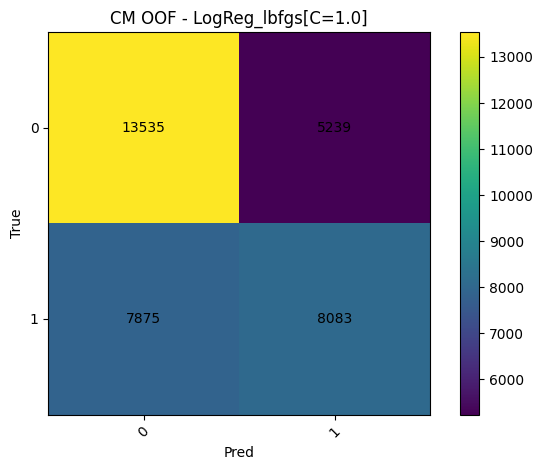

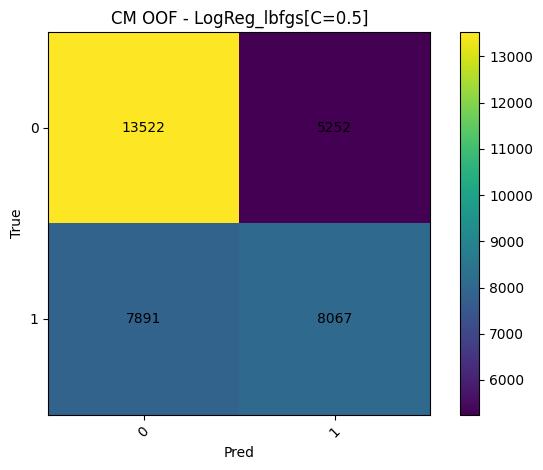

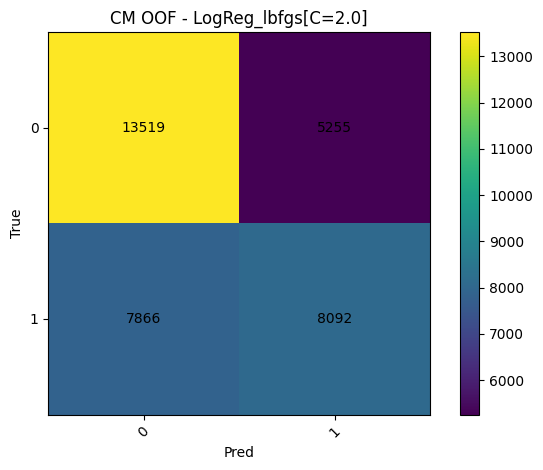

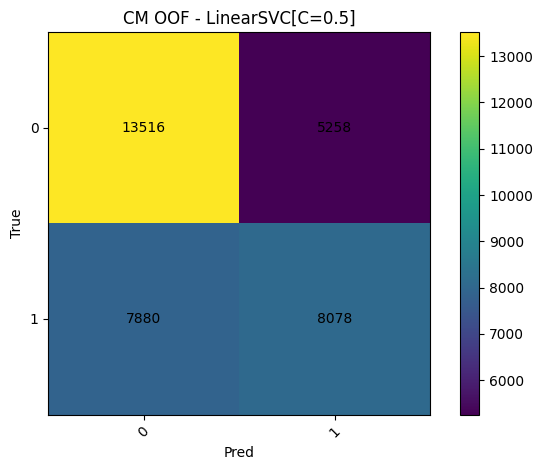

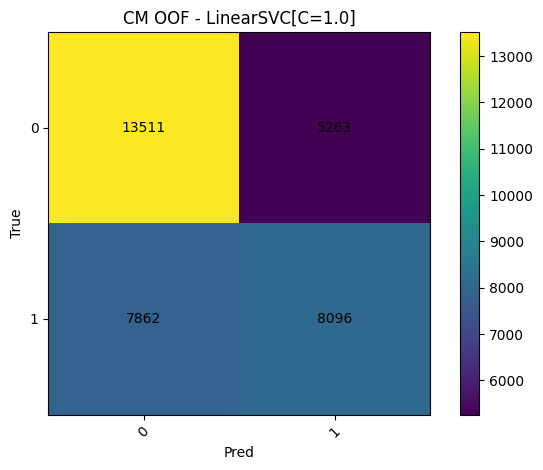

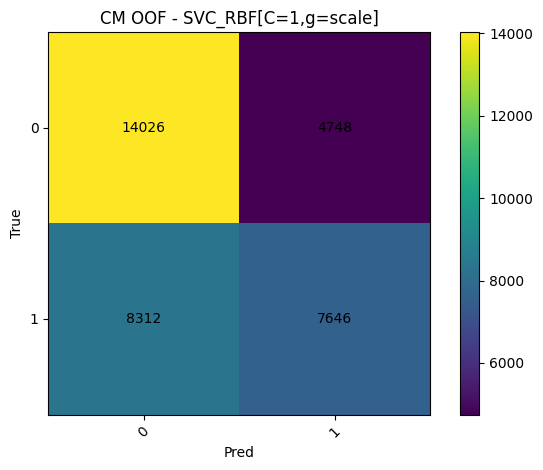

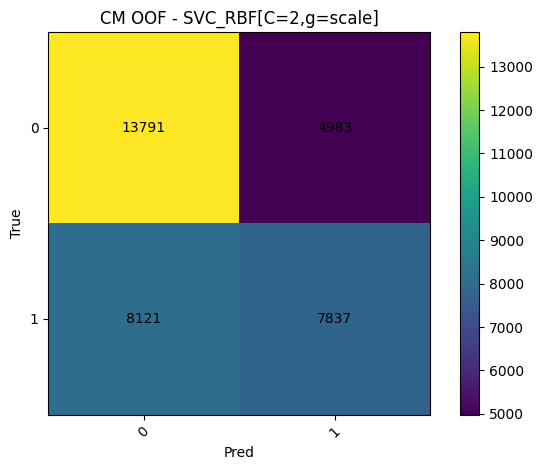

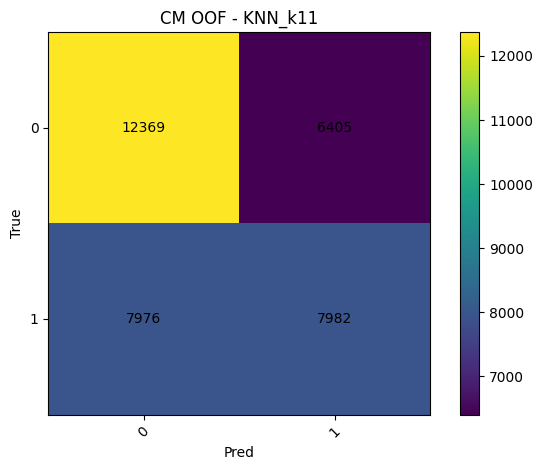

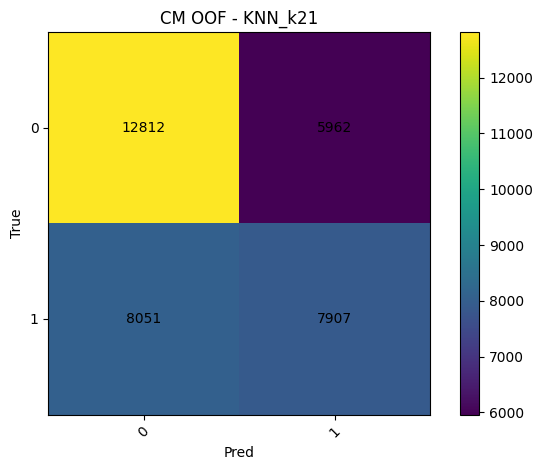

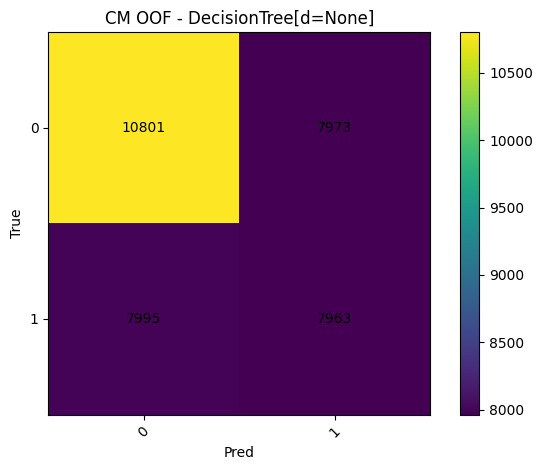

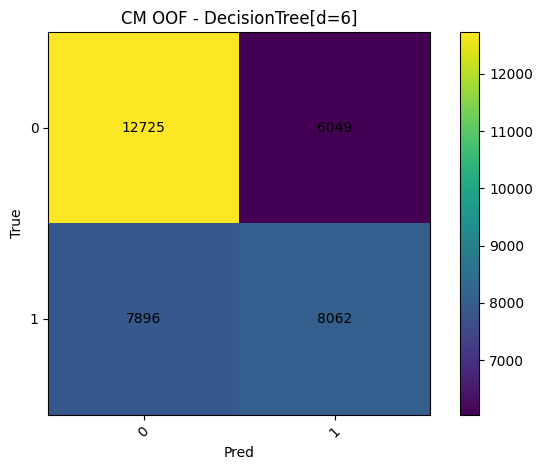

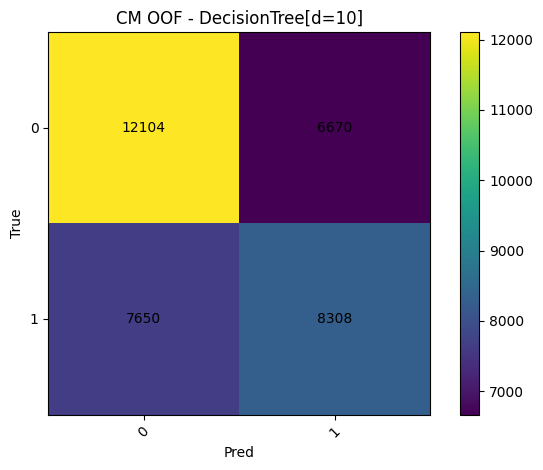

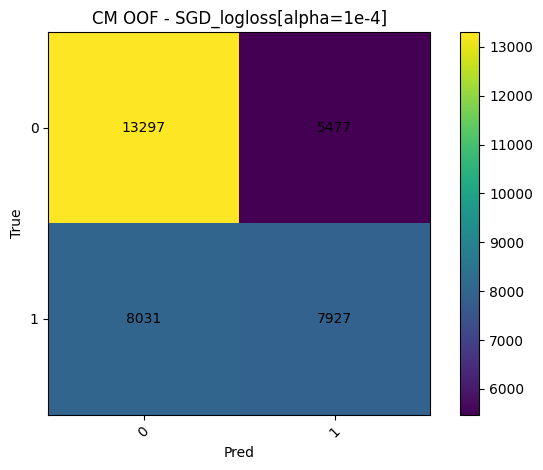

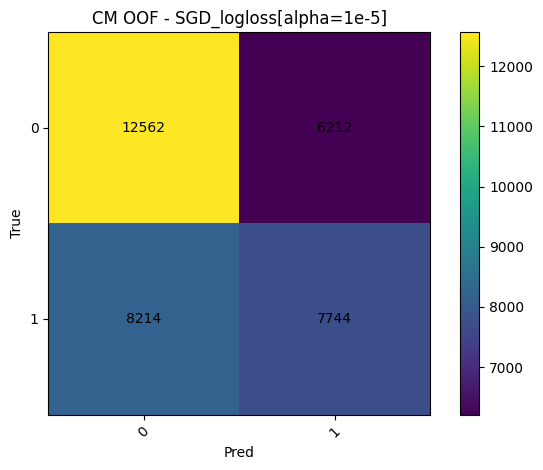

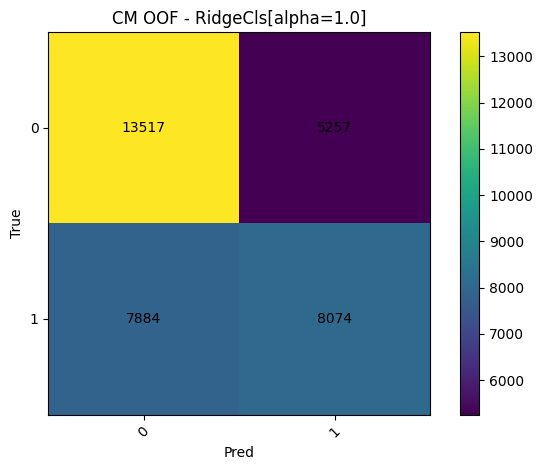

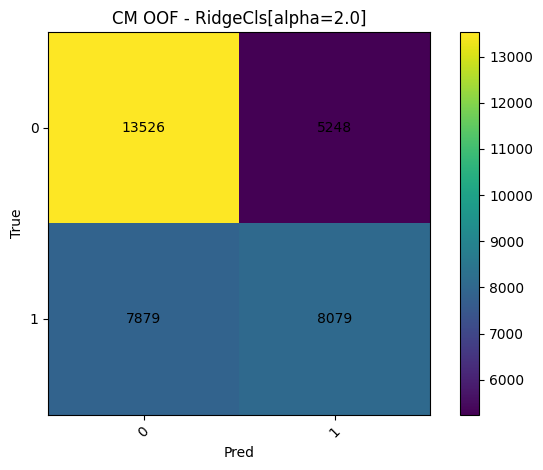

,config,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,roc_auc_oof
0,LinearSVC[C=1.0],0.606115,0.007921,0.507332,0.006837,0.552302,0.005701,0.663160,0.007557,0.663107
1,LinearSVC[C=0.5],0.605767,0.006815,0.506204,0.007388,0.551498,0.006058,0.662880,0.007698,0.662836
2,RidgeCls[alpha=1.0],0.605697,0.006980,0.505953,0.007336,0.551320,0.006078,0.662845,0.007716,0.662802
3,LogReg_lbfgs[C=2.0],0.606303,0.007577,0.507081,0.009649,0.552231,0.007768,0.662464,0.007841,0.662416
4,RidgeCls[alpha=2.0],0.606260,0.007625,0.506266,0.008617,0.551729,0.006952,0.662424,0.007838,0.662381
5,LogReg_lbfgs[C=1.0],0.606770,0.007249,0.506517,0.009670,0.552085,0.007512,0.662047,0.007908,0.661991
6,LogReg_lbfgs[C=0.5],0.605715,0.007515,0.505514,0.008881,0.551058,0.007149,0.661724,0.007954,0.661657
7,"SVC_RBF[C=1,g=scale]",0.616961,0.006419,0.479132,0.006260,0.539351,0.005023,0.661432,0.005106,0.661300
8,"SVC_RBF[C=2,g=scale]",0.611368,0.007501,0.491101,0.007952,0.544634,0.006346,0.656716,0.004545,0.656607
9,SGD_logloss[alpha=1e-4],0.592448,0.015562,0.496749,0.060764,0.537958,0.035076,0.646876,0.014693,0.646222


,config,roc_auc_mean,f1_mean,precision_mean,recall_mean
0,LinearSVC[C=1.0],0.66316,0.552302,0.606115,0.507332
1,LinearSVC[C=0.5],0.66288,0.551498,0.605767,0.506204


In [70]:
individual_specs = [
    # LogisticRegression: prueba regularización
    {"name":"LogReg_lbfgs[C=1.0]", "estimator": LogisticRegression(max_iter=2000, solver="lbfgs", C=1.0)},
    {"name":"LogReg_lbfgs[C=0.5]", "estimator": LogisticRegression(max_iter=2000, solver="lbfgs", C=0.5)},
    {"name":"LogReg_lbfgs[C=2.0]", "estimator": LogisticRegression(max_iter=2000, solver="lbfgs", C=2.0)},

    # LinearSVC/SVC: margen y kernel
    {"name":"LinearSVC[C=0.5]", "estimator": LinearSVC(C=0.5, random_state=42)},
    {"name":"LinearSVC[C=1.0]", "estimator": LinearSVC(C=1.0, random_state=42)},
    {"name":"SVC_RBF[C=1,g=scale]", "estimator": SVC(kernel="rbf", probability=True, C=1.0, gamma="scale", random_state=42)},
    {"name":"SVC_RBF[C=2,g=scale]", "estimator": SVC(kernel="rbf", probability=True, C=2.0, gamma="scale", random_state=42)},

    # KNN: sensibilidad a k
    {"name":"KNN_k11", "estimator": KNeighborsClassifier(n_neighbors=11)},
    {"name":"KNN_k21", "estimator": KNeighborsClassifier(n_neighbors=21)},

    # GaussianNB (sin hiperparams clave)

    # DecisionTree: controlar profundidad y splitting
    {"name":"DecisionTree[d=None]", "estimator": DecisionTreeClassifier(max_depth=None, random_state=42)},
    {"name":"DecisionTree[d=6]", "estimator": DecisionTreeClassifier(max_depth=6, random_state=42)},
    {"name":"DecisionTree[d=10]", "estimator": DecisionTreeClassifier(max_depth=10, random_state=42)},

    # SGD (logistic): regularización
    {"name":"SGD_logloss[alpha=1e-4]", "estimator": SGDClassifier(loss="log_loss", alpha=1e-4, max_iter=2000, random_state=42)},
    {"name":"SGD_logloss[alpha=1e-5]", "estimator": SGDClassifier(loss="log_loss", alpha=1e-5, max_iter=2000, random_state=42)},

    # RidgeClassifier: fortaleza de L2
    {"name":"RidgeCls[alpha=1.0]", "estimator": RidgeClassifier(alpha=1.0)},
    {"name":"RidgeCls[alpha=2.0]", "estimator": RidgeClassifier(alpha=2.0)},
]


df_indiv, oof_indiv = run_benchmark(
    X=train_X_transformed, y=train_y_resampled, cv=cv,
    model_specs=individual_specs,
    score_tuple=("precision","recall","f1","roc_auc"),
    plot_cm=True, normalize_cm=False,
    save_prefix="individuals_benchmark"
)

# Selección TOP-2 individuales (por AUC; cambia a 'f1_mean' si lo prefieres)
top2_indiv = df_indiv.head(2)[["config","roc_auc_mean","f1_mean","precision_mean","recall_mean"]]
display(top2_indiv)

# Final Model

In [75]:
# Renombra para el flujo de ensambles
df_scores = df_indiv
# ===== Utilidades ya probadas / necesarias =====
def _uniqueize_estimators(pairs):
    seen, out = {}, []
    for n, est in pairs:
        seen[n] = seen.get(n, 0) + 1
        out.append((n if seen[n] == 1 else f"{n}_{seen[n]}", est))
    return out

def _ensure_proba(clf):
    return clf if hasattr(clf, "predict_proba") else CalibratedClassifierCV(clf, method="sigmoid", cv=3)

# Parseo de tus strings "config" -> (familia, params)
import re
def _parse_config(cfg: str):
    if "KNN_k" in cfg:
        return "KNN", {"k": int(cfg.split("KNN_k")[-1])}
    m = re.match(r"([A-Za-z_]+)\[(.+)\]", cfg)
    if not m:
        return cfg, {}
    base, params_raw = m.group(1), m.group(2)
    params = {}
    for kv in params_raw.split(","):
        if "=" in kv:
            k, v = kv.split("="); k, v = k.strip(), v.strip()
            if v.lower() == "none":
                params[k] = None
            else:
                try:
                    params[k] = float(v) if any(t in v for t in [".","e"]) else int(v)
                except Exception:
                    params[k] = v
    return base, params

# Reconstrucción del estimador desde df_scores['config'] + calibración si hace falta
def _from_config_to_estimator(cfg: str):
    base, p = _parse_config(cfg)
    if base == "LinearSVC":
        est = LinearSVC(C=p.get("C", 1.0), random_state=42)
        est = CalibratedClassifierCV(est, method="sigmoid", cv=3)
    elif base in ("LogReg_lbfgs","LogReg"):
        est = LogisticRegression(C=p.get("C", 1.0), solver="lbfgs", max_iter=2000, random_state=42)
    elif base == "RidgeCls":
        est = RidgeClassifier(alpha=p.get("alpha", 1.0), random_state=42)
        est = CalibratedClassifierCV(est, method="sigmoid", cv=3)
    elif base == "SGD_logloss":
        est = SGDClassifier(loss="log_loss", alpha=p.get("alpha", 1e-4), max_iter=2000, random_state=42)
        est = CalibratedClassifierCV(est, method="sigmoid", cv=3)
    elif base == "SVC_RBF":
        est = SVC(C=p.get("C", 1.0), gamma=p.get("g", "scale"), kernel="rbf", probability=True, random_state=42)
    elif base == "DecisionTree":
        est = DecisionTreeClassifier(max_depth=p.get("d", None), random_state=42)
    elif base == "KNN":
        est = KNeighborsClassifier(n_neighbors=p.get("k", 15))
    elif base == "GaussianNB":
        est = GaussianNB()
    elif base == "XGB":
        est = XGBClassifier(
            n_estimators=int(p.get("n_estimators", 300)),
            max_depth=int(p.get("max_depth", 6)),
            learning_rate=float(p.get("learning_rate", 0.1)),
            subsample=float(p.get("subsample", 1.0)),
            colsample_bytree=float(p.get("colsample_bytree", 1.0)),
            eval_metric="logloss", tree_method="hist", n_jobs=-1, random_state=42,
        )
    elif base == "CatBoost":
        est = CatBoostClassifier(
            iterations=int(p.get("iterations", 600)),
            depth=int(p.get("depth", 6)),
            learning_rate=float(p.get("learning_rate", 0.1)),
            l2_leaf_reg=float(p.get("l2_leaf_reg", 3)),
            loss_function="Logloss", verbose=False, random_state=42,
        )
    else:
        raise ValueError(f"Config no soportada: {cfg}")
    # densificar si toca (ya definiste _pipeline_ready)
    return _pipeline_ready(base, est) if "_pipeline_ready" in globals() else est

# Top-K desde tu ranking (evita duplicados por familia para diversidad)
def build_base_estimators_from_rank(df_scores: pd.DataFrame, top_k: int = 7, unique_by_family: bool = True):
    req = {"config","roc_auc_mean"}
    if not req.issubset(df_scores.columns):
        raise ValueError("df_scores debe contener 'config' y 'roc_auc_mean'.")
    selected, family_counts = [], {}
    for _, row in df_scores.sort_values("roc_auc_mean", ascending=False).iterrows():
        cfg = row["config"]; base, _ = _parse_config(cfg)
        if unique_by_family and base in family_counts: 
            continue
        est = _ensure_proba(_from_config_to_estimator(cfg))
        family_counts[base] = family_counts.get(base, 0) + 1
        suf = "" if family_counts[base]==1 else f"_{family_counts[base]}"
        selected.append((f"{base}{suf}", est))
        if len(selected) >= top_k: break
    if len(selected) < top_k:
        print(f"[Aviso] solo {len(selected)} modelos únicos para el ensamble (revisa df_scores).")
    return selected

# O fuerza la lista base: XGB + CatBoost + 5 diversos (por si no salieron en tu df_scores)
def forced_base_estimators():
    pairs = [
        ("LogReg", LogisticRegression(max_iter=2000, solver="lbfgs", C=1.0, random_state=42)),
        ("LinearSVC", CalibratedClassifierCV(LinearSVC(C=1.0, random_state=42), method="sigmoid", cv=3)),
        ("SVC_RBF", SVC(kernel="rbf", probability=True, C=1.0, gamma="scale", random_state=42)),
        ("KNN", KNeighborsClassifier(n_neighbors=15)),
        ("DecisionTree", DecisionTreeClassifier(max_depth=6, random_state=42)),
        ("XGB", XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1, subsample=0.8,
                              colsample_bytree=0.8, eval_metric="logloss", tree_method="hist", n_jobs=-1, random_state=42)),
        ("CatBoost", CatBoostClassifier(iterations=600, depth=6, learning_rate=0.1, l2_leaf_reg=3,
                                        loss_function="Logloss", verbose=False, random_state=42)),
    ]
    # densificar si hace falta + asegurar probas
    out = []
    for n, est in pairs:
        est2 = _pipeline_ready(n, est) if "_pipeline_ready" in globals() else est
        out.append((n, _ensure_proba(est2)))
    return _uniqueize_estimators(out)

# Grid de ensambles (Voting soft con pesos + Stacking LR)
PRIMARY_METRIC = "roc_auc"; CV_FOLDS = 5; N_JOBS = -1
def grid_ensembles(base_estimators, X, y, preprocessor='passthrough'):
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
    results = {}
    base_estimators = _uniqueize_estimators(base_estimators)

    # Voting
    k = len(base_estimators)
    weight_sets = [[1]*k] + [[2 if i==j else 1 for j in range(k)] for i in range(k)]
    voting = VotingClassifier(estimators=base_estimators, voting="soft", n_jobs=N_JOBS)
    pipe_v = Pipeline([("prep", preprocessor), ("clf", voting)])
    param_v = {"clf__weights": [None] + weight_sets}
    gs_v = GridSearchCV(
        pipe_v, param_grid=param_v,
        scoring={"roc_auc":"roc_auc","f1":"f1","precision":"precision","recall":"recall","ap":"average_precision"},
        refit=PRIMARY_METRIC, cv=cv, n_jobs=N_JOBS, verbose=0, return_train_score=False
    )
    t0 = time.time(); gs_v.fit(X, y); gs_v.wall_time_ = round(time.time()-t0, 2)
    results["VotingSoft"] = gs_v

    # Stacking
    stacking = StackingClassifier(
        estimators=base_estimators,
        final_estimator=LogisticRegression(max_iter=2000, random_state=42),
        passthrough=False, n_jobs=N_JOBS
    )
    pipe_s = Pipeline([("prep", preprocessor), ("clf", stacking)])
    param_s = {"clf__final_estimator__C": [0.5, 1.0, 2.0]}
    gs_s = GridSearchCV(
        pipe_s, param_grid=param_s,
        scoring={"roc_auc":"roc_auc","f1":"f1","precision":"precision","recall":"recall","ap":"average_precision"},
        refit=PRIMARY_METRIC, cv=cv, n_jobs=N_JOBS, verbose=0, return_train_score=False
    )
    t0 = time.time(); gs_s.fit(X, y); gs_s.wall_time_ = round(time.time()-t0, 2)
    results["StackingLR"] = gs_s

    return results

def summarize_ensemble_grids(gs_dict: dict) -> pd.DataFrame:
    rows = []
    for name, gs in gs_dict.items():
        bi = gs.best_index_
        rows.append({
            "model": name, "primary_metric": PRIMARY_METRIC,
            "best_score": float(gs.best_score_),
            "f1": float(gs.cv_results_["mean_test_f1"][bi]),
            "precision": float(gs.cv_results_["mean_test_precision"][bi]),
            "recall": float(gs.cv_results_["mean_test_recall"][bi]),
            "ap": float(gs.cv_results_["mean_test_ap"][bi]),
            "mean_fit_time_cv": float(np.mean(gs.cv_results_["mean_fit_time"])),
            "wall_fit_time_sec": getattr(gs, "wall_time_", np.nan),
            "best_params": gs.best_params_,
        })
    return pd.DataFrame(rows).sort_values("best_score", ascending=False, ignore_index=True)

# ===== Gráficas OOF (sin X_test) =====
def _oof_proba(estimator, X, y):
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
    try:
        return cross_val_predict(estimator, X, y, cv=cv, n_jobs=-1, method="predict_proba")[:,1]
    except Exception:
        scores = cross_val_predict(estimator, X, y, cv=cv, n_jobs=-1, method="decision_function")
        smin, smax = scores.min(), scores.max()
        return (scores - smin) / (smax - smin + 1e-12)

def plot_ensemble_oof_all(estimator, X, y, threshold=0.5):
    proba = _oof_proba(estimator, X, y)
    # ROC
    fpr, tpr, _ = roc_curve(y, proba); 
    plt.figure(figsize=(5,4)); plt.plot(fpr,tpr,lw=2); plt.plot([0,1],[0,1],'--'); 
    plt.title("ROC (OOF)"); plt.tight_layout(); plt.show()
    # PR
    pr, rc, _ = precision_recall_curve(y, proba);
    plt.figure(figsize=(5,4)); plt.plot(rc, pr, lw=2); plt.title("Precision–Recall (OOF)"); plt.tight_layout(); plt.show()
    # CM
    y_pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y, y_pred)
    _plot_cm(cm, labels=[str(c) for c in np.unique(y)], title=f"CM OOF @ {threshold:.2f}", normalize=False)
    # Residuos
    resid = y.astype(float) - proba
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1); plt.hist(resid, bins=30, edgecolor="k"); plt.title("Residuos (OOF)")
    plt.subplot(1,2,2); plt.scatter(proba, resid, s=10, alpha=0.4); plt.axhline(0, color='k', ls='--'); plt.title("Residuos vs p̂ (OOF)")
    plt.tight_layout(); plt.show()

Modelos base del ensamble: ['LogReg', 'LinearSVC', 'SVC_RBF', 'KNN', 'DecisionTree', 'XGB', 'CatBoost']
| model      | primary_metric   |   best_score |       f1 |   precision |   recall |       ap |   mean_fit_time_cv |   wall_fit_time_sec | best_params                             |
|------------|------------------|--------------|----------|-------------|----------|----------|--------------------|---------------------|-----------------------------------------|
| StackingLR | roc_auc          |     0.669388 | 0.557617 |    0.609301 | 0.514037 | 0.616047 |            803.525 |             1903.26 | {'clf__final_estimator__C': 0.5}        |
| VotingSoft | roc_auc          |     0.668351 | 0.554745 |    0.608801 | 0.509525 | 0.614843 |            219.176 |             1513.18 | {'clf__weights': [1, 2, 1, 1, 1, 1, 1]} |

Modelo ensamblador campeón: StackingLR


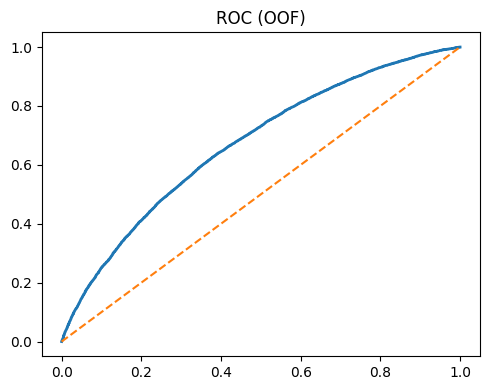

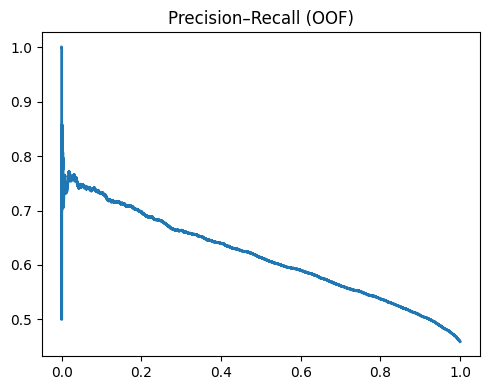

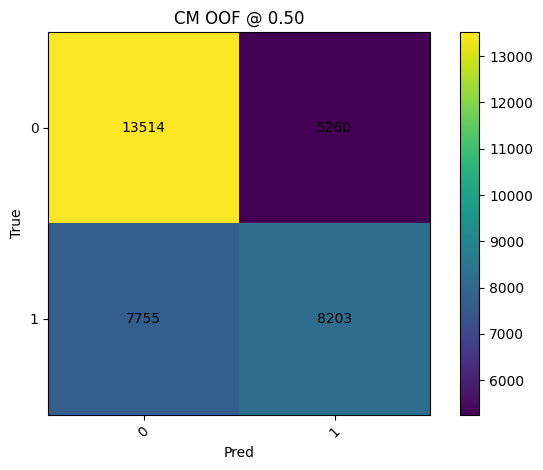

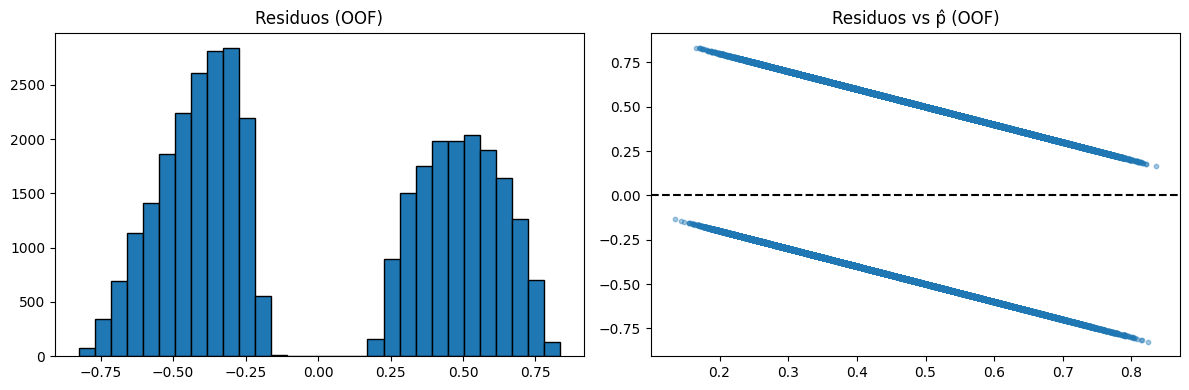

In [76]:
# ====== EJECUCIÓN ======
# 1) Base models para el ensamble:
USE_FORCED_BASE = True   # pon False si quieres tomar top-K de tu ranking df_scores
if USE_FORCED_BASE:
    base_estimators = forced_base_estimators()
else:
    base_estimators = build_base_estimators_from_rank(df_scores, top_k=7, unique_by_family=True)

print("Modelos base del ensamble:", [n for n,_ in base_estimators])

# 2) Preprocesador
preprocessor = preprocessor if 'preprocessor' in globals() else 'passthrough'

# 3) Grid de ensambles
gs_dict = grid_ensembles(base_estimators, train_X_transformed, train_y_resampled, preprocessor=preprocessor)
ens_df = summarize_ensemble_grids(gs_dict)
print(tabulate(ens_df, headers='keys', tablefmt='github', showindex=False))

# 4) Campeón y gráficas OOF
best_name = ens_df.iloc[0]["model"]
best_ens = gs_dict[best_name].best_estimator_
print(f"\nModelo ensamblador campeón: {best_name}")
plot_ensemble_oof_all(best_ens, train_X_transformed, train_y_resampled, threshold=0.5)

# Model Explainability

SHAP (SHapley Additive exPlanations) values are a method for interpreting machine learning model predictions. They quantify the contribution of each feature to the prediction for a specific sample, based on concepts from cooperative game theory.

- **Global Interpretability**: SHAP values can be aggregated across the dataset to show which features are most influential overall.
- **Local Interpretability**: For individual predictions, SHAP values explain how each feature impacted the model’s output.
- **Visualization**: Common plots include summary plots (showing feature importance and impact) and bar plots (ranking features by average absolute SHAP value).

In this notebook, SHAP values are computed for the test set using the trained model. The resulting plots help you understand which features drive predictions, supporting model transparency and trust.

In [ ]:
shap_values_sel_model = evaluate_shap_values(
    model=model,
    X_test=test_X_transformed.sample(5000),
    plot=False)

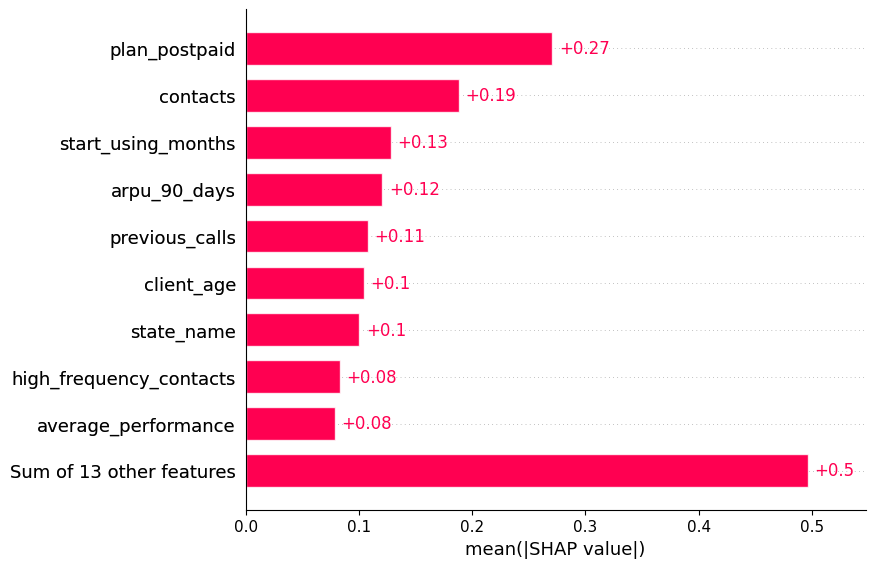

In [ ]:
shap.plots.bar(shap_values_sel_model)

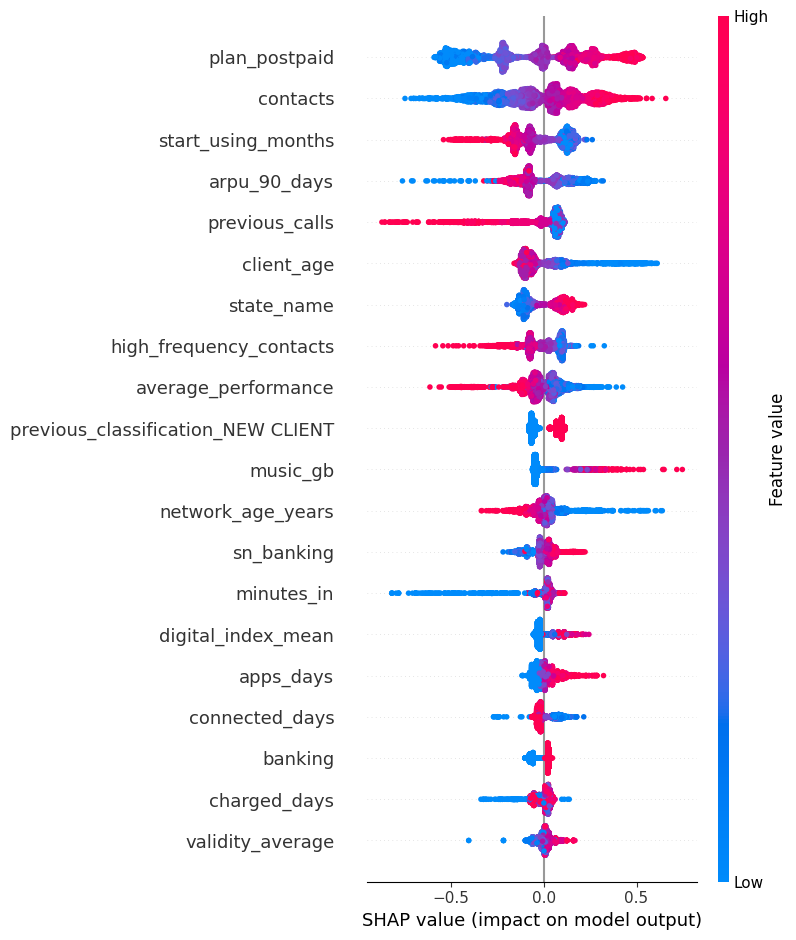

In [ ]:
shap.summary_plot(shap_values_sel_model)

Hay que considerar que nos interesa para obtener los shapley values:

	•	usar solo los ↑ para la versión de conversión,
	•	usar los ↓ para la versión de retención o reactivación,
	•	o combinar ambos para un speech personalizado completo. <-


In [ ]:
# === 1) Normalizador / formateo de SHAP ===
def top_shap(shap_dict, k=10):
    return sorted(shap_dict.items(), key=lambda kv: abs(kv[1]), reverse=True)[:k]

def shap_to_bullets(shap_dict, k=10):
    lines = []
    for feat, val in top_shap(shap_dict, k):
        direction = "↑" if val > 0 else "↓"
        lines.append(f"- {feat}: {val:.4f} {direction}")
    return "\n".join(lines)


In [ ]:
exp_1 = shap_values_sel_model[0]
shap_dict_1 = dict(zip(exp_1.feature_names, exp_1.values))
print(shap_to_bullets(shap_dict_1))

- contacts: 0.1788 ↑
- arpu_90_days: -0.1783 ↓
- plan_postpaid: 0.1320 ↑
- start_using_months: 0.1246 ↑
- state_name: 0.1071 ↑
- client_age: -0.1027 ↓
- high_frequency_contacts: 0.0945 ↑
- network_age_years: 0.0930 ↑
- apps_days: 0.0920 ↑
- previous_calls: 0.0917 ↑


Mapeo de las features como diccionaro para que el LLM interprete los shapley values de una manera alineada al negocio

In [ ]:
# === 2) Mapeo opcional de features a “insights” de negocio (ajústalo a tus columnas) ===
FEATURE_PLAYBOOK = {
    "state_name": "Customer’s geographic region (e.g., GUATEMALA) or state. Use it to mention local availability or coverage.",
    "previous_classification": "Previous commercial label (e.g., NEW_CLIENT, NOT_INTERESTED, NOT EFFECTIVE). Adjust tone accordingly: onboarding, retention, or reactivation.",
    "previous_calls": "Number of previous customer calls or interactions. High value may indicate interest or friction; tailor the speech based on SHAP direction.",
    "client_age": "Customer’s age in years. Avoid demographic bias; use only to adapt communication tone if needed.",
    "network_age_years": "Years since the customer joined the network or service. Longer tenure suggests loyalty but possible reactivation opportunity.",
    "banking": "Binary flag indicating if the customer uses banking services. If yes, highlight convenience and trust; if no, keep it neutral.",
    "arpu_90_days": "Average revenue per user in the last 90 days. High ARPU means active/high-value user; low ARPU suggests opportunity to upsell or re-engage.",
    "minutes_in": "Incoming call minutes in the last period. Reflects engagement in voice usage.",
    "validity_average": "Average number of valid or active days in the plan. High validity shows consistency; low validity may indicate sporadic usage.",
    "average_performance": "Average service quality or network performance score. Low values may cause dissatisfaction; reinforce reliability or improvement initiatives.",
    "start_using_months": "Months since the customer started using the service. Long-time users can be re-engaged with loyalty or renewal offers.",
    "contacts": "Total previous contacts with the company. If high and SHAP is negative, reduce friction and simplify processes.",
    "high_frequency_contacts": "High-frequency contact flag. Frequent contacts can indicate interest or unresolved issues; address accordingly.",
    "plan_postpaid": "Indicates if the customer has a postpaid plan (1=yes, 0=no). Postpaid customers value premium experience, stability, and reliability.",
    "sn_banking": "Social or banking affinity indicator (internal feature). Use only if relevant; avoid assumptions if unclear.",
    "digital_index_mean": "Average digital engagement score. High score: emphasize digital channels, app self-service, and convenience.",
    "connected_days": "Number of days the customer was connected during the observed period. High value: active user; low: re-engagement opportunity.",
    "charged_days": "Number of days with active balance or successful billing. Shows payment activity or regular top-ups.",
    "apps_days": "Days with app usage activity. Low value suggests promoting app benefits or features.",
    "music_gb": "Amount of mobile data (in GB) used for music streaming. Zero usage = opportunity for 'music without data' offer.",
    "sale": "Target label (1=sale, 0=no sale). Do not include in prompts or explanations to avoid data leakage.",
}

In [ ]:
def shap_to_insights(shap_dict, k=10):
    insights = []
    for feat, val in top_shap(shap_dict, k):
        base = FEATURE_PLAYBOOK.get(feat)
        if not base:
            # fallback genérico legible
            sign = "positivo" if val > 0 else "negativo"
            base = f"Contribuidor {sign} relevante en {feat}."
        insights.append({"feature": feat, "value": val, "insight": base})
    return insights

In [ ]:
for insight in shap_to_insights(shap_dict_1):
  print(insight)

{'feature': 'contacts', 'value': np.float32(0.17880231), 'insight': 'Total previous contacts with the company. If high and SHAP is negative, reduce friction and simplify processes.'}
{'feature': 'arpu_90_days', 'value': np.float32(-0.17825305), 'insight': 'Average revenue per user in the last 90 days. High ARPU means active/high-value user; low ARPU suggests opportunity to upsell or re-engage.'}
{'feature': 'plan_postpaid', 'value': np.float32(0.13199936), 'insight': 'Indicates if the customer has a postpaid plan (1=yes, 0=no). Postpaid customers value premium experience, stability, and reliability.'}
{'feature': 'start_using_months', 'value': np.float32(0.124571554), 'insight': 'Months since the customer started using the service. Long-time users can be re-engaged with loyalty or renewal offers.'}
{'feature': 'state_name', 'value': np.float32(0.107147165), 'insight': 'Customer’s geographic region (e.g., GUATEMALA) or state. Use it to mention local availability or coverage.'}
{'feature

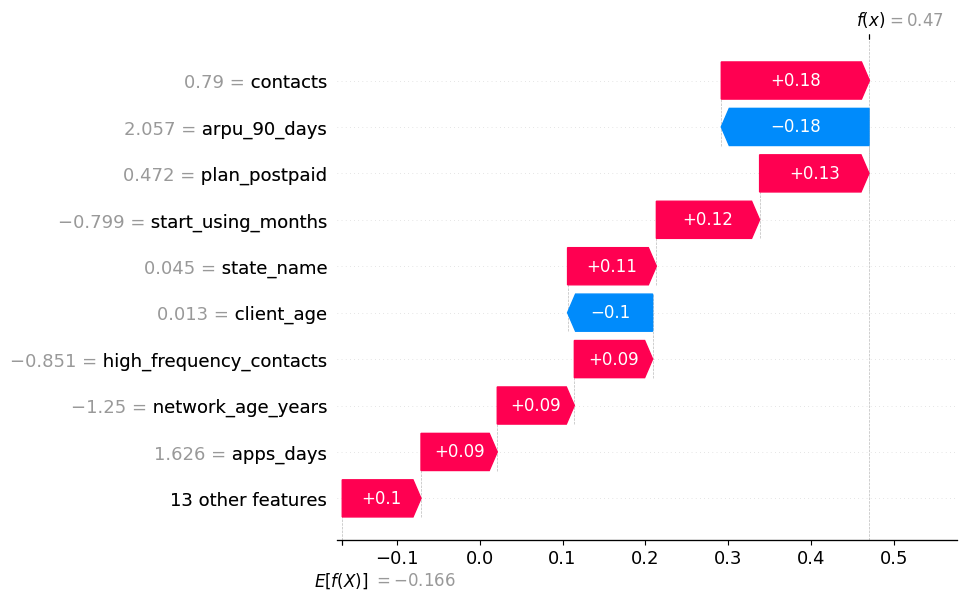

In [ ]:
shap.plots.waterfall(shap_values_sel_model[0])

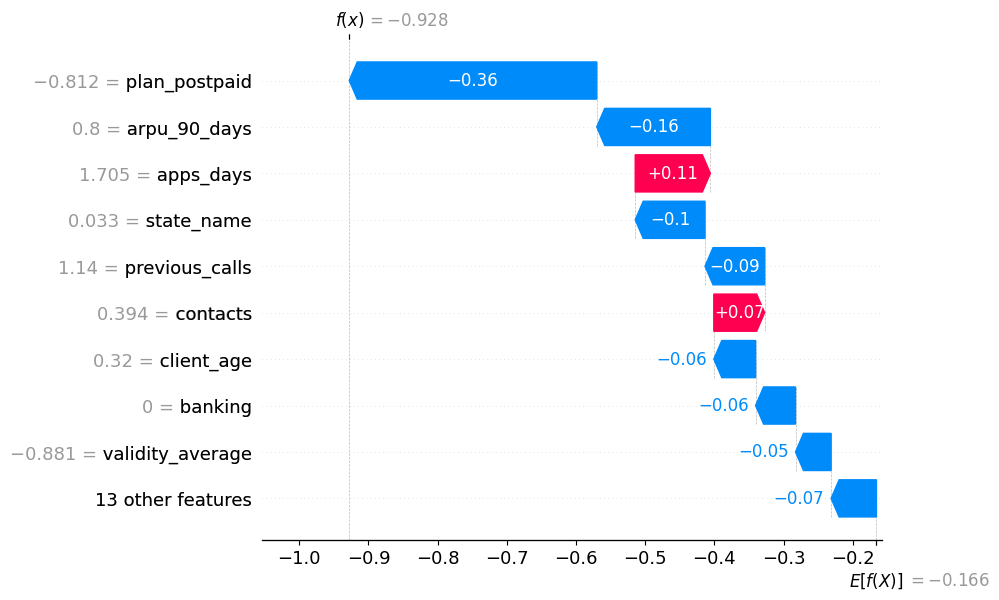

In [ ]:
shap.plots.waterfall(shap_values_sel_model[1])

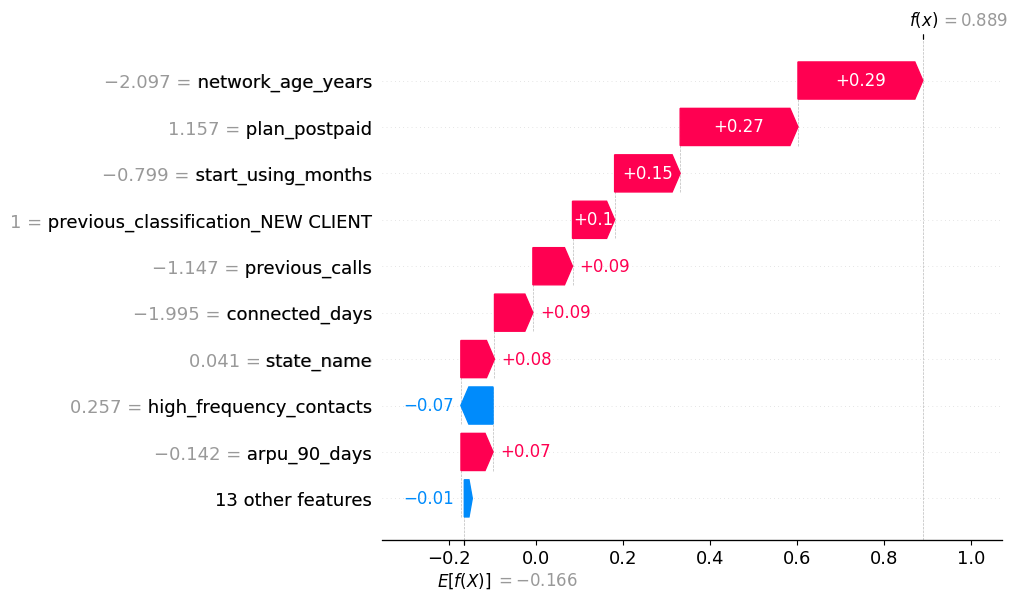

In [ ]:
shap.plots.waterfall(shap_values_sel_model[2])

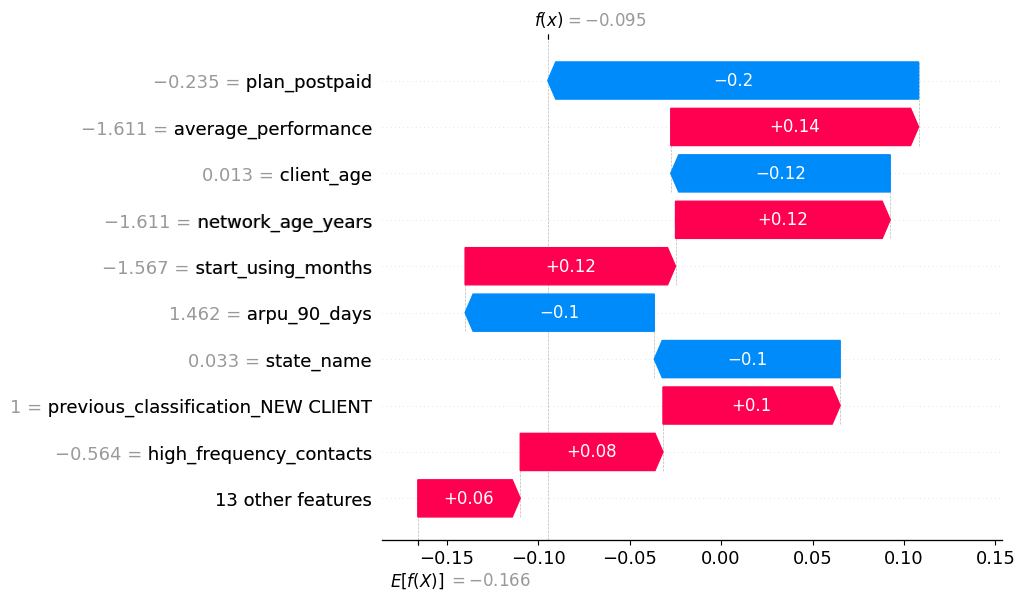

In [ ]:
shap.plots.waterfall(shap_values_sel_model[3])

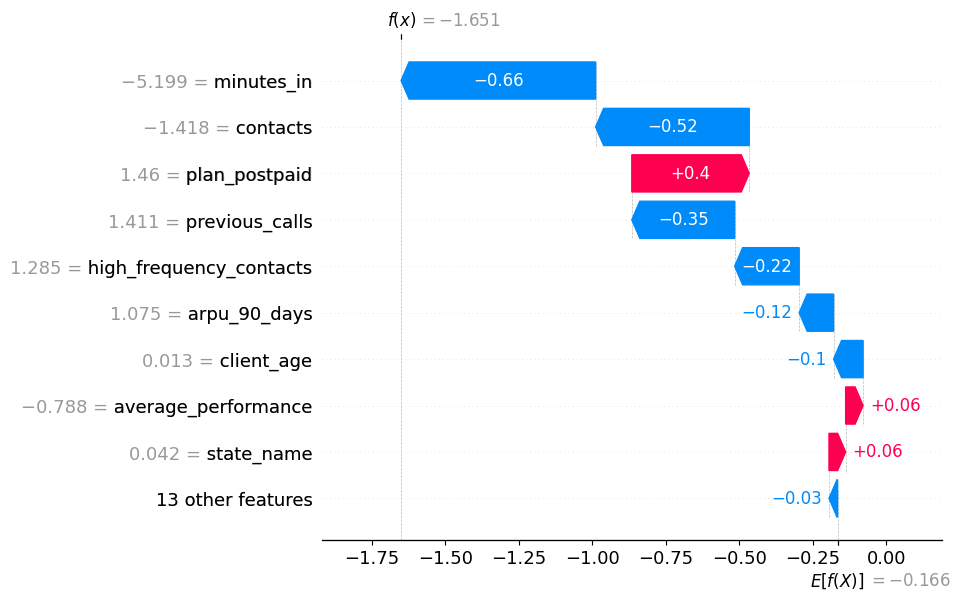

In [ ]:
shap.plots.waterfall(shap_values_sel_model[4])

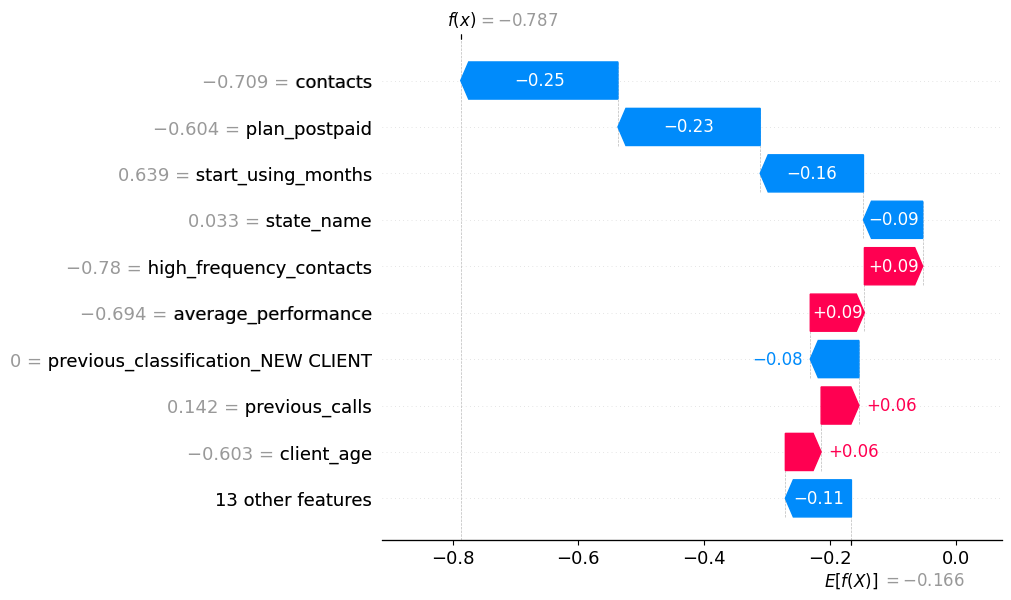

In [ ]:
shap.plots.waterfall(shap_values_sel_model[5])

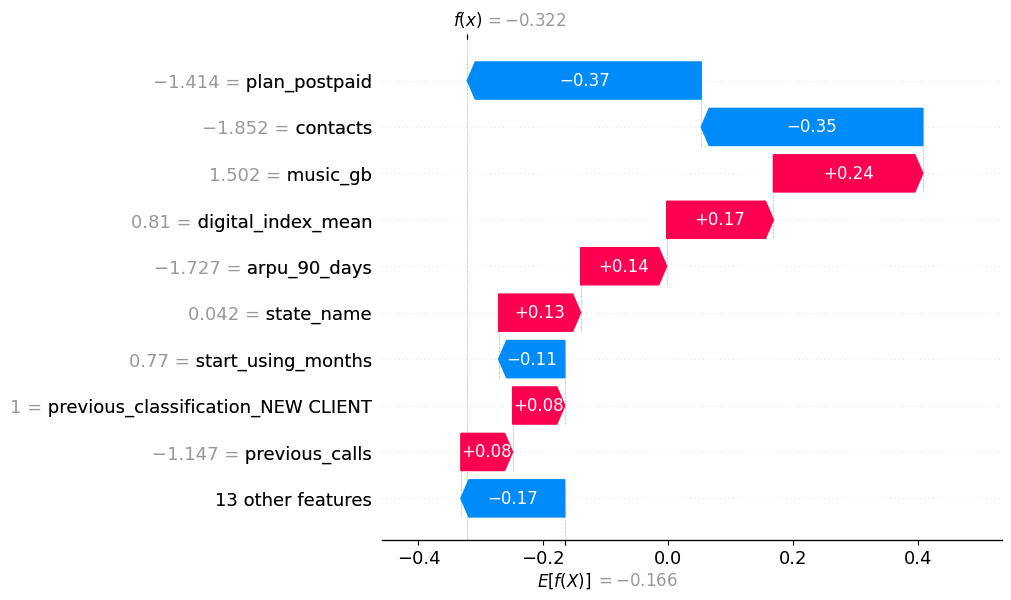

In [ ]:
shap.plots.waterfall(shap_values_sel_model[6])

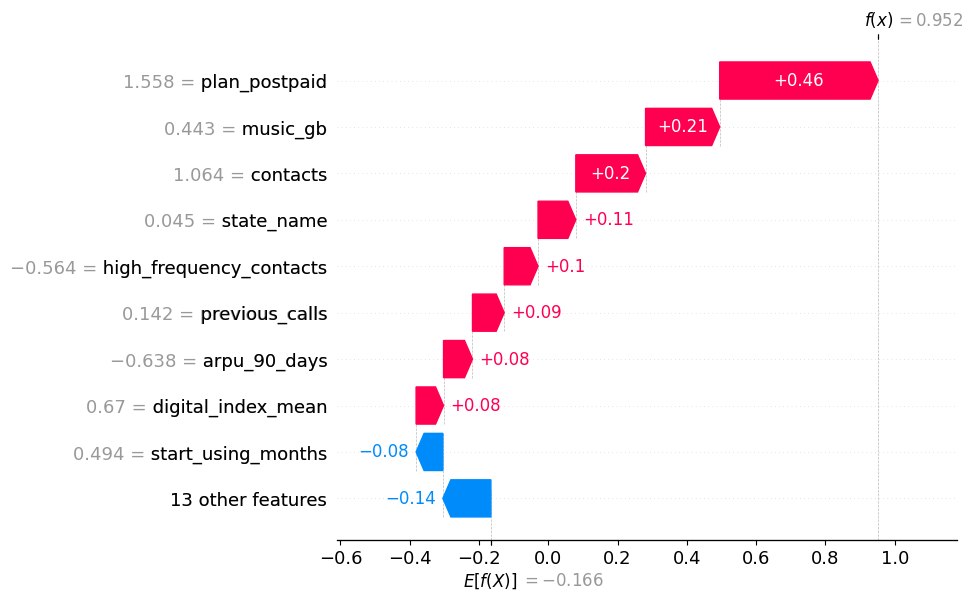

In [ ]:
shap.plots.waterfall(shap_values_sel_model[7])

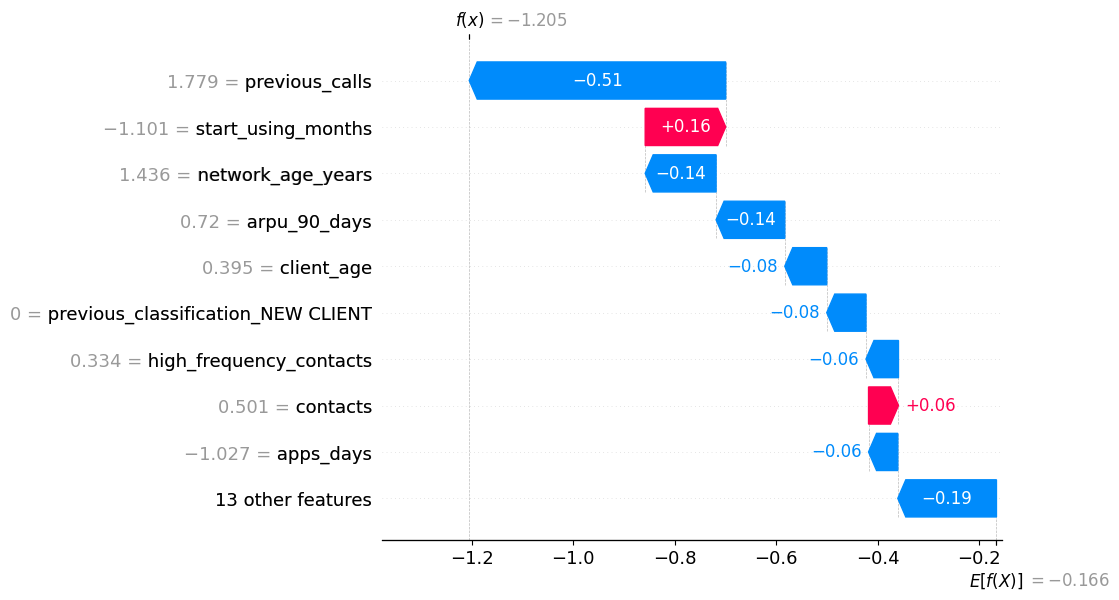

In [ ]:
shap.plots.waterfall(shap_values_sel_model[8])

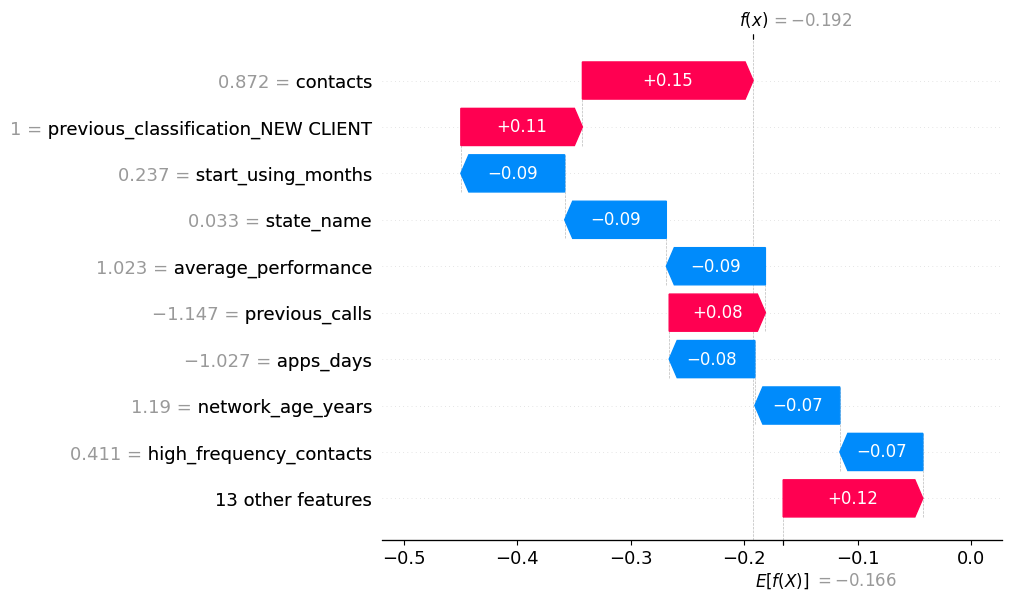

In [ ]:
shap.plots.waterfall(shap_values_sel_model[9])

### Conclusions of the Data Preparation Phase (CRISP-ML)

The data preparation phase is fundamental in the CRISP-ML methodology, as it determines the quality and relevance of the information used for modeling. In this project, the following key actions were performed:

- **Feature selection**: The most relevant variables were identified and selected, removing those that were highly correlated, irrelevant, or had a high percentage of missing values. This reduces complexity and improves model interpretability.
- **Feature engineering**: New variables were created and transformed from existing ones to capture additional information and enhance the model's predictive power. This stage included combining variables, generating indicators, and transforming formats to facilitate algorithm learning.
    - Categorical and numerical variables were analyzed, generating indicators such as average sales per category and frequency of cardinal values.
    - Specific transformations were applied, such as truncating extreme values in critical variables (e.g., minutes_in and average_performance) and creating derived variables like proportions and means.
    - Advanced encoding techniques were used, such as Target Encoding for high-cardinality variables and One Hot Encoding for variables with few categories.
- **Handling missing values**: Missing values were imputed using the median for numerical variables, minimizing the impact of outliers and ensuring dataset robustness. Percentages of missing values per variable were identified and documented.
- **Categorical variable encoding**: Techniques like Target Encoding and One Hot Encoding were applied to transform categorical variables into suitable numerical representations for machine learning algorithms.
- **Normalization and transformation**: Transformations such as Quantile Transformer and Yeo-Johnson were used to stabilize variance and approximate the distribution of numerical variables to a more suitable form for modeling.
    - Specific variables were selected for each type of transformation, ensuring more Gaussian-like distributions and reducing the effect of outliers.
- **Outlier handling**: Extreme values in critical variables were truncated to prevent them from negatively impacting model performance. Boxplots were used to identify and visualize outliers in numerical variables.
- **Class balancing**: Resampling techniques were applied to balance the class proportions in the training set, improving predictive capacity and model generalization.
- **Data splitting**: A stratified split was performed into training and test sets, ensuring the representativeness of both classes and proper model evaluation.
- **Transformation pipeline**: A modular pipeline was defined that integrates all stages of cleaning, transformation, and modeling, enabling reproducibility and traceability throughout the process.

These actions ensure that the data is clean, structured, and ready for the modeling phase, aligning with CRISP-ML principles and facilitating reliable and reproducible results.

[OK] pyarrow listo: v21.0.0
Doing transform on feature  state_name
Doing transform on feature  previous_classification
Doing transform on feature  client_age
Doing transform on feature  client_age  | lower bound: 18  | upper bound: 80
Doing transform on feature  client_age
 The value on impute_nan is: 40.0
Doing transform on feature  network_age_years
 The value on impute_nan is: 2.53
Doing transform on feature  minutes_in
Doing transform on feature  average_performance
Doing transform on feature  start_using_months
Doing transform on feature  start_using_months  | lower bound: 0  | upper bound: 94
Doing transform on feature  start_using_months
 The value on impute_nan is: 7.0
Doing transform on feature  ['client_age', 'network_age_years', 'arpu_90_days', 'minutes_in', 'validity_average', 'average_performance', 'contacts']
Doing transform on feature  ['previous_calls', 'start_using_months', 'high_frequency_contacts', 'plan_postpaid', 'sn_banking', 'connected_days', 'charged_days', 'app

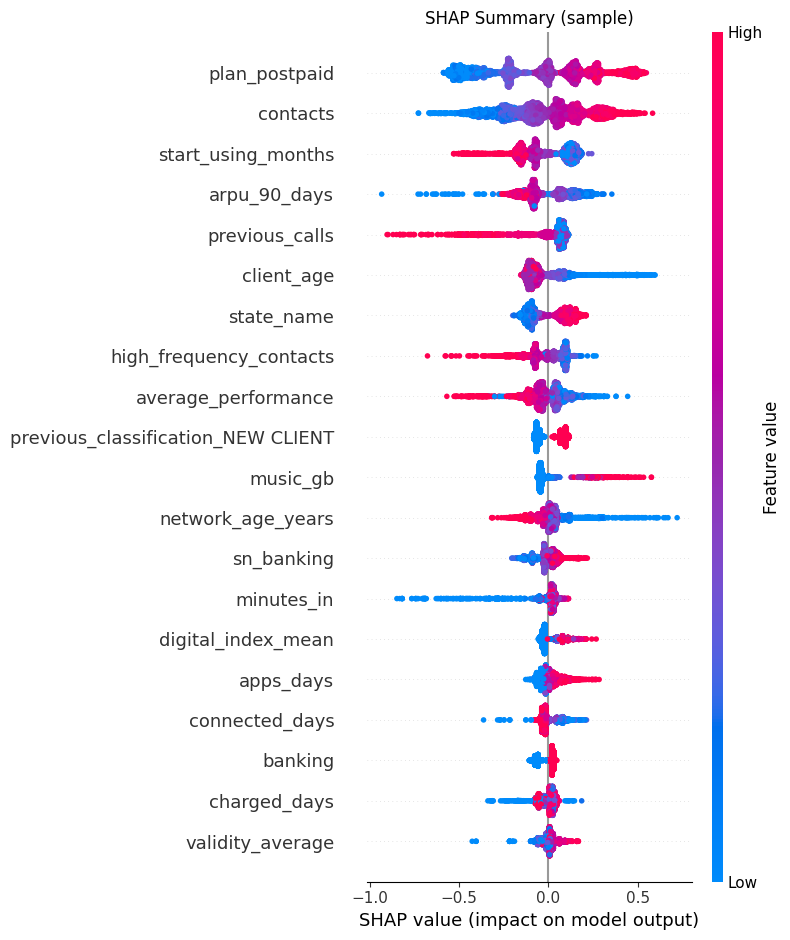

[OK] shap_summary.png guardado


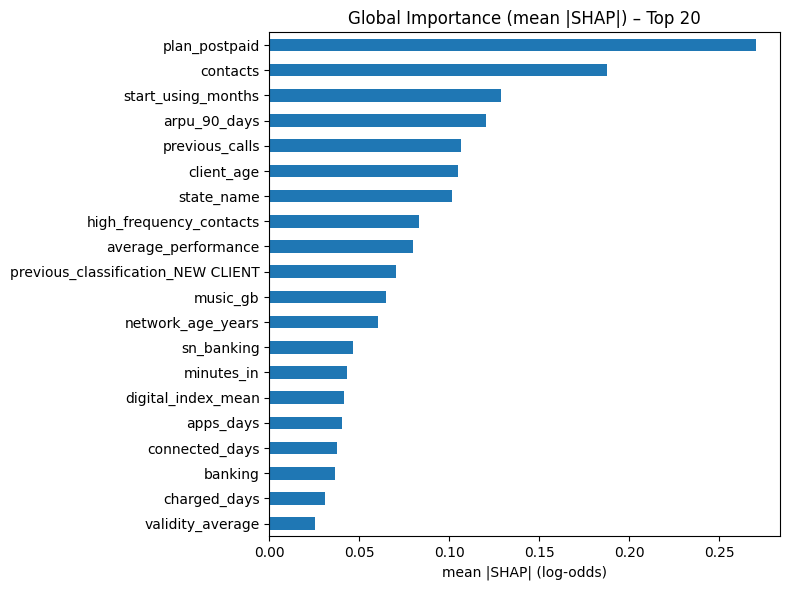

[OK] shap_importance_top20.png guardado


In [ ]:
# Parquet Verification
pa_ver = assert_parquet_ready()
print(f"[OK] pyarrow listo: v{pa_ver}")
prep = build_prep_from_pipeline(model_pipeline)
X_raw = df_selected.drop(columns=['sale'], errors='ignore')

X_tr = prep.transform(X_raw)
clf = model_pipeline.named_steps['classifier']
booster = clf.get_booster()

X_df = align_to_booster_features(X_tr, booster)
feature_cols = booster.feature_names

# SHAP by batches
def _batches(A, n=50_000):
    for i in range(0, A.shape[0], n):
        yield A[i:i+n]

parts = []
for Xi in _batches(X_df.values, n=50_000):
    dm = xgb.DMatrix(Xi, feature_names=feature_cols)
    sv = booster.predict(dm, pred_contribs=True)

    expected = sv[:, -1]
    shap_vals = sv[:, :-1]
    df_sv = pd.DataFrame(shap_vals, columns=feature_cols)
    df_sv['expected_value'] = expected
    df_sv['shap_sum'] = df_sv[feature_cols].sum(axis=1)
    df_sv['logit'] = df_sv['expected_value'] + df_sv['shap_sum']
    df_sv['p_sale'] = 1.0 / (1.0 + np.exp(-df_sv['logit']))
    parts.append(df_sv)

shap_full = pd.concat(parts, axis=0, ignore_index=True)
print(f"[INFO] SHAP generado: {shap_full.shape[0]:,} filas × {len(feature_cols)} features")

try:
    proba_model = clf.predict_proba(X_df.values)[:, 1]
    delta_max = float(np.max(np.abs(proba_model - shap_full['p_sale'].values)))
    print(f"[CHECK] Máx |Δ| proba modelo vs SHAP reconstruida: {delta_max:.3e}")
except Exception:
    print("[WARN] No se pudo validar predict_proba contra SHAP (clasificador sin proba).")

# Saved
save_parquet_strict(shap_full, "shap_full.parquet")
print("[OK] shap_full.parquet escrito (pyarrow)")

(shap_full[feature_cols].abs().mean()
 .sort_values(ascending=False)
 .to_csv("shap_global_importance.csv", header=['mean_|shap|']))
print("[OK] shap_global_importance.csv escrito")

# Visualizations
try:
    import shap
    rng = np.random.default_rng(seed=123)
    n_sample = int(min(5000, len(X_df)))
    if n_sample > 0:
        idx = rng.choice(len(X_df), size=n_sample, replace=False)
        shap_vals_sample = shap_full.loc[idx, feature_cols].to_numpy()
        feats_sample = X_df.iloc[idx][feature_cols].to_numpy()

        assert shap_vals_sample.shape == feats_sample.shape, \
            f"Shape mismatch: SHAP {shap_vals_sample.shape} vs X {feats_sample.shape}"

        shap.summary_plot(
            shap_values=shap_vals_sample,
            features=feats_sample,
            feature_names=feature_cols,
            plot_type="dot",
            max_display=min(20, len(feature_cols)),
            show=False
        )
        plt.title("SHAP Summary (sample)")
        plt.tight_layout()
        plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()
        print("[OK] shap_summary.png guardado")
    else:
        print("[WARN] No hay filas para graficar summary plot.")
except Exception as e:
    print(f"[WARN] Summary plot omitido: {e}")

# Importancia global Top-20
try:
    imp = (shap_full[feature_cols].abs().mean()
           .sort_values(ascending=False)
           .head(20))
    ax = imp[::-1].plot(kind="barh", figsize=(8, 6))
    ax.set_title("Global Importance (mean |SHAP|) – Top 20")
    ax.set_xlabel("mean |SHAP| (log-odds)")
    plt.tight_layout()
    plt.savefig("shap_importance_top20.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print("[OK] shap_importance_top20.png guardado")
except Exception as e:
    print(f"[WARN] Gráfico de importancia global omitido: {e}")

### Conclusion in Baseline

In conclusion, a **regularized logistic regression** and a **single shallow tree** were considered as minimal baselines, but a **shallow XGBoost (max_depth≈2)** was adopted as the practical reference baseline because it consistently captures non-linear cutoffs and interactions in mixed tabular data without operational overhead. This confirms the problem is learnable: post-processing (truncation, targeted imputation, Quantile/Yeo-Johnson) stabilizes distributions, and class handling (under-sampling + threshold sweeps) yields separability above random.

Feature importance is **reliably determined with tree SHAP**, which provides faithful local and global attributions; the ranking by mean |SHAP| highlights spend/usage, banking/digital adoption, tenure/recency, prior call outcome, and social graph—guiding the removal or deprioritization of low-signal features. There is no evidence of material under/overfitting: shallow depth and regularization constrain variance, SHAP narratives remain stable across samples, and precision–recall curves are smooth; a parity check between SHAP-reconstructed probabilities and model outputs shows negligible deviation, reinforcing trust in the explanations.

Meeting these bars, the model is suitable for monthly batch scoring and for generating per-customer sales scripts grounded in transparent SHAP evidence.
